# Macro-Conditional & Regime-Dependent Credit Risk Modeling


---


In [50]:
import sys
import os

EXPECTED_FOLDER = "Systematic-Credit-Risk-Modeling-under-Macroeconomic-Regimes"
current_path = os.path.abspath(os.getcwd())

# Set project root (go up until we reach expected folder)
while os.path.basename(current_path) != EXPECTED_FOLDER:
    current_path = os.path.dirname(current_path)
PROJECT_ROOT = current_path

# Add to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [51]:
# Auto reload external python modules
%load_ext autoreload
%autoreload 2


from modules.dataprep import (
    LoanFeaturesPreparator, load_macro_data
)

from modules.visualisations import (
    plot_na_heatmap, plot_numericals_kde, 
    plot_evaluate_model, plot_model_comparison,
    plot_framework_model_comparison
)

from modules.models import (
    time_train_test_split, 
    evaluate_model, test_candidate_models,
    evaluate_thresholds,
    compare_framework_models_eval,
    
)

from modules.backtest import (
    walk_forward_backtest_TS,
    plot_backtest_results,
    plot_model_across_frameworks,
    plot_framework_model_comparison_backtest
)

from modules.stresstest import (
    stress_test_macro_scenarios,
    stress_sensitivity_analysis,
    STRESS_SCENARIOS,
    plot_stress_test_scenarios,
    plot_stress_heatmap,
    plot_sensitivity_curves
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
# Standard library
import os
import re
import time
import warnings

# External datasets
import kagglehub

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn base
from sklearn.exceptions import ConvergenceWarning

# Models
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering

# Models evaluation
from sklearn.metrics import (
    silhouette_score,
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Config
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Problem Statement

> **Can incorporating macroeconomic conditions and latent market regimes improve the prediction of loan default probability beyond borrower-level features alone?**

<br>

$$ PD = Pr(\text{default} | X_\text{borrower}, M_t, R_t) $$


| Symbol | Meaning |
|--------|---------|
| $X_\text{borrower}$ | Borrower-specific characteristics (FICO, DTI, income …) |
| $M_t$ | Macroeconomic variables at loan issuance time *t* |
| $R_t$ | Latent market regime at time *t* (detected via HMM / GMM) |

<br>


3-tier model hierarchy:
- **Model 1 - Baseline** : $PD = f(X_\text{borrower})$
- **Model 2 - Macro-Augmented** : $PD = f(X_\text{borrower}, M_t)$
- **Model 3 - Regime-Dependent** : $PD = f(X_\text{borrower}, M_t, R_t)$

__________________


# **I. Baseline Framework (1) : Borrower Features**


$$PD = f(X_\text{borrower})$$

## **1. Loading `Lending Club Loan Data`**


Lending Club public dataset [from Kaggle](https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv/data)


In [53]:
# Download latest version from kaggle
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

In [54]:
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /Users/taoufiq/.cache/kagglehub/datasets/adarshsng/lending-club-loan-data-csv/versions/1
['loan.csv', 'LCDataDictionary.xlsx']


### Selecting features

In [55]:
# Loan characteristics
loan_characteristics = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    'sub_grade', 'purpose', 'initial_list_status'
]

# Borrower profile
borrower_profile = [
    'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'dti', 'addr_state',
    'avg_cur_bal', 'tot_cur_bal'
]

# Credit history
credit_history = [
    'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies'
]

# Target/features
target = 'loan_status'
features = loan_characteristics + borrower_profile + credit_history

# Full selection including target and date
selected_columns = ['issue_d'] + features + [target]

In [56]:
# Number of lines to import
NROWS = 500_000

file_path = os.path.join(path, "loan.csv")
loan_df = pd.read_csv(file_path, low_memory=True, nrows=NROWS)[selected_columns]

print(loan_df.shape)
loan_df.head()

(500000, 27)


,issue_d,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,initial_list_status,emp_length,...,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,total_acc,mort_acc,pub_rec_bankruptcies,loan_status
0,Dec-2018,2500,36 months,13.56,84.92,C,C1,debt_consolidation,w,10+ years,...,0,Apr-2001,1,9,1,4341,34,0,1,Current
1,Dec-2018,30000,60 months,18.94,777.23,D,D2,debt_consolidation,w,10+ years,...,0,Jun-1987,0,13,1,12315,44,3,1,Current
2,Dec-2018,5000,36 months,17.97,180.69,D,D1,debt_consolidation,w,6 years,...,0,Apr-2011,0,8,0,4599,13,2,0,Current
3,Dec-2018,4000,36 months,18.94,146.51,D,D2,debt_consolidation,w,10+ years,...,0,Feb-2006,0,10,0,5468,13,3,0,Current
4,Dec-2018,30000,60 months,16.14,731.78,C,C4,debt_consolidation,w,10+ years,...,0,Dec-2000,0,12,0,829,26,2,0,Current


The heatmap reveals a highly concentrated missingness pattern. 

The majority of features present no missing values while èmp_length`, `dti` present few missing values

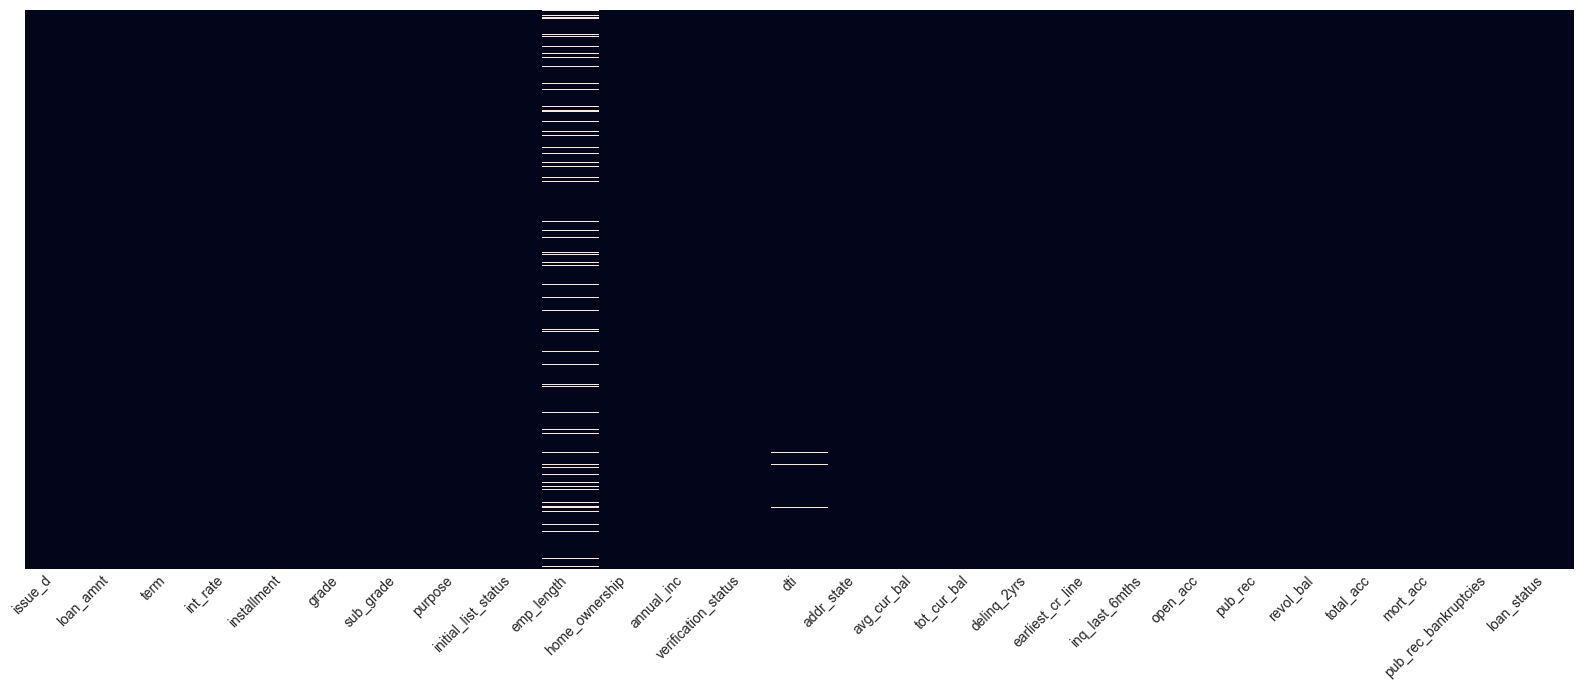

In [57]:
plot_na_heatmap(loan_df, mean_=False)

### Numerical features exploration

In [58]:
numerical_cols = loan_df.select_dtypes(exclude='object').columns.tolist()
print(f"{len(numerical_cols)} Numerical columns")
for col in numerical_cols:
    uniques = loan_df[col].unique()
    print(f"  - {col} ('{len(uniques)}' unique_values)")

15 Numerical columns
  - loan_amnt ('1559' unique_values)
  - int_rate ('143' unique_values)
  - installment ('36548' unique_values)
  - annual_inc ('30273' unique_values)
  - dti ('9467' unique_values)
  - avg_cur_bal ('62296' unique_values)
  - tot_cur_bal ('256285' unique_values)
  - delinq_2yrs ('26' unique_values)
  - inq_last_6mths ('6' unique_values)
  - open_acc ('76' unique_values)
  - pub_rec ('18' unique_values)
  - revol_bal ('64596' unique_values)
  - total_acc ('130' unique_values)
  - mort_acc ('30' unique_values)
  - pub_rec_bankruptcies ('8' unique_values)


|     Column   |    Plot comments   |    Better treatment |
|----------|--------|-----------|
| <br> `inq_last_6mths` |   Spike at 0, very low cardinality (6 values)   |   Keep as-is (already discrete signal, no scaling)  |
| <br> `loan_amnt` | Multimodal, clear loan tiers    |  Bin into credit bands instead of scaling   |
| <br> `installment`, `annual_inc`, `avg_cur_bal`, <br><br> `tot_cur_bal`, `revol_bal`, `open_acc` |  Continuous, right skewed |  Combine  log1p + StandardScaler   |
|<br> `dti`, `total_acc`, `credit_age_months`,  <br><br> `addr_state`, `int_rate`|   Near-normal, slight skew | StandardScaler only |


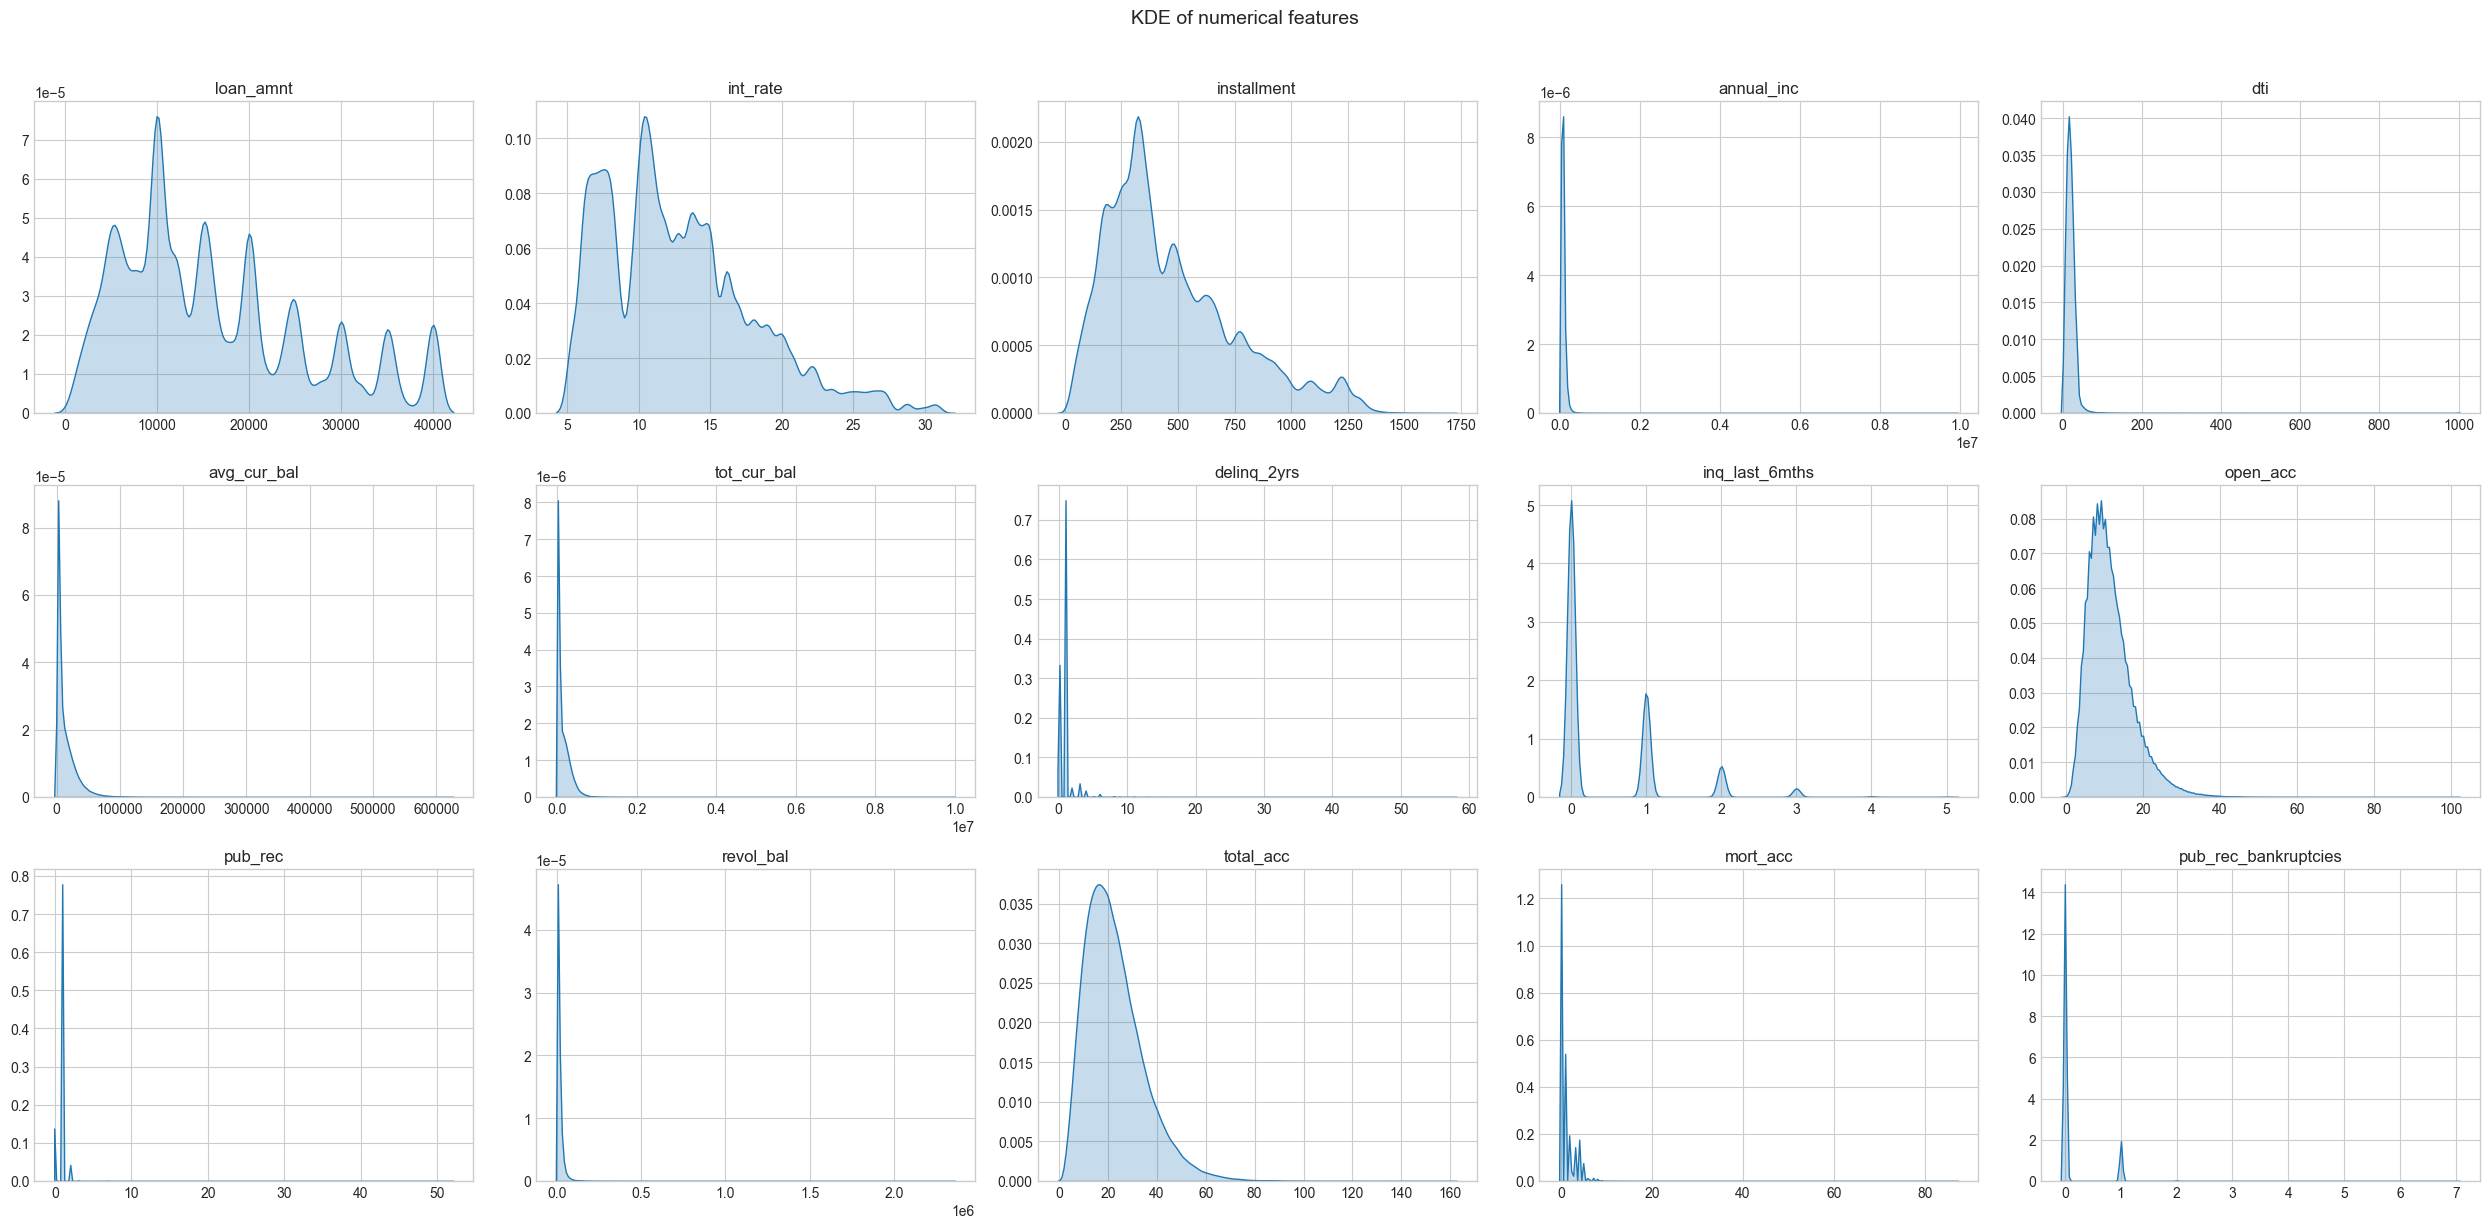

In [59]:
plot_numericals_kde(loan_df, numerical_cols)

### Categorical features exploration

In [60]:
print("Categorical variables and their unique values:")
for col in loan_df.select_dtypes(include='object').columns:
    uniques = loan_df[col].unique()
    print(f"\n- {col} ({len(uniques)}) : {uniques}")

Categorical variables and their unique values:

- issue_d (13) : ['Dec-2018' 'Nov-2018' 'Oct-2018' 'Sep-2018' 'Aug-2018' 'Jul-2018'
 'Jun-2018' 'May-2018' 'Apr-2018' 'Mar-2018' 'Feb-2018' 'Jan-2018'
 'Sep-2016']

- term (2) : [' 36 months' ' 60 months']

- grade (7) : ['C' 'D' 'B' 'A' 'E' 'F' 'G']

- sub_grade (35) : ['C1' 'D2' 'D1' 'C4' 'C3' 'C2' 'D5' 'B3' 'A4' 'B5' 'C5' 'D4' 'E1' 'E4'
 'B4' 'D3' 'A1' 'E5' 'B2' 'B1' 'A5' 'F5' 'A3' 'E3' 'A2' 'E2' 'F4' 'G1'
 'G2' 'F1' 'F2' 'F3' 'G4' 'G3' 'G5']

- purpose (13) : ['debt_consolidation' 'credit_card' 'house' 'car' 'other' 'vacation'
 'home_improvement' 'small_business' 'major_purchase' 'medical'
 'renewable_energy' 'moving' 'wedding']

- initial_list_status (2) : ['w' 'f']

- emp_length (12) : ['10+ years' '6 years' '4 years' '< 1 year' '2 years' '9 years' nan
 '5 years' '3 years' '7 years' '1 year' '8 years']

- home_ownership (4) : ['RENT' 'MORTGAGE' 'OWN' 'ANY']

- verification_status (3) : ['Not Verified' 'Source Verified' 'Verified']



### Data preparation

In [61]:
data_preparator = LoanFeaturesPreparator()
data_preparator.fit(loan_df)

LoanFeaturesPreparator()

In [62]:
framework1_df = data_preparator.transform(loan_df)

print(framework1_df.shape)
framework1_df.head()

(49861, 27)


,date,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,initial_list_status,emp_length,...,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,total_acc,mort_acc,pub_rec_bankruptcies,credit_age_months,default
0,2016-09-01,1,36,0.186702,-1.502609,3,14,6,0,1.0,...,0,1,-1.446196,0,-0.673160,-0.252425,0,0,-1.031125,0
1,2016-09-01,6,60,0.005666,-1.494785,3,12,2,1,10.0,...,1,0,-1.501269,0,-0.673081,0.296723,2,0,1.457939,1
2,2016-09-01,5,36,0.639293,-1.494053,4,16,2,0,6.0,...,1,1,-1.455870,0,-0.673172,0.061374,1,0,-0.583530,0
3,2016-09-01,6,60,0.385842,-1.495062,3,15,2,1,10.0,...,0,0,-1.545670,0,-0.673182,0.218274,3,0,1.032178,0
4,2016-09-01,2,36,-0.537443,-1.497489,2,8,1,1,5.0,...,0,2,-1.545670,0,-0.673157,-0.644674,0,0,-0.441609,0


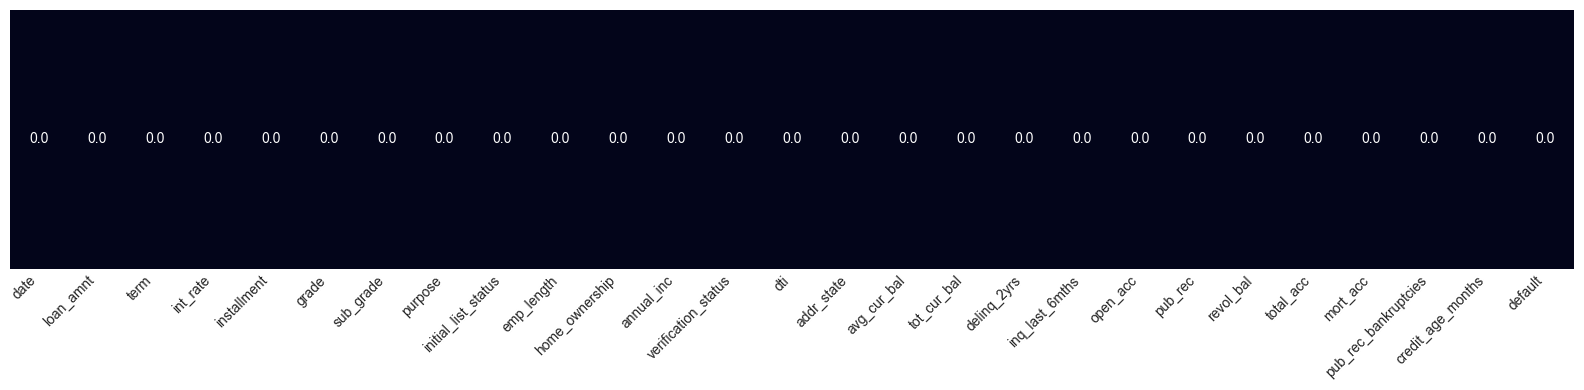

In [63]:
plot_na_heatmap(framework1_df, mean_=True)

Following transformations and normalization, the distributional landscape is markedly improved

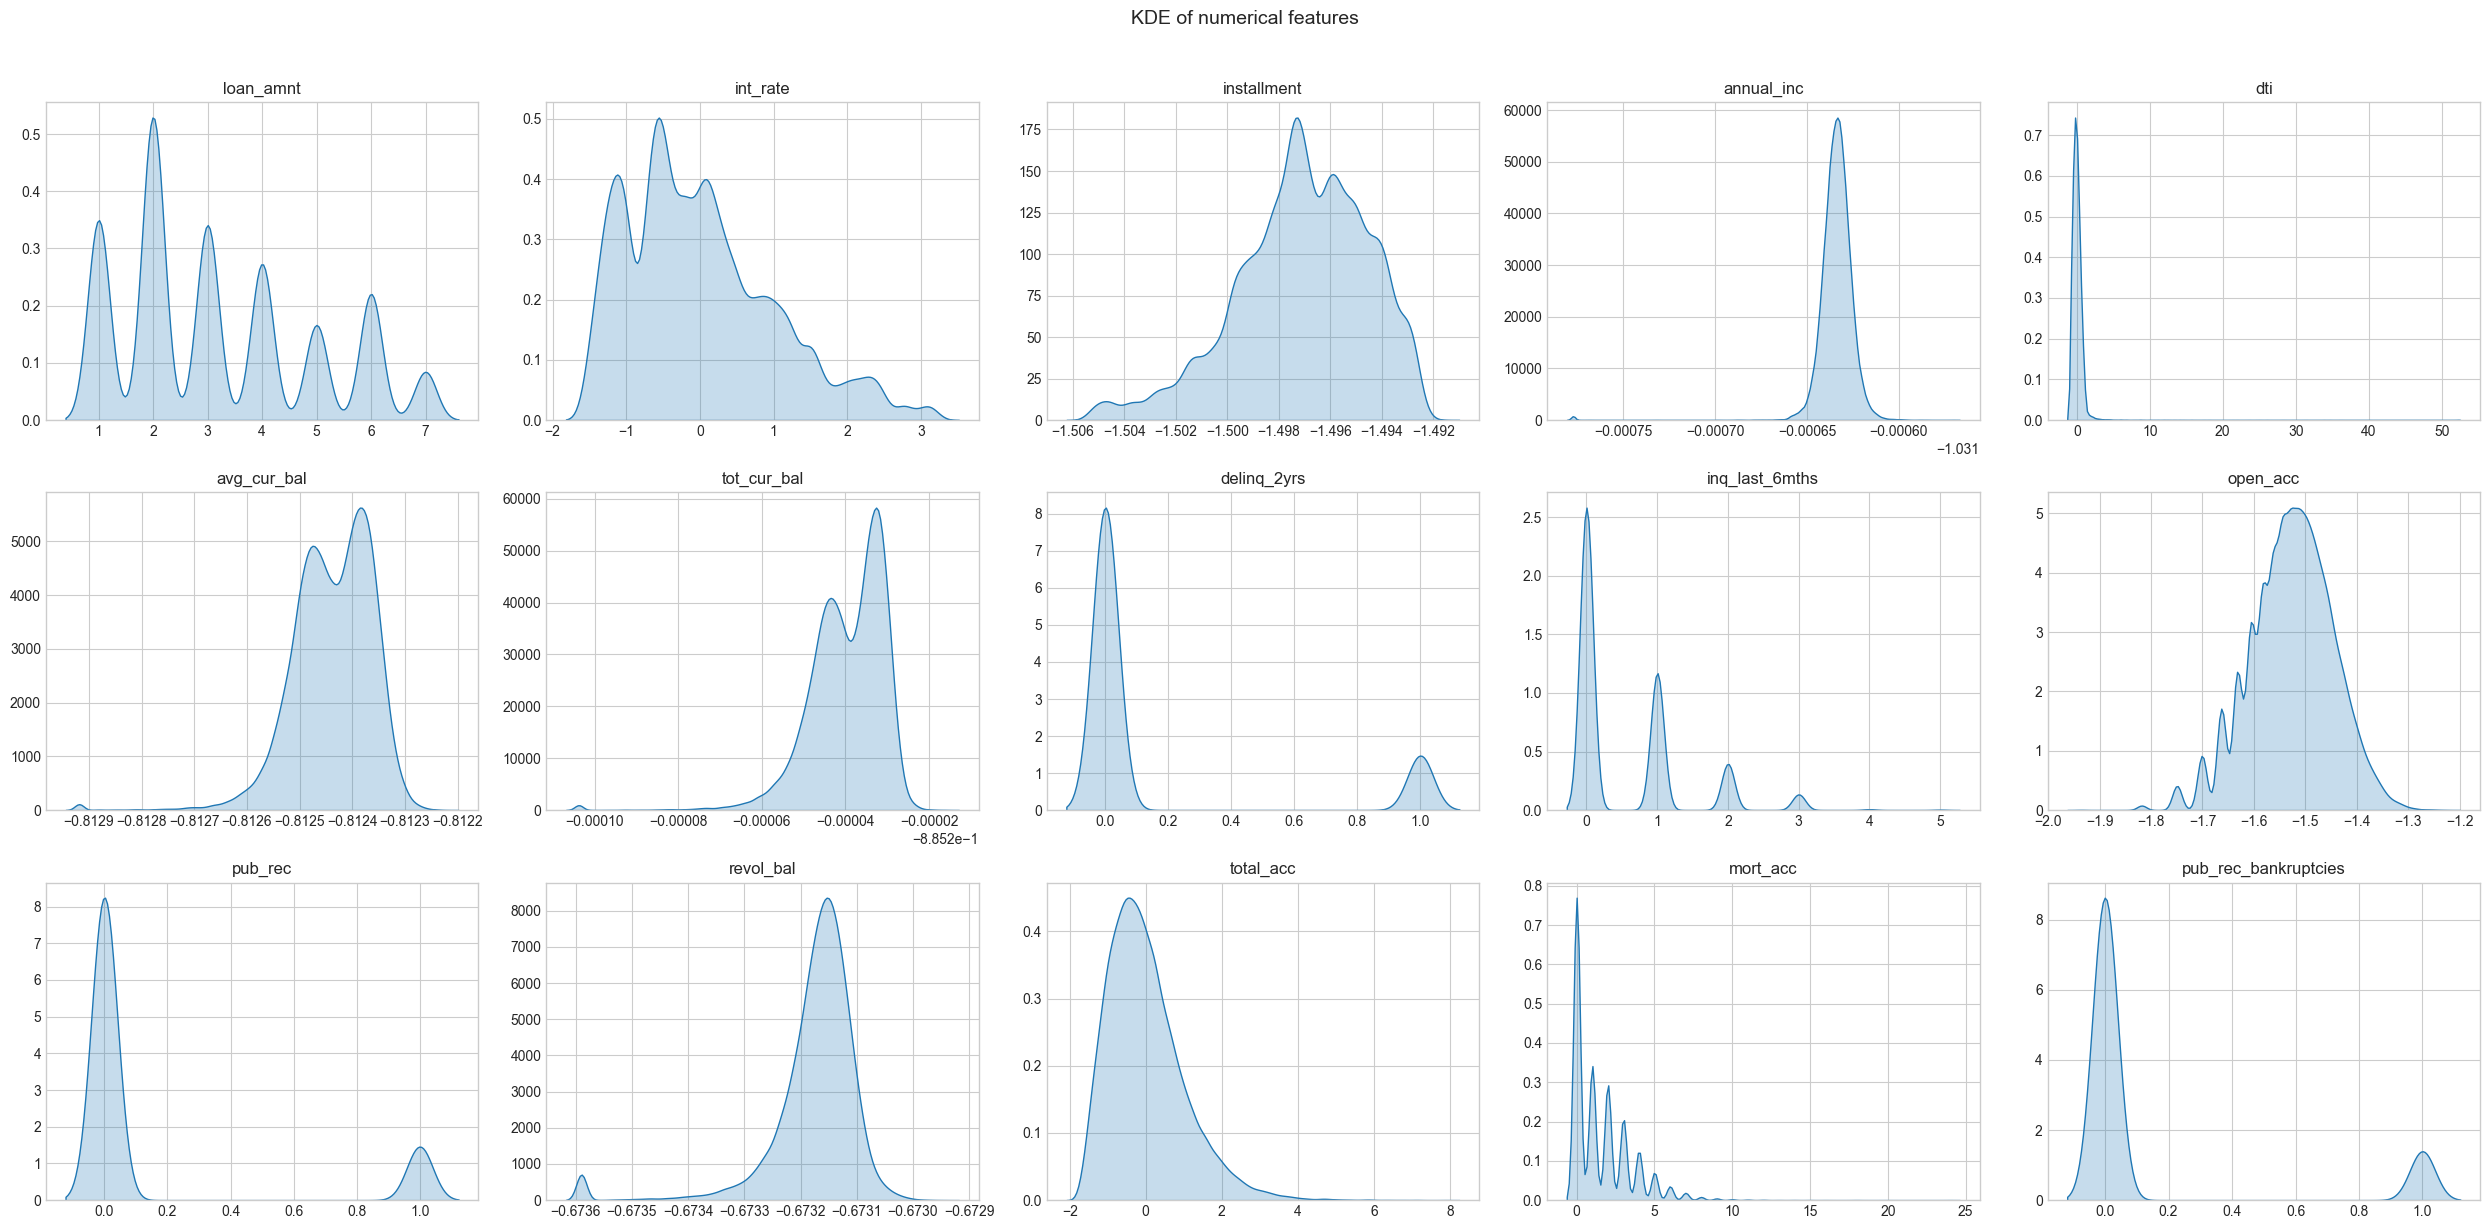

In [64]:
plot_numericals_kde(framework1_df, numerical_cols)

## **2. Estimating Probability of Default (PD)**

### Train / Test split

In [65]:
X_train, X_test, y_train, y_test, train_dates, test_dates, split_date = time_train_test_split(framework1_df)

Train : (41786, 25) | Test: (8075, 25)
Split date : 2018-07-01 00:00:00


We can clearly notice class imbalance with 15% of default in our data. This is something common in Credit Risk Modelling.


When splitting (train/test) we can see a distributional shift: 
- the training set shows a 17.41% default rate while the test set drops to 3.57%

This reflects the time-based split strategy, where the test window (post-July 2018) captures a more recent cohort of loans that had less time to mature into default

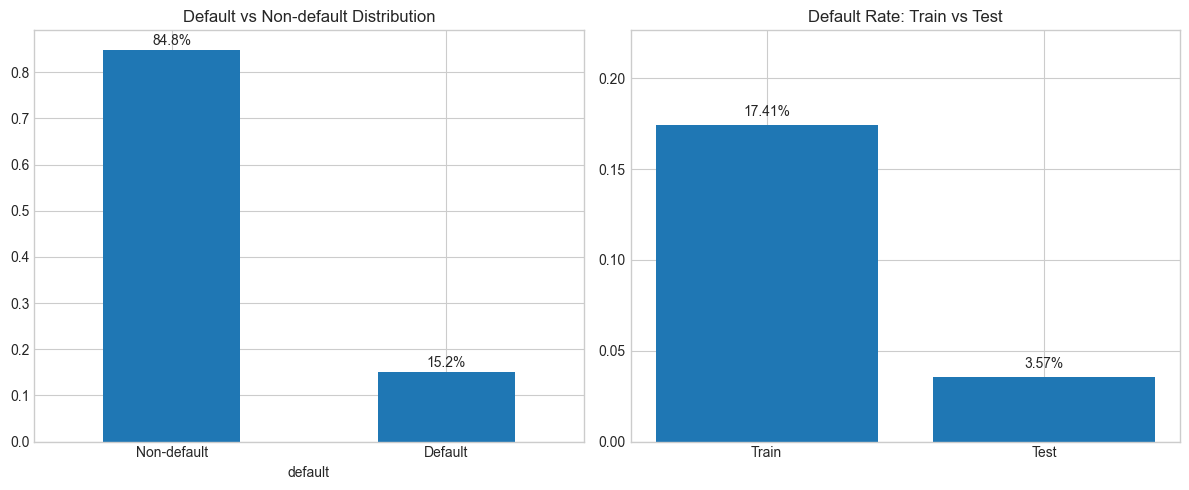

In [66]:
# Overall default distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
framework1_df['default'].value_counts(normalize=True).plot(
    kind='bar', ax=axes[0]
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-default', 'Default'], rotation=0)
axes[0].set_ylabel('')
axes[0].set_title('Default vs Non-default Distribution')
# text 
vals = framework1_df['default'].value_counts(normalize=True)
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha='center')

# Train vs Test default rate
train_rate = y_train.mean()
test_rate = y_test.mean()

rates = [train_rate, test_rate]
labels = ['Train', 'Test']
axes[1].bar(labels, rates)
axes[1].set_ylabel('')
axes[1].set_title('Default Rate: Train vs Test')
for i, v in enumerate(rates):
    axes[1].text(i, v + 0.005, f"{v:.2%}", ha='center')
axes[1].set_ylim(0, max(rates) * 1.3)
plt.tight_layout()
plt.show()

### Testing candidate models


| Level | Model | Purpose | Strength |
|------|------|---------|----------|
| **Level 1 - Baseline Linear Models** | Logistic Regression | Standard baseline Probability of Default (PD) model | Highly interpretable, regulatory-friendly |
| **Level 2 - Regularized Linear Models** | Ridge Logistic Regression | Stabilize coefficients under multicollinearity | Better generalization, coefficient shrinkage |
| **Level 3 - Nonlinear Tree Models** | Decision Tree | Baseline nonlinear classifier | Interpretable nonlinear splits |
| **Level 4 - Gradient Boosting Models** | XGBoost | High-performance boosted tree model | Strong predictive power on tabular data |
|  | Random Forest | Bagging-based ensemble of decision trees   | Robust, low variance, strong baseline for non-linear relationships |

In [67]:
threshold = 0.7

In [68]:
results_step1 = test_candidate_models(X_train, y_train, X_test, y_test, threshold)

Evaluated model 'logistic_regression' in 29.689seconds
Evaluated model 'decision_tree' in 2.350seconds
Evaluated model 'xgboost' in 4.314seconds
Evaluated model 'random_forest' in 37.425seconds


### Test Thresholds

The threshold analysis highlights the usual tradeoff between precision and recall:
- With threshold = 0.5, most models detect very few defaults because the dataset is highly imbalanced
- Increasing threshold to 0.7 makes the model more conservative: it predicts fewer defaults, improving precision but reducing recall


The sharp drop in predicted defaults above 0.5 shows that most estimated default probabilities remain relatively low:
- this indicates that models tend to underestimate default risk, which is also visible in calibration curves
- this is common in imbalanced credit risk datasets, even when using balanced class weights

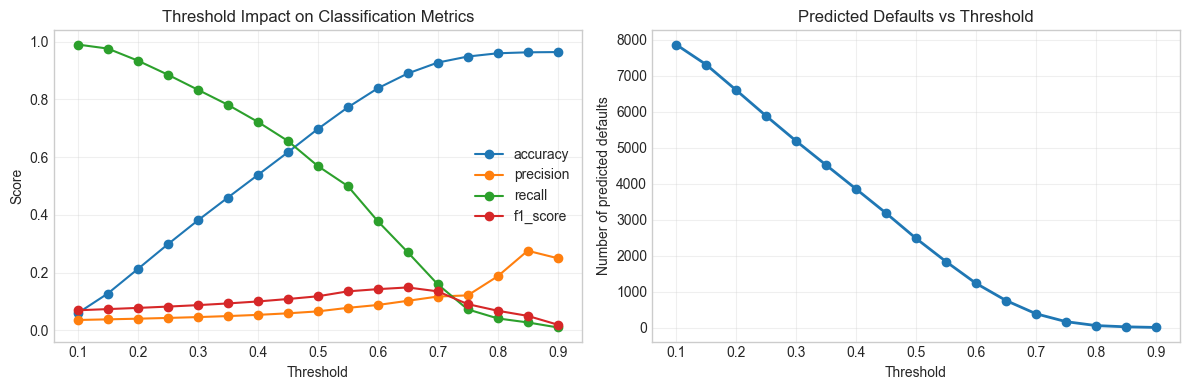

In [69]:
threshold_df = evaluate_thresholds(X_train, y_train, X_test, y_test, plot_=True)

- ROC AUC = 0.689, showing moderate predictive power. The model can distinguish defaults from non-defaults better than random guessing, but borrower features alone are not enough for strong separation

- The calibration curve shows that predicted default probabilities become less reliable at higher PD levels, which is important for stress-testing and risk estimation

- At the 0.7 threshold, the confusion matrix shows the model correctly identifies most non-defaults but misses many actual defaults. This reflects a conservative strategy focused on reducing false alarms

- The learning curve shows train and validation AUC are very close, meaning the model is not overfitting. Instead, performance is limited by the information available in borrower-only variables

- The most important risk drivers are `int_rate` and `installment`, which are economically meaningful since they reflect loan pricing and repayment burden


Classification report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      7787
           1       0.12      0.16      0.14       288

    accuracy                           0.93      8075
   macro avg       0.54      0.56      0.55      8075
weighted avg       0.94      0.93      0.93      8075




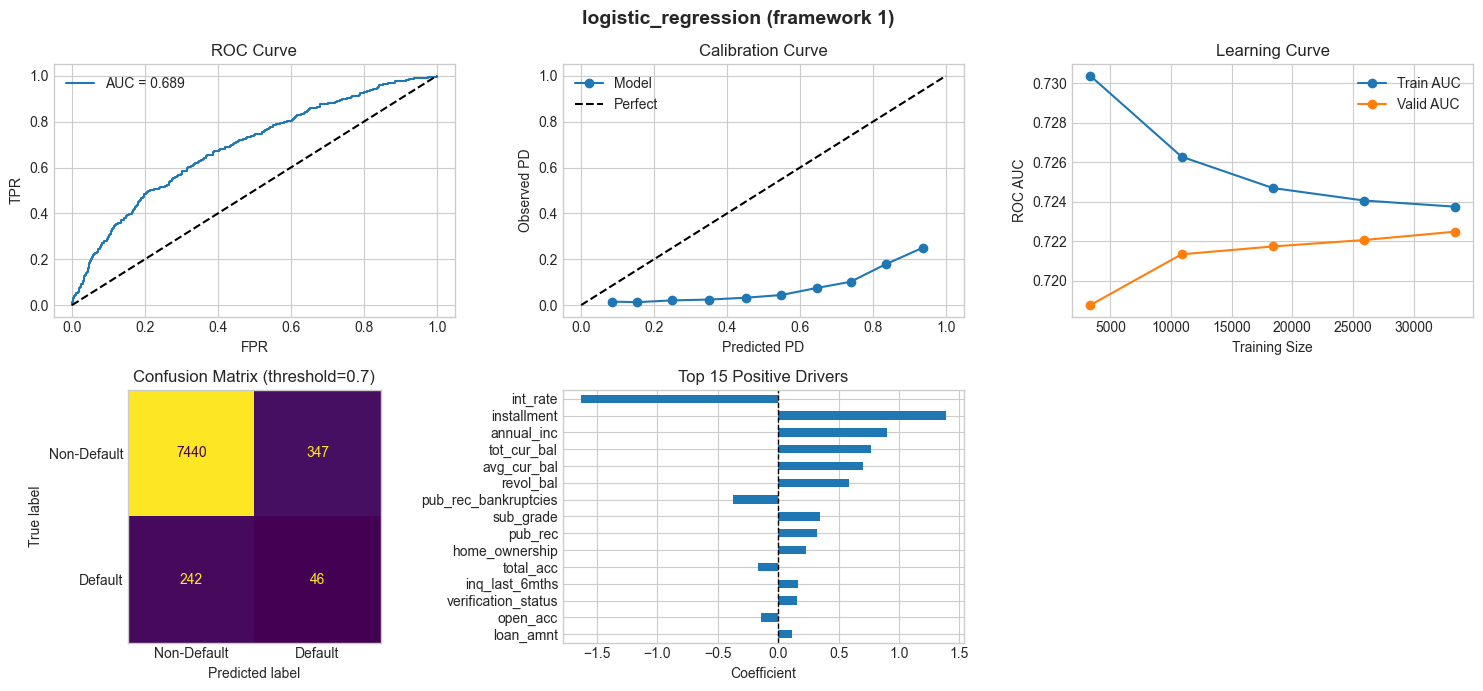

In [70]:
name = "logistic_regression"
plot_evaluate_model(results_step1[name], name+" (framework 1)", threshold)

- ROC AUC = 0.664, making the decision tree the weakest model in overall discrimination performance

- Unlike other models, it captures a meaningful number of defaults at the 0.7 threshold, with 95 true positives and about 33% default recall. This comes at the cost of more false positives among non-default loans

- The learning curve shows a clear gap between training and validation performance, indicating overfitting: the tree learns training-specific patterns that do not generalize well

- The calibration curve is unstable, meaning predicted probabilities are not very reliable. This is common for decision trees because raw leaf probabilities are usually poorly calibrated

- `sub_grade` is the most important feature, which is expected since it already reflects Lending Club’s internal assessment of borrower risk


Classification report:

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7787
           1       0.07      0.32      0.12       288

    accuracy                           0.83      8075
   macro avg       0.52      0.59      0.51      8075
weighted avg       0.94      0.83      0.88      8075




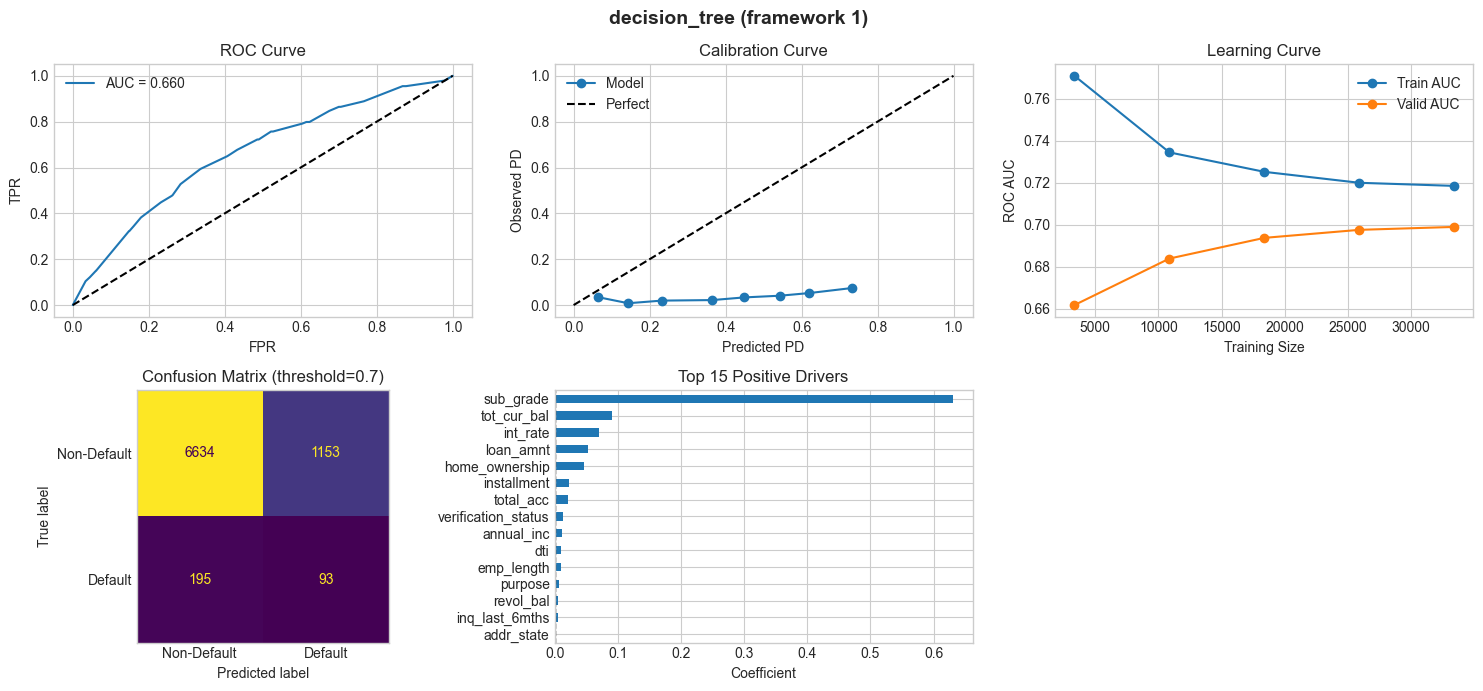

In [71]:
name = "decision_tree"
plot_evaluate_model(results_step1[name], name+" (framework 1)", threshold)

- ROC AUC = 0.707, the best result in Framework 1. This highlights the strong performance of gradient boosting methods on tabular credit data

- At the 0.7 threshold, the model fails to identify defaults, producing almost no true positives. Most predicted probabilities remain below the decision threshold
 
- The calibration curve shows the model systematically underestimates default probabilities across the range of predictions

- The learning curve indicates clear overfitting: training performance is much higher than validation performance, meaning the model captures patterns that do not fully generalize to unseen data

- The most important variables are `sub_grade` and `grade`, showing that the model relies heavily on Lending Club’s internal risk ratings rather than only borrower financial characteristics


Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7787
           1       0.00      0.00      0.00       288

    accuracy                           0.96      8075
   macro avg       0.48      0.50      0.49      8075
weighted avg       0.93      0.96      0.95      8075




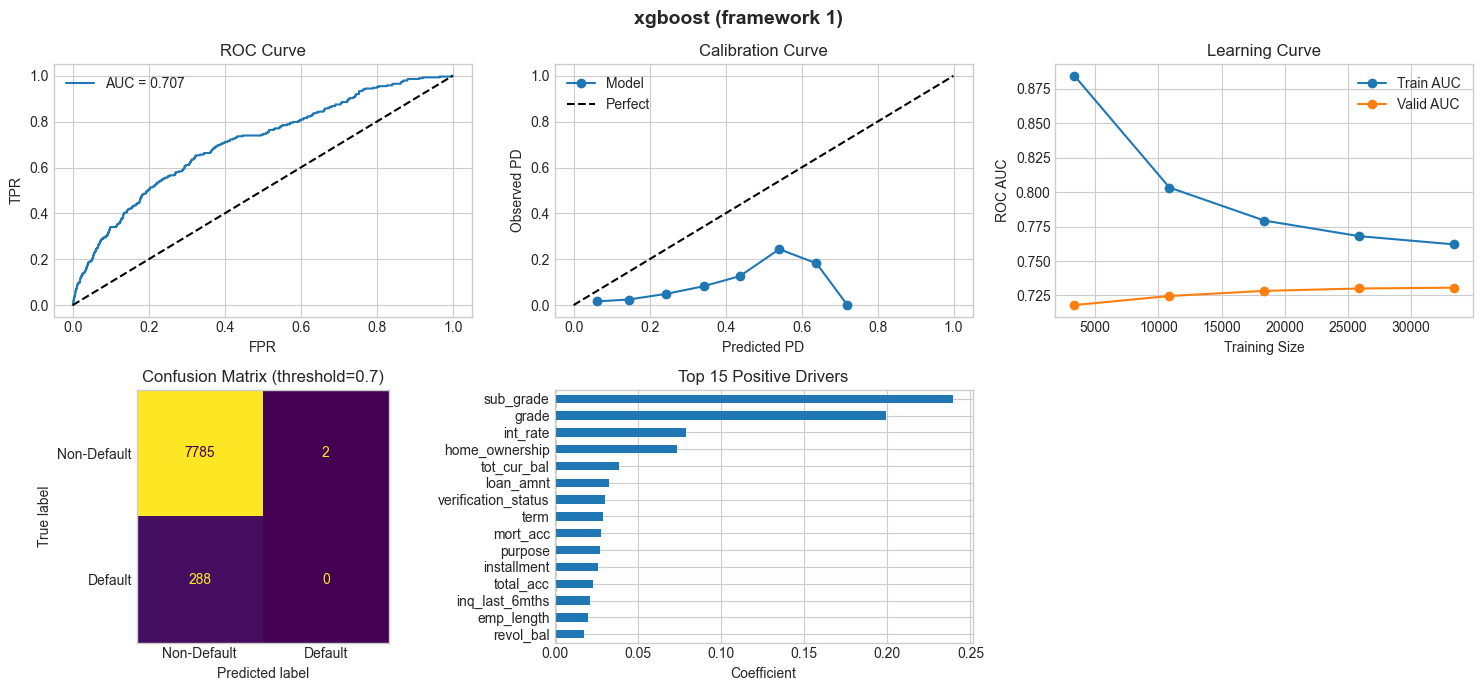

In [72]:
name = "xgboost"
plot_evaluate_model(results_step1[name], name+" (framework 1)", threshold)

- ROC AUC is 0.687, lower than XGBoost but with better generalization. The smaller gap between training and validation AUC suggests Random Forest is less prone to overfitting because bagging reduces variance

- At the 0.7 threshold, the model identifies no defaults, as no predicted probability exceeds the cutoff

- The calibration curve still shows consistent underestimation of default probabilities

- The most important variables are `int_rate`, `sub_grade`, and `grade`, indicating that lender-assigned risk ratings remain the strongest predictors in the tree-based models


Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7787
           1       0.00      0.00      0.00       288

    accuracy                           0.96      8075
   macro avg       0.48      0.50      0.49      8075
weighted avg       0.93      0.96      0.95      8075




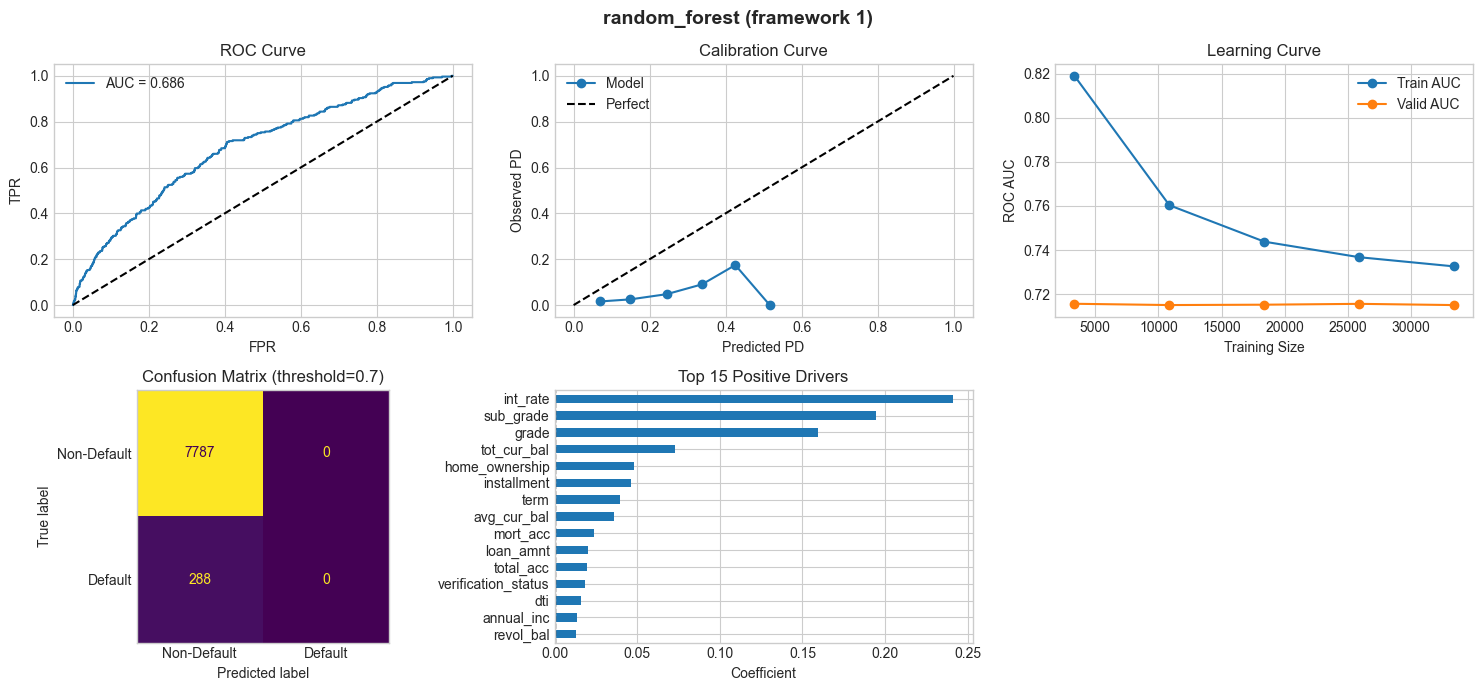

In [73]:
name = "random_forest"
plot_evaluate_model(results_step1[name], name+" (framework 1)", threshold)

### Comparing models

The  plothighlights the trade-offs across models:
- XGBoost achieves the best test AUC (0.707) and the strongest cross-validation performance
- Decision Tree has the weakest AUC but the highest default recall, making it more useful when detecting defaults is more important than overall ranking performance

The precision-versus-Brier analysis shows that xgboost achieves the highest precision, mainly because it predicts defaults very conservatively at the selected threshold.

XGBoost and Random Forest display the largest overfitting gaps, confirming that ensemble tree models fit the training data more aggressively than linear approaches.

In terms of computation, Decision Tree trains very quickly, while Logistic Regression and Random Forest require more time.

Borrower-only features produce moderate predictive performance, with AUC values between 0.664 and 0.707. No model achieves strong default detection at the 0.7 threshold. The most influential predictors are lender-assigned risk indicators such as `sub_grade`, `grade`, and `int_rate`, suggesting that raw borrower financial variables alone contain limited additional predictive power. This motivates extending the model with macroeconomic variables in Framework 2.

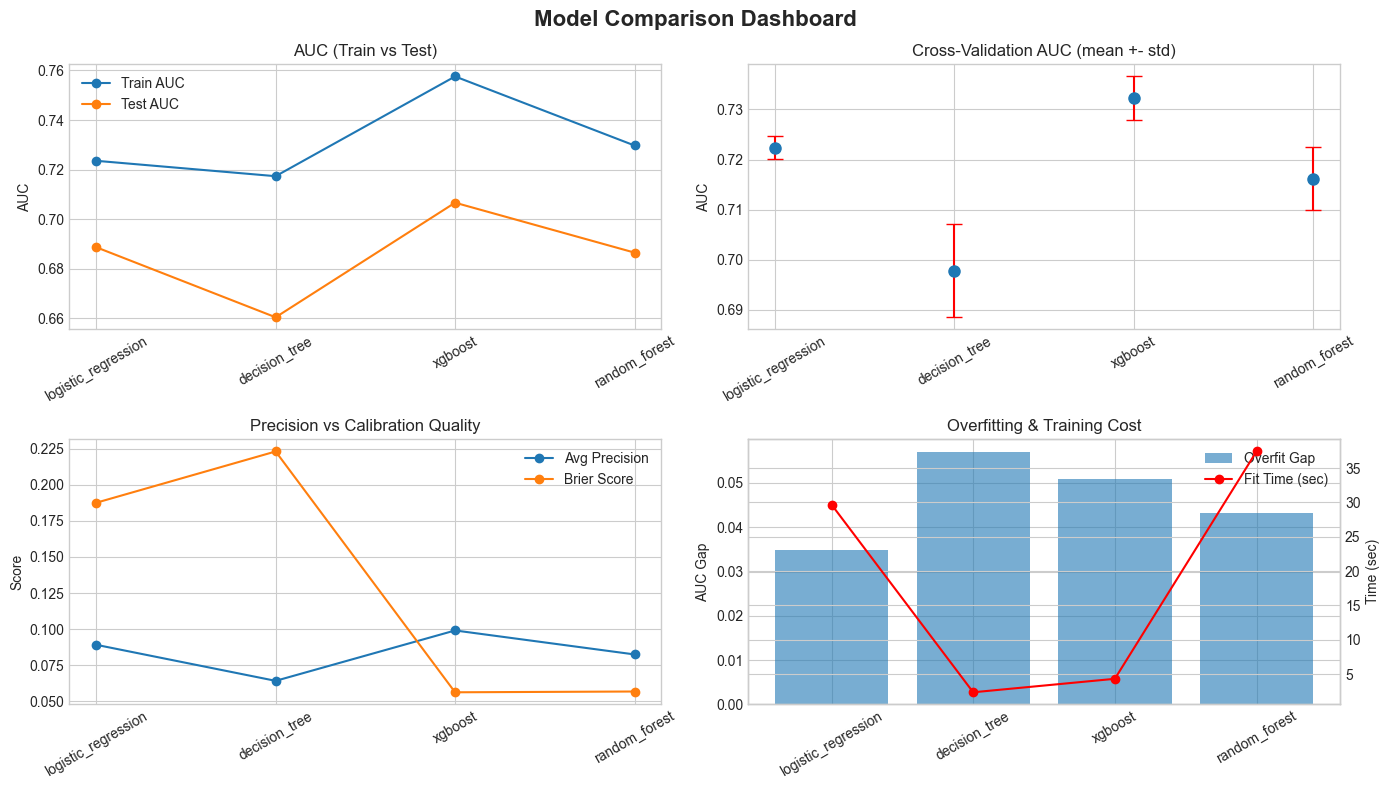

In [74]:
plot_model_comparison(results_step1)

__________________


# **II. Macro-Augmented Framework (2) : Borrower + Macro Features**


$$PD = f(X_\text{borrower}, M_t)$$


## **1. Loading Macro features**

In [75]:
macro_df = load_macro_data()
macro_df = macro_df[macro_df['date'].isin(framework1_df['date'])].reset_index(drop=True)

print(macro_df.shape)
macro_df.head()

(13, 9)


,date,fed_funds,unemp_rate,cpi,ind_prod,real_gdp,credit_spread,treasury_10y,treasury_2y
0,2016-09-01,0.40,5.0,241.176,98.7457,18892.639,2.62,1.63,0.77
1,2018-01-01,1.33,4.0,248.859,101.4625,20328.553,1.77,2.58,2.03
2,2018-02-01,1.42,4.1,249.529,101.7085,20328.553,1.56,2.86,2.18
3,2018-03-01,1.42,4.0,249.577,102.2067,20328.553,1.72,2.84,2.28
4,2018-04-01,1.67,4.0,250.227,103.3329,20580.912,1.85,2.87,2.38


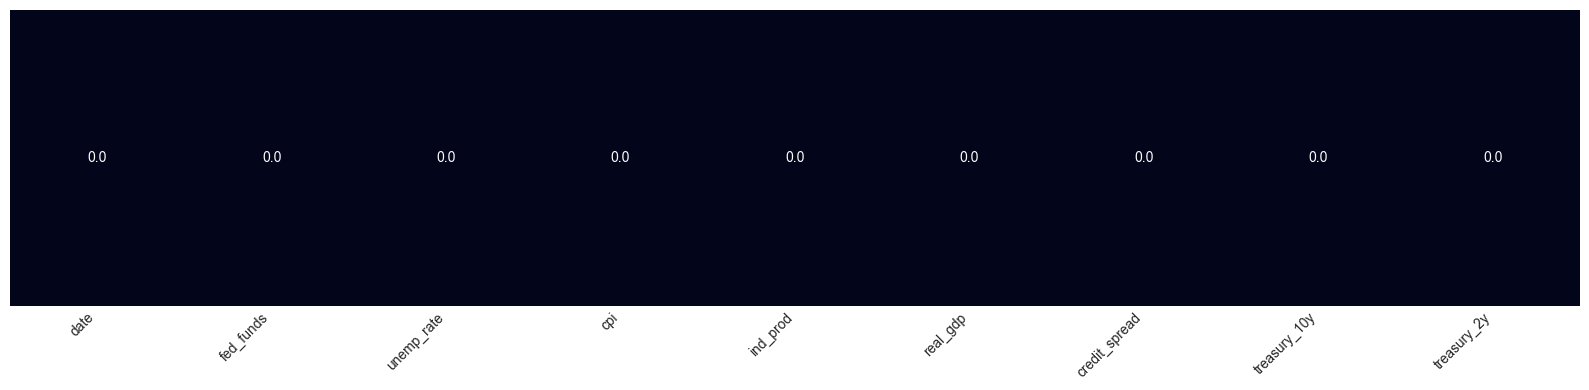

In [76]:
plot_na_heatmap(macro_df, mean_=True)

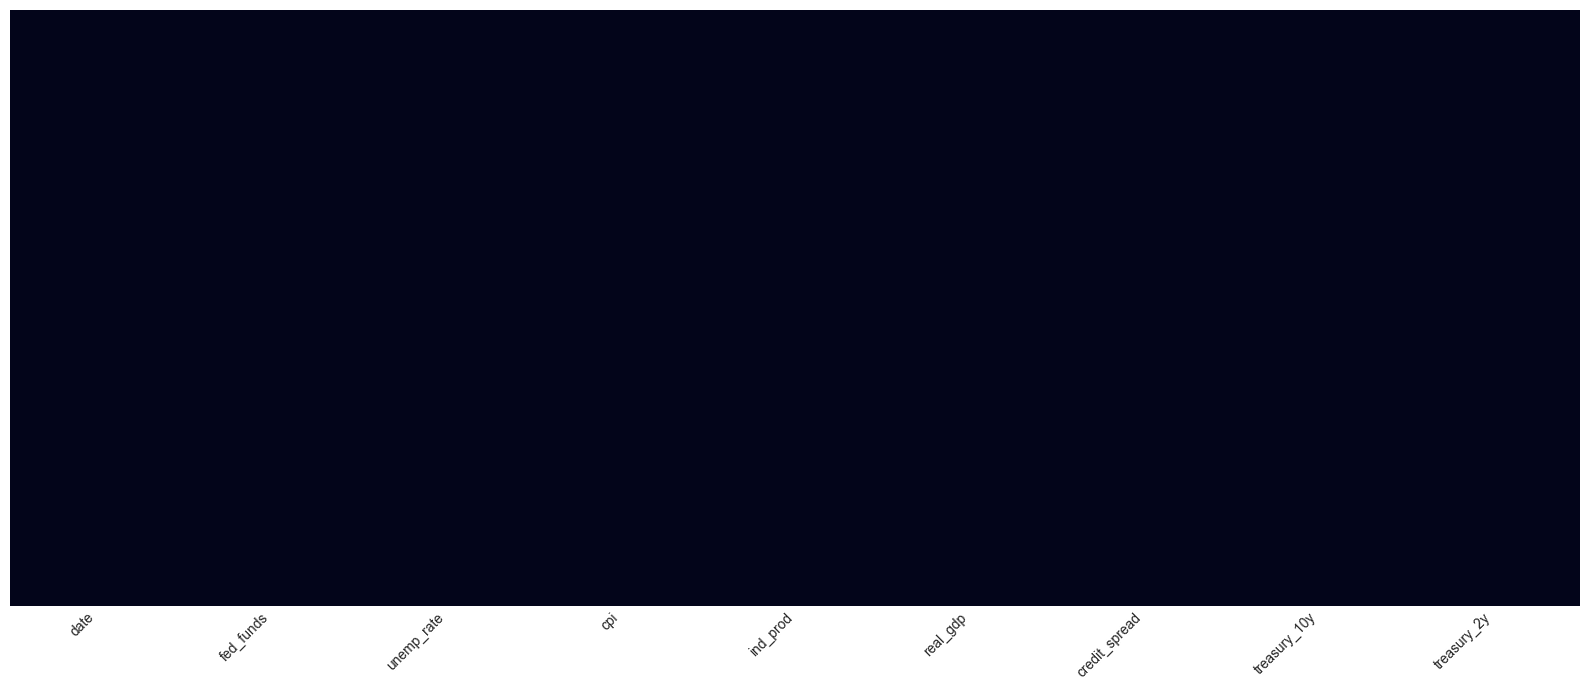

In [77]:
plot_na_heatmap(macro_df, mean_=False)

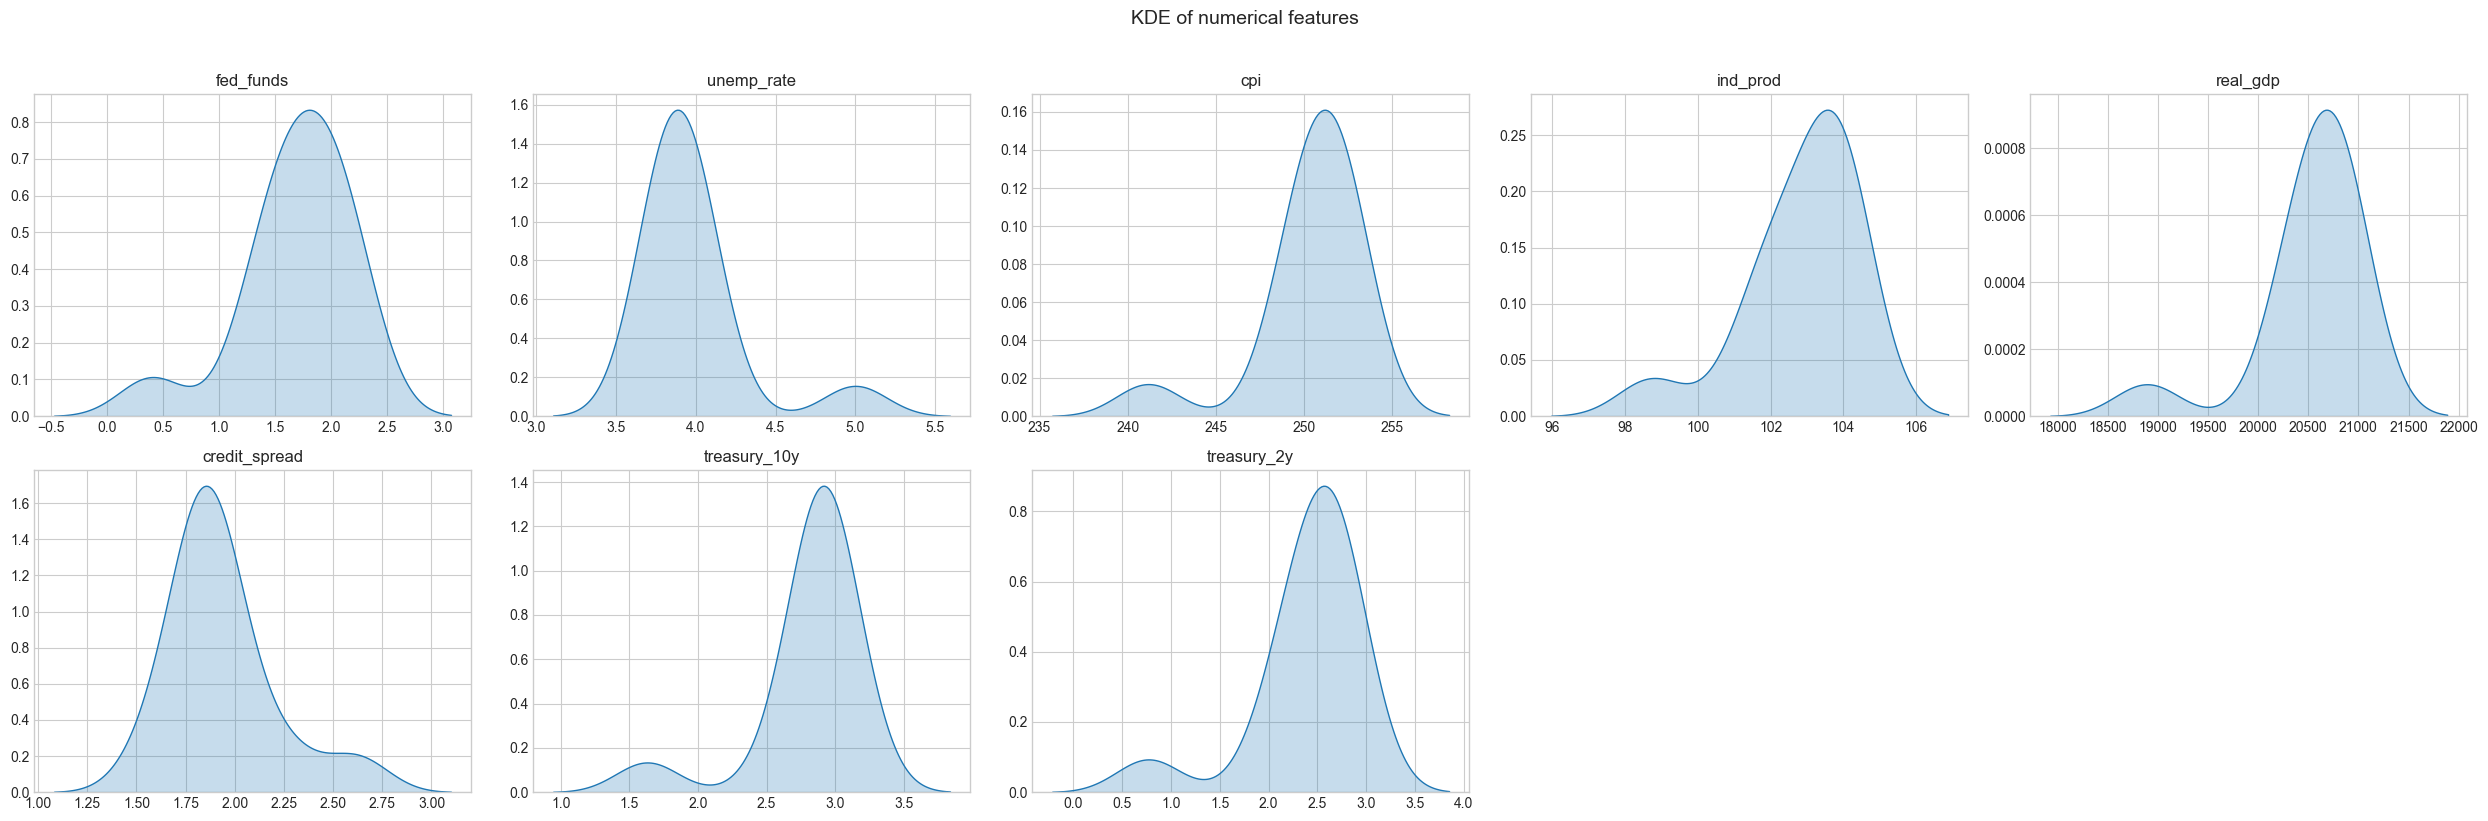

In [78]:
numerical_cols = list(macro_df.columns[1:])
plot_numericals_kde(macro_df, numerical_cols)

In [79]:
macro_scaler = StandardScaler()
macro_scaler.fit(macro_df[numerical_cols])

macro_df[numerical_cols] = macro_scaler.transform(macro_df[numerical_cols])

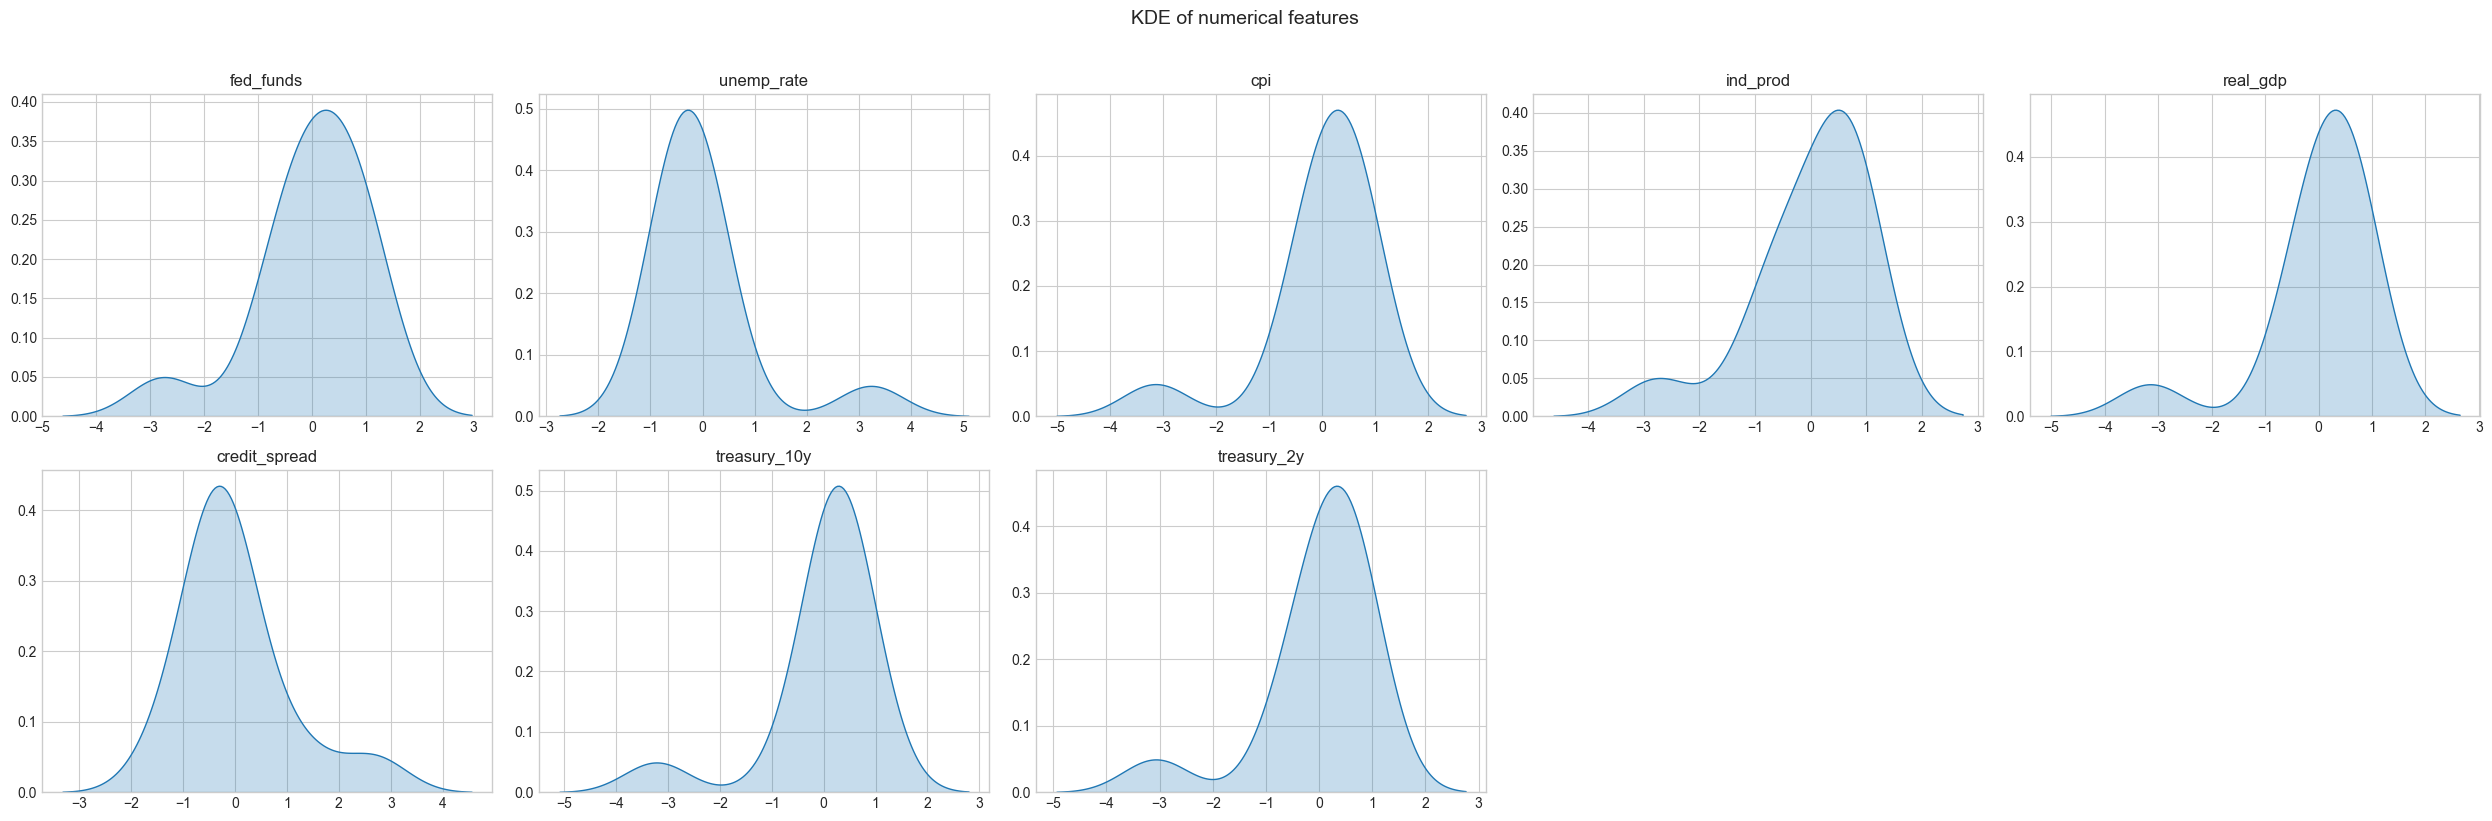

In [80]:
plot_numericals_kde(macro_df, numerical_cols)

## **2. Merging Borrower / Macro features**

In [81]:
framework1_df['date'] = pd.to_datetime(framework1_df['date'])
macro_df['date'] = pd.to_datetime(macro_df['date'])


framework2_df = framework1_df.merge(macro_df, on='date', how='left')

print(framework2_df.shape)
framework2_df.head()

(49861, 35)


,date,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,initial_list_status,emp_length,...,credit_age_months,default,fed_funds,unemp_rate,cpi,ind_prod,real_gdp,credit_spread,treasury_10y,treasury_2y
0,2016-09-01,1,36,0.186702,-1.502609,3,14,6,0,1.0,...,-1.031125,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027
1,2016-09-01,6,60,0.005666,-1.494785,3,12,2,1,10.0,...,1.457939,1,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027
2,2016-09-01,5,36,0.639293,-1.494053,4,16,2,0,6.0,...,-0.583530,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027
3,2016-09-01,6,60,0.385842,-1.495062,3,15,2,1,10.0,...,1.032178,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027
4,2016-09-01,2,36,-0.537443,-1.497489,2,8,1,1,5.0,...,-0.441609,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027


## **3. Estimating PD**

### Train / Test Split

In [82]:
X_train2, X_test2, y_train2, y_test2, train_dates2, test_dates2, split_date2 = time_train_test_split(framework2_df)

Train : (41786, 33) | Test: (8075, 33)
Split date : 2018-07-01 00:00:00


### Test Thresholds

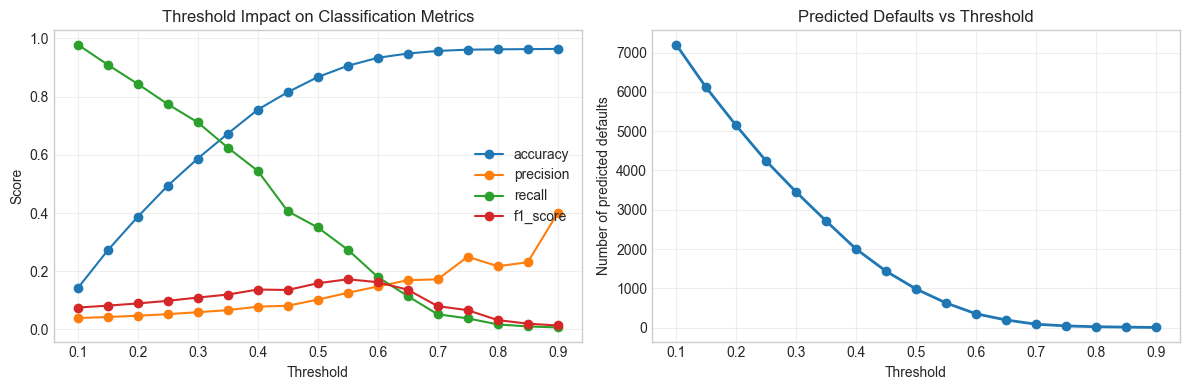

In [83]:
threshold_df = evaluate_thresholds(X_train2, y_train2, X_test2, y_test2, plot_=True)

### Testing candidate models

In [84]:
results_step2 = test_candidate_models(X_train2, y_train2, X_test2, y_test2, threshold)

Evaluated model 'logistic_regression' in 22.446seconds
Evaluated model 'decision_tree' in 1.565seconds
Evaluated model 'xgboost' in 3.372seconds
Evaluated model 'random_forest' in 11.523seconds


In [85]:
frameworks = {"Framework 1": results_step1, "Framework 2": results_step2}

- ROC AUC = 0.704, indicating a moderate improvement in the model’s ability to rank default risk after adding macroeconomic variables

- At threshold = 0.7, the model identifies only a small number of defaults (15 true positives), meaning most predicted probabilities still remain below the decision cutoff. This suggests that while macro features improve overall ranking, they do not strongly shift predictions into the high-risk region used for classification

- The most influential macro drivers are interest rates, particularly `treasury_2y` and `treasury_10y`, which carry strong positive effects and reflect increased default risk in higher-rate environments. `unemp_rate` also contributes meaningfully, aligning with its role as a broad indicator of economic stress


Classification report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7787
           1       0.18      0.05      0.08       288

    accuracy                           0.96      8075
   macro avg       0.57      0.52      0.53      8075
weighted avg       0.94      0.96      0.95      8075




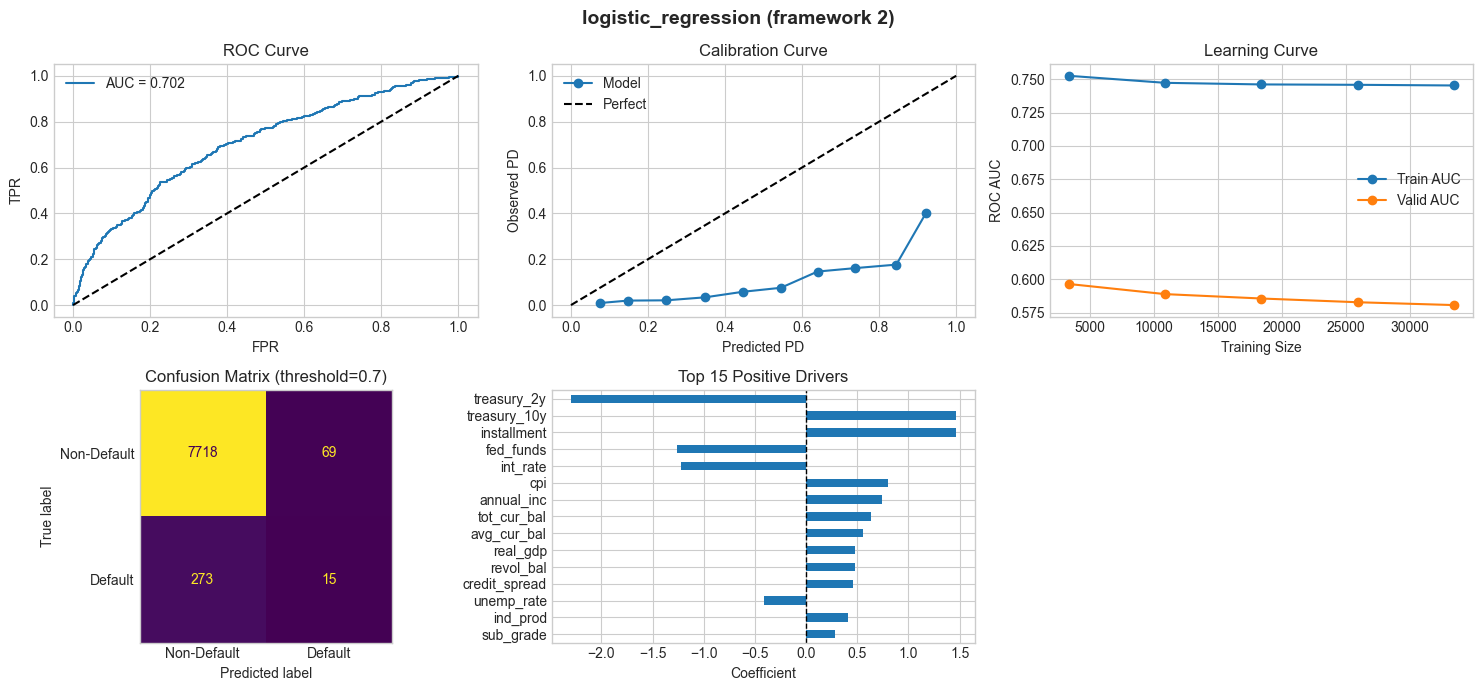

In [86]:
name = "logistic_regression"
plot_evaluate_model(results_step2[name], name+" (framework 2)", threshold)

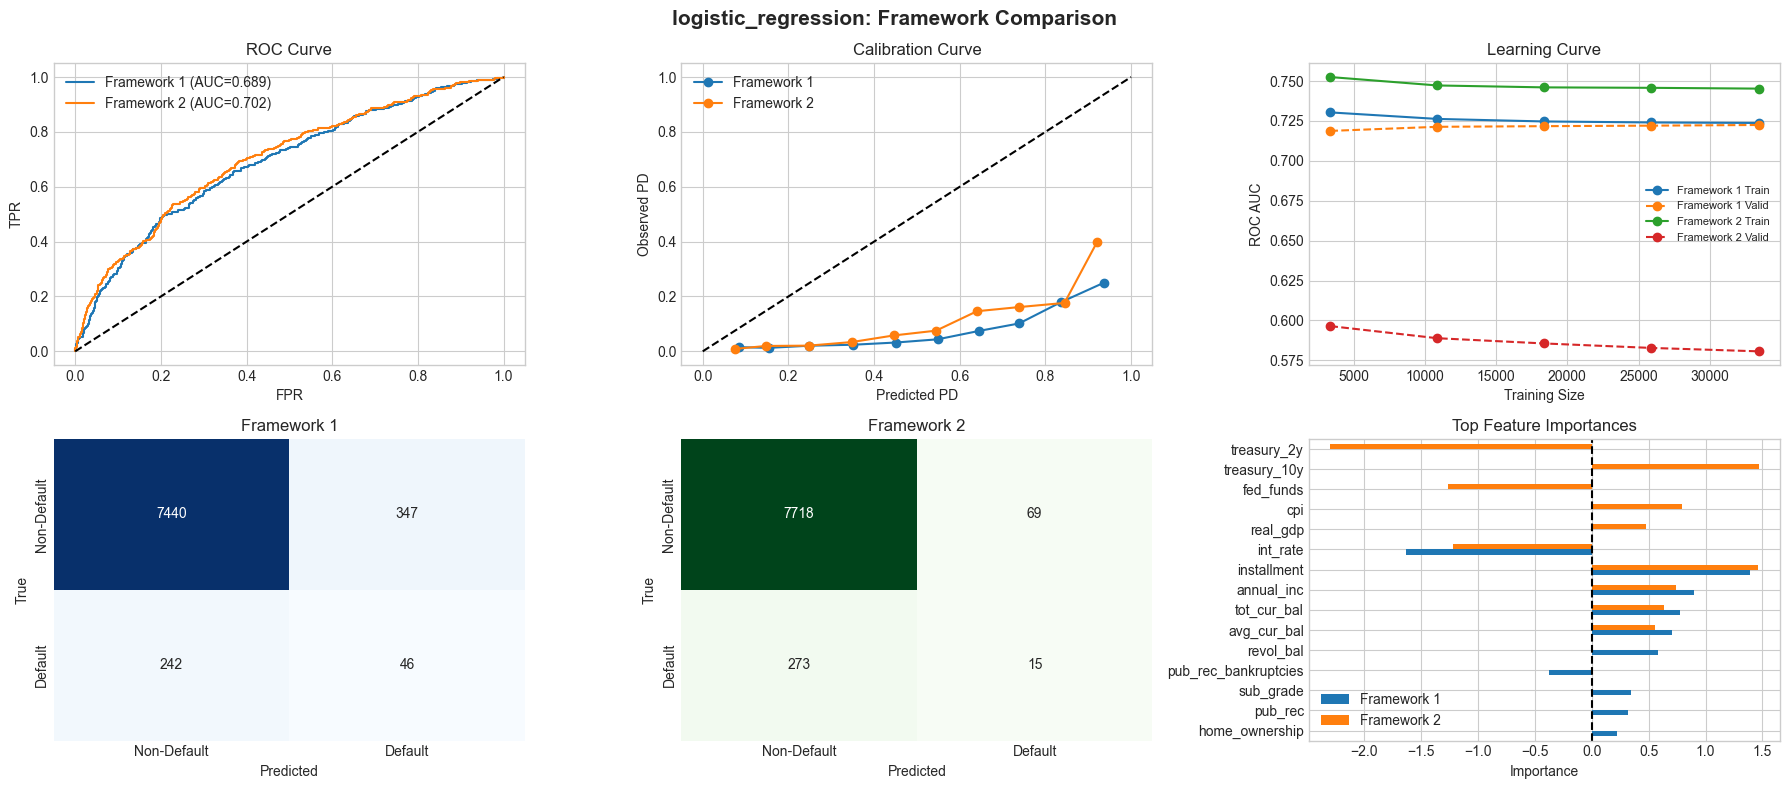

In [87]:
compare_framework_models_eval(frameworks, threshold, name)

- ROC AUC drops to 0.653 from 0.664, showing that adding macro variables slightly reduces overall ranking performance for the Decision Tree

- At the same time, the model still struggles to identify defaults reliably, and most of its predictive power remains concentrated in borrower-level features such as `sub_grade` and `int_rate`

- The macro variables contribute very little. Because they vary only at a monthly level, the tree tends to split on them in ways that capture short-term patterns in the training period rather than stable relationships. This leads to splits that do not generalize well to the test set


Classification report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7787
           1       0.06      0.03      0.04       288

    accuracy                           0.95      8075
   macro avg       0.51      0.51      0.51      8075
weighted avg       0.93      0.95      0.94      8075




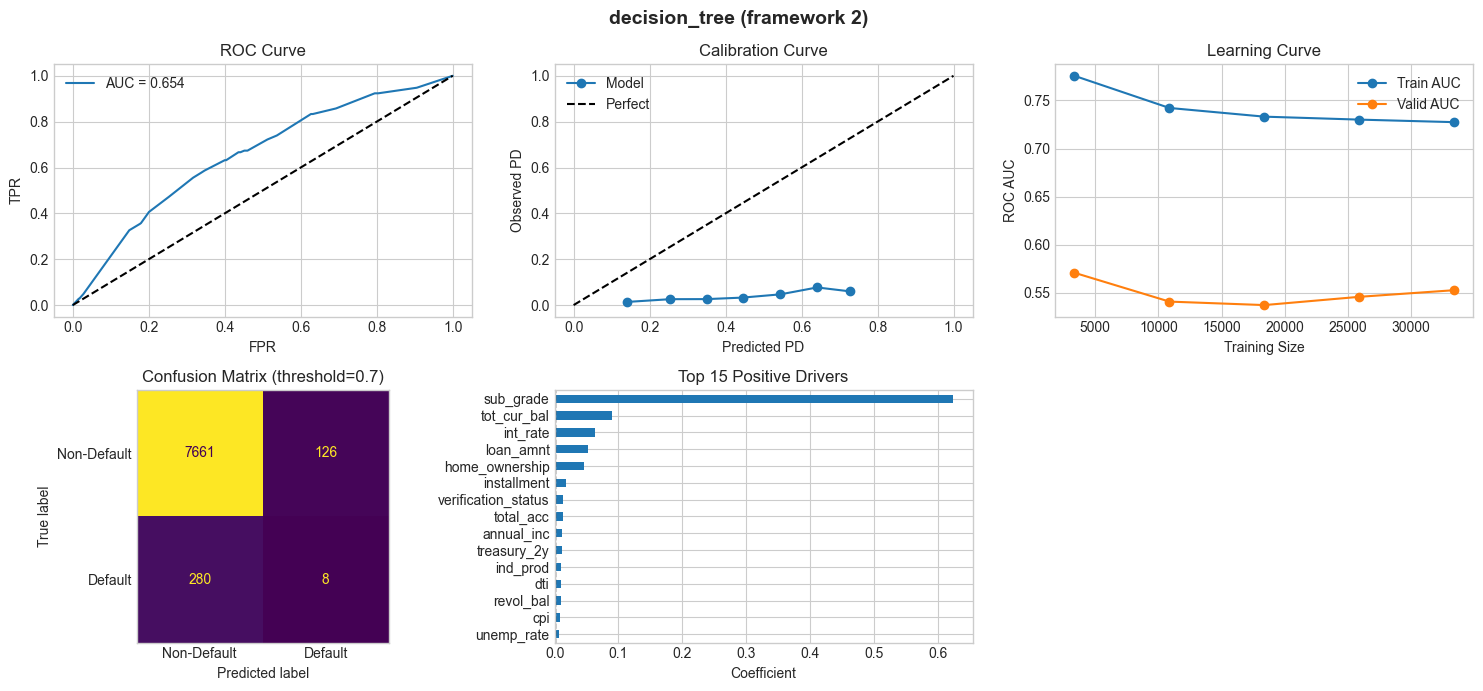

In [88]:
name = "decision_tree"
plot_evaluate_model(results_step2[name], name+" (framework 2)", threshold)

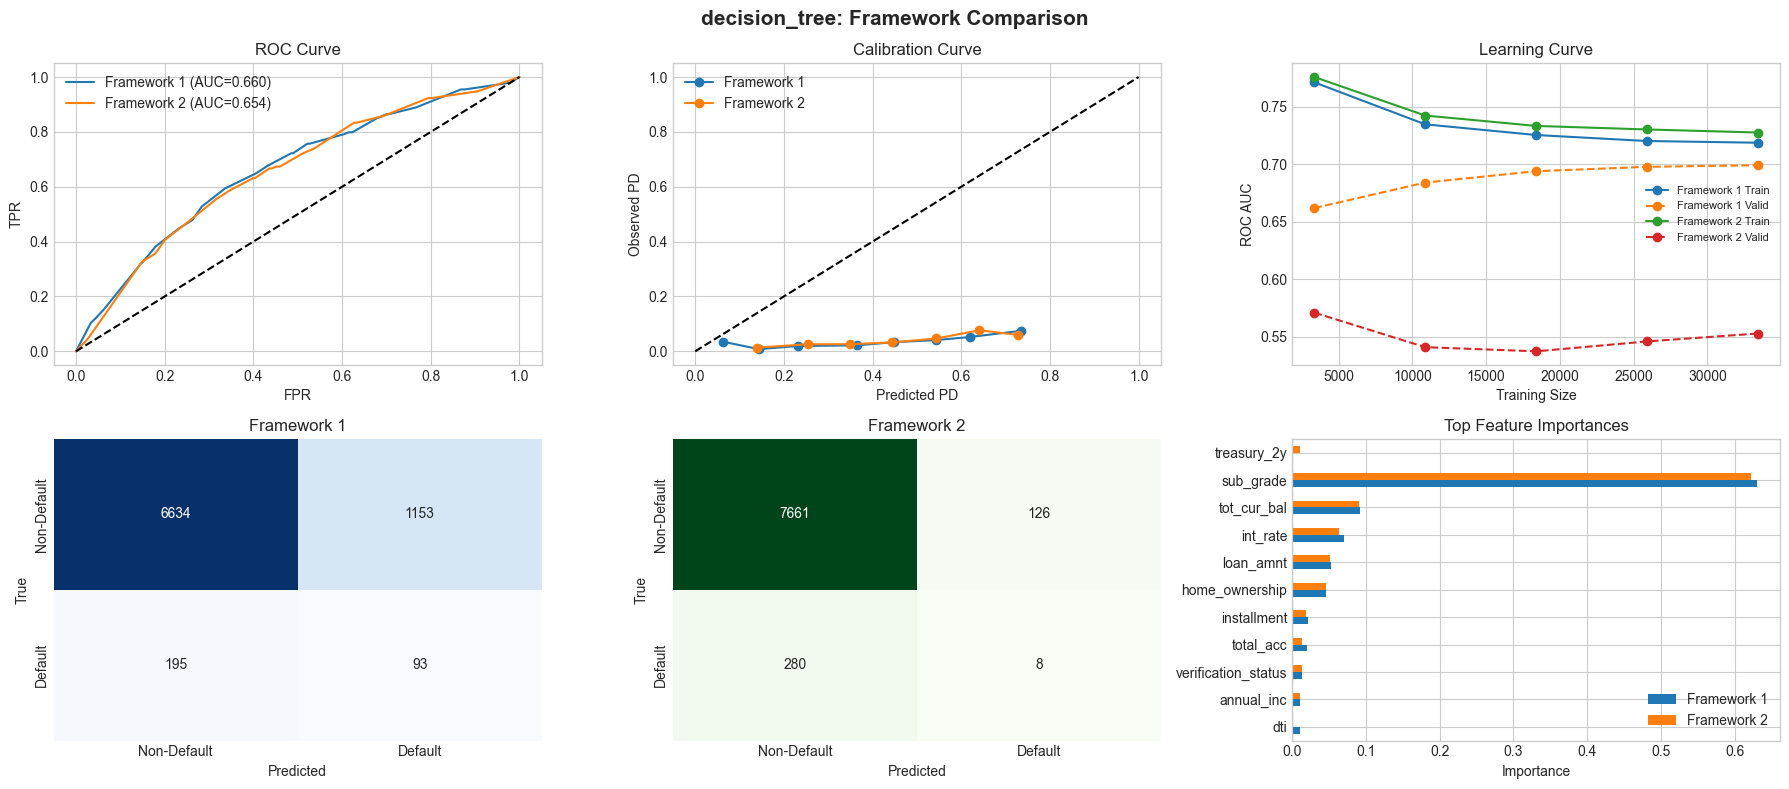

In [89]:
compare_framework_models_eval(frameworks, threshold, name)

- ROC AUC = 0.705, essentially unchanged compared to 0.707 in Framework 1, indicating that macroeconomic features do not materially improve overall ranking performance for XGBoost

- At threshold = 0.7, the model still fails to identify any defaults, showing no improvement in high-confidence default detection. The calibration curve also remains very similar to the previous framework, suggesting that the probability estimates are largely unaffected

- Feature importance remains dominated by borrower-level signals such as `sub_grade` and `grade`, while macro variables appear only in lower importance ranks. This indicates that the model already captures most predictive information from borrower characteristics, leaving limited additional signal for macro variables to contribute within the observed time period


Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7787
           1       0.00      0.00      0.00       288

    accuracy                           0.96      8075
   macro avg       0.48      0.50      0.49      8075
weighted avg       0.93      0.96      0.95      8075




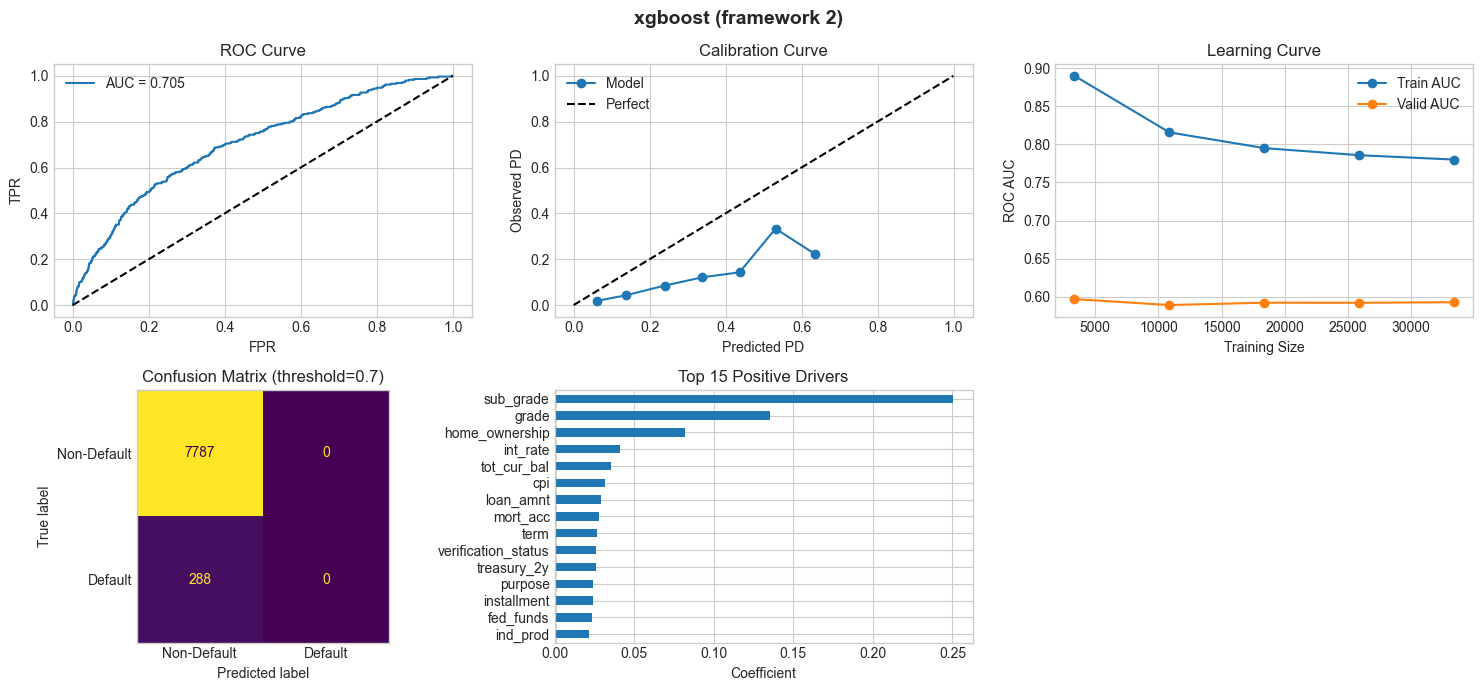

In [90]:
name = "xgboost"
plot_evaluate_model(results_step2[name], name+" (framework 2)", threshold)

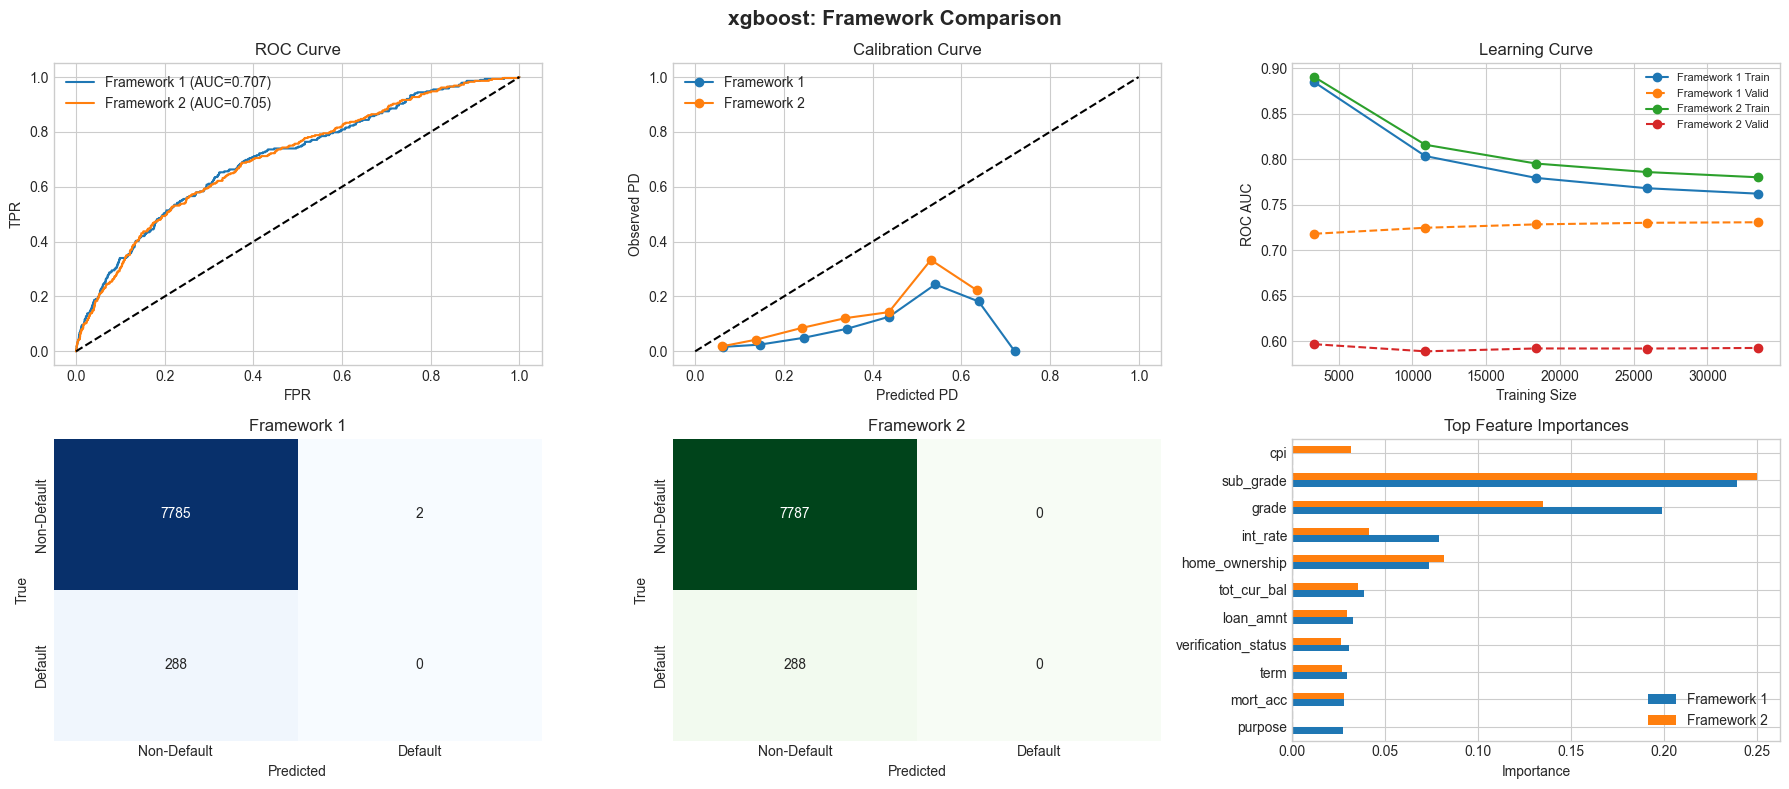

In [91]:
compare_framework_models_eval(frameworks, threshold, name)

- ROC AUC = 0.690, essentially unchanged, indicating that macro variables do not improve overall ranking performance for Random Forest

- The model’s overfitting gap increases slightly, suggesting that the additional macro features introduce extra complexity without adding predictive signal. This allows the model to fit noise more easily in the training set, without improving generalization


Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7787
           1       0.00      0.00      0.00       288

    accuracy                           0.96      8075
   macro avg       0.48      0.50      0.49      8075
weighted avg       0.93      0.96      0.95      8075




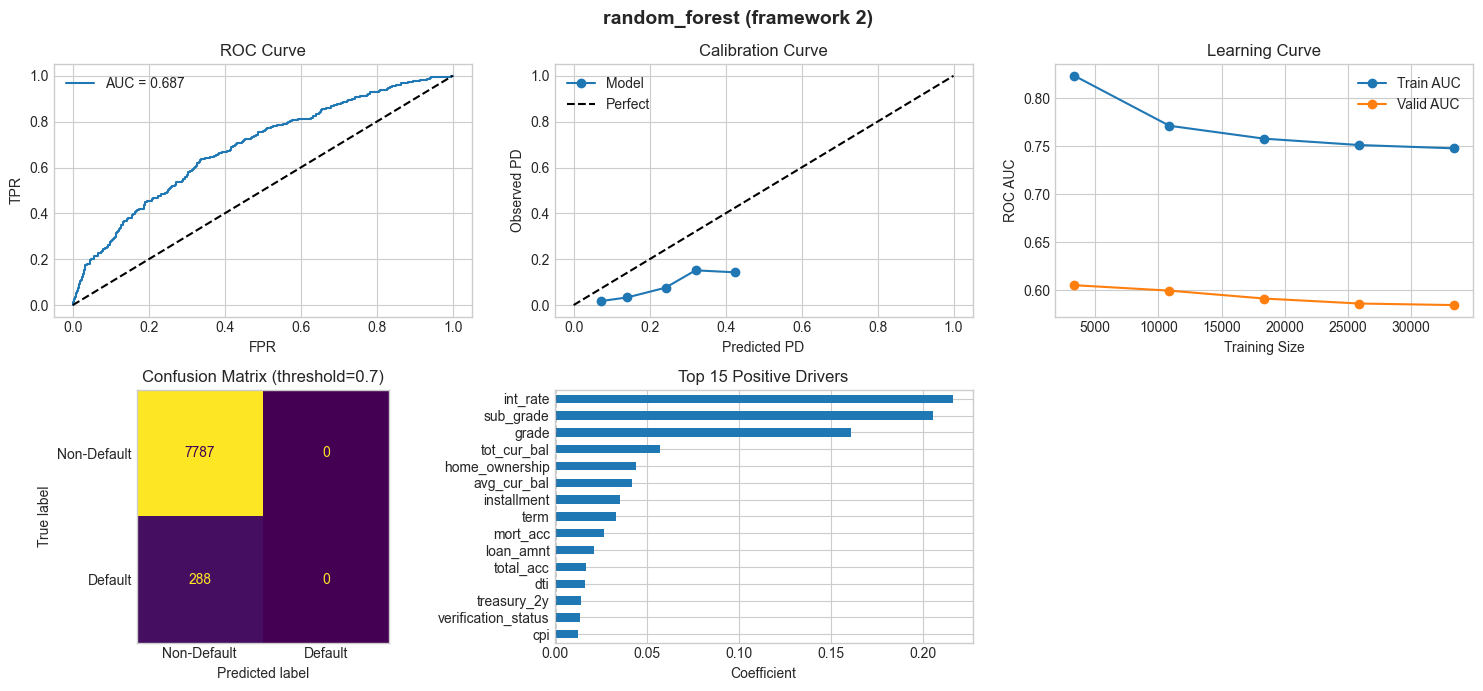

In [92]:
name = "random_forest"
plot_evaluate_model(results_step2[name], name+" (framework 2)", threshold)

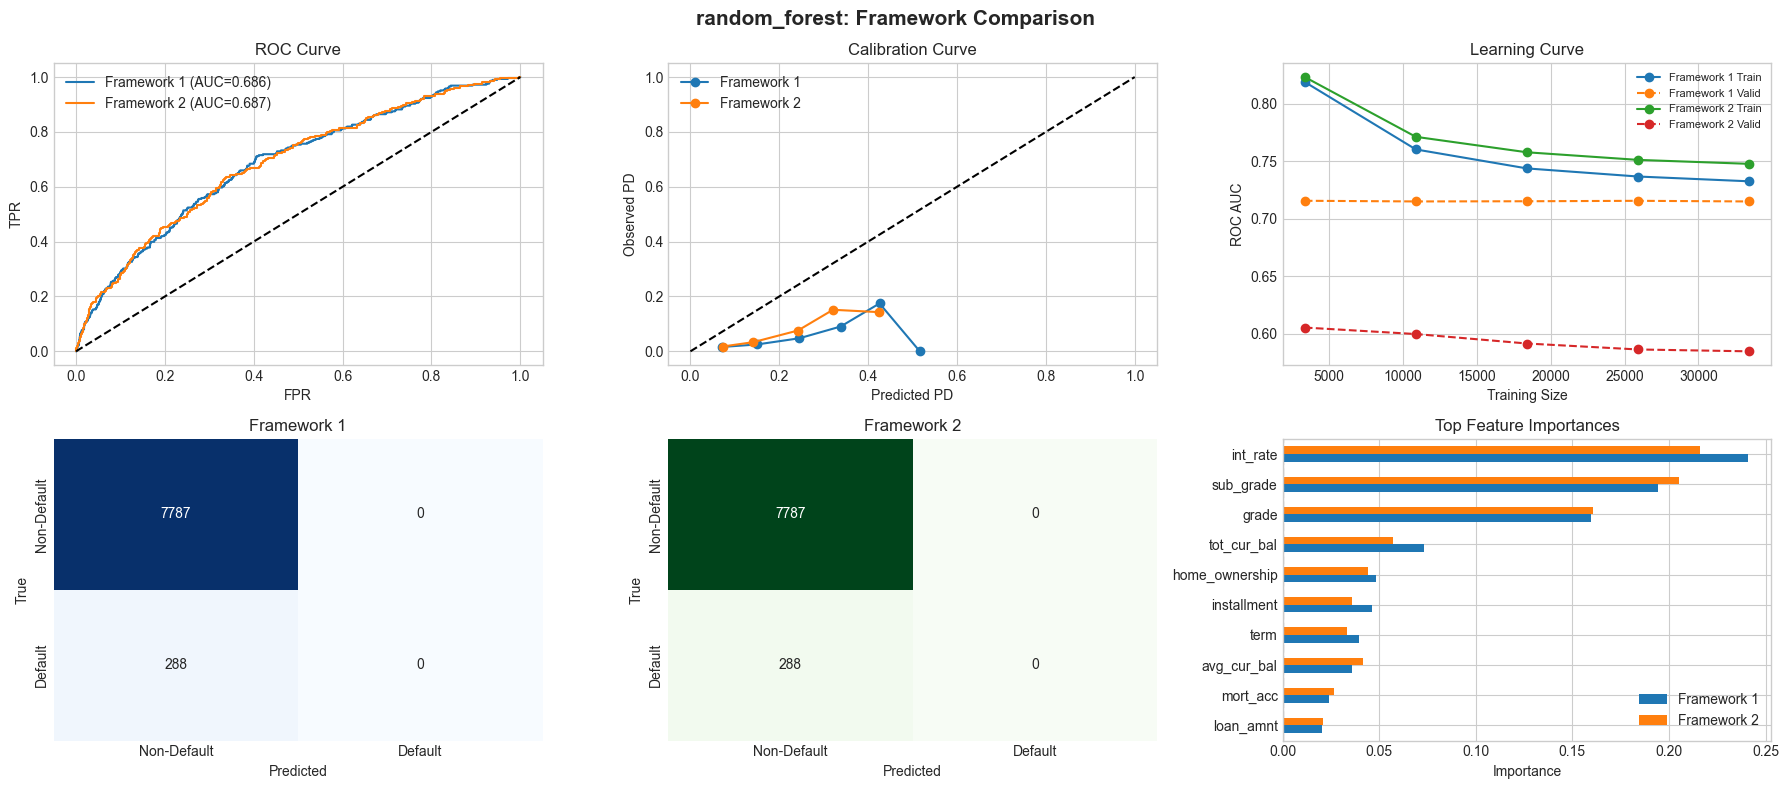

In [93]:
compare_framework_models_eval(frameworks, threshold, name)

### Comparing models

Linear models show slight improvements in AUC, while tree-based models mostly stay the same or degrade slightly. This suggests that any additional signal from macro variables is weak and mainly helps simpler linear structures rather than nonlinear learners.

Calibration does not improve in a systematic way. In some cases, predicted probabilities become less well aligned with observed default rates, especially at higher risk levels. This indicates that macro features are not helping the models produce more reliable probability estimates


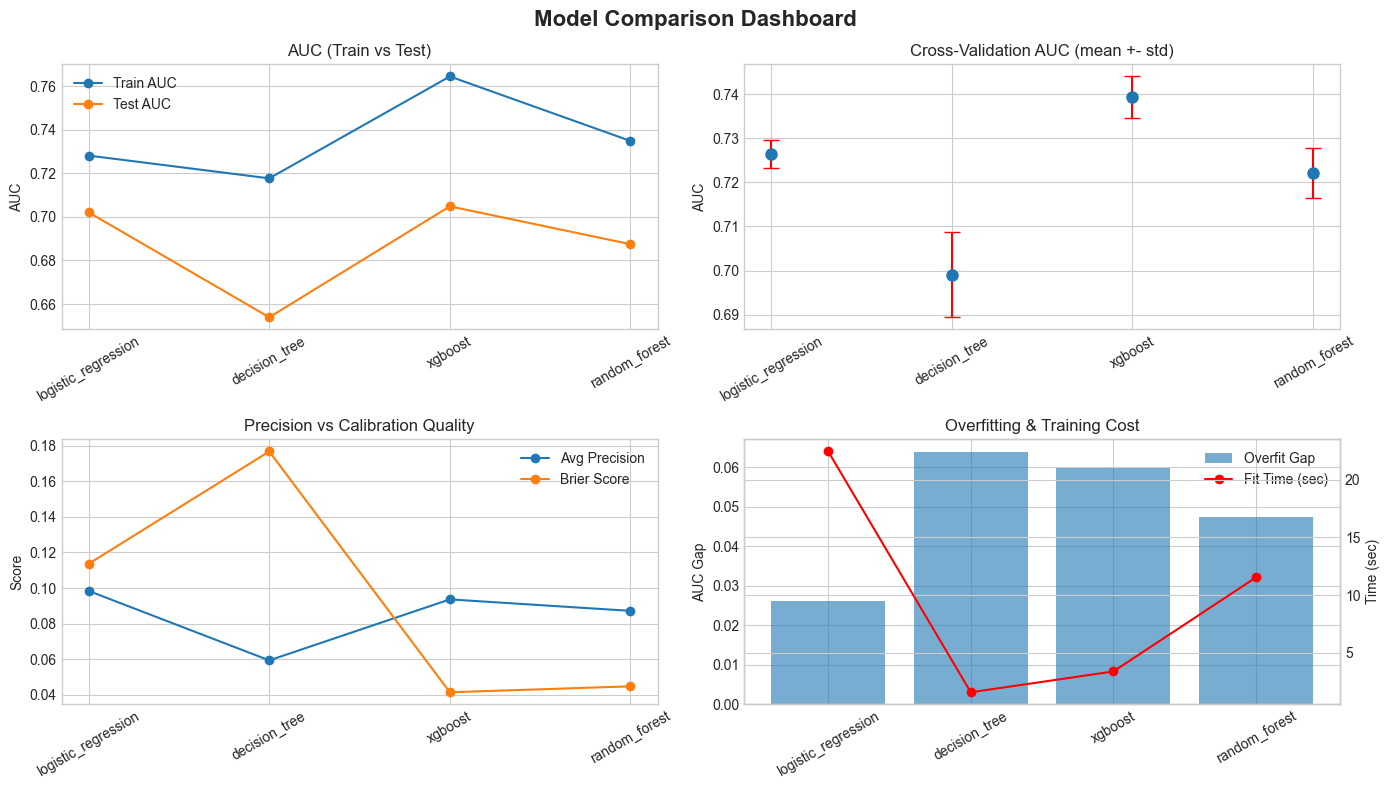

In [94]:
plot_model_comparison(results_step2)


Feature importance analysis consistently shows that macro variables rank below borrower-level and credit-grade features. Most of the predictive power still comes from variables like sub_grade, grade, and interest-rate-related features. The macro variables contribute little independent information, likely because they vary slowly over time and are highly correlated across the dataset period.

At the framework level, performance differences between Framework 1 and Framework 2 are minimal in terms of AUC. Tree models show slightly higher variance and overfitting risk after adding macro features, while linear models gain only marginal benefit. Training cost increases due to the higher dimensionality, but without a corresponding performance gain.

Overall, macro features behave more like a coarse time-period proxy than a strong explanatory signal. With limited macro variation over the sample period, they add complexity but little new information, which explains the lack of consistent improvement across models.

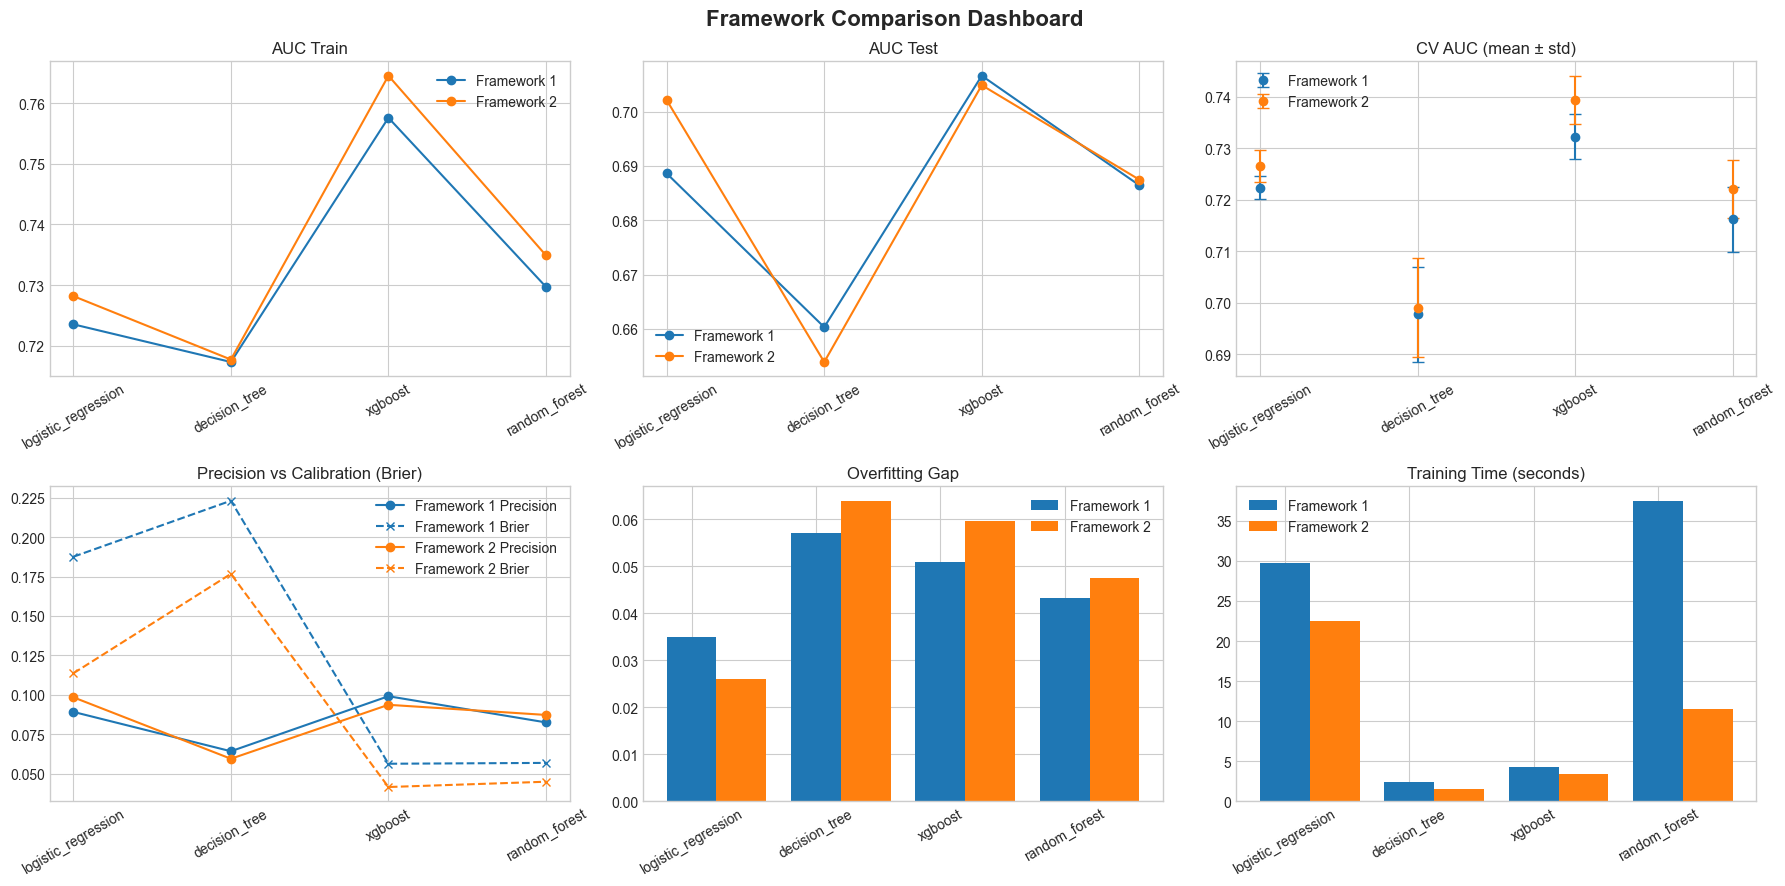

In [95]:
plot_framework_model_comparison(frameworks)

__________________


# **III. Regime-Dependent Framework (3) : Borrower + Macro + Regime Features**


$$D = f(X_\text{borrower}, M_t, R_t)$$

In [96]:
macro_features = [
    'fed_funds', 'unemp_rate', 'cpi', 'ind_prod',
    'real_gdp', 'credit_spread', 'treasury_10y', 'treasury_2y'
]

cluster_df = macro_df.copy()

X_macro = cluster_df[macro_features]

## **1. Clustering to capture Regimes**

To determine the appropriate number of latent macroeconomic states, we used several clustering diagnostics.

<br>

**Elbow Method (KMeans)**

It measures the Within-Cluster Sum of Squares (WCSS).
We look for the elbow (inflection point) i.e the point where adding additional clusters produces only marginal reductions in WCSS


$$ WCSS = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2 $$

-  K$: number of clusters

- $C_k$: observations belonging to cluster k

- $\mu_k$: centroid of cluster k

<br>

**Silhouette Score**

It evaluates both cluster compactness and separation. Higher values are better

For each observation $i$:

$$s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}$$

- $a(i)$: average intra-cluster distance
- $b(i)$: average distance to the nearest neighboring cluster





<br>


**Gaussian Mixture Information Criteria**

For probabilistic clustering using Gaussian Mixture Models (GMM), model complexity is evaluated through:
* Akaike Information Criterion (AIC)
* Bayesian Information Criterion (BIC)

Lower values are better

$$BIC = -2 \log(L) + p \log(n)$$
$$AIC = -2 \log(L) + 2p$$


- $L$: model likelihood
* $p$: number of estimated parameters
* $n$: number of observations


<br>


**Agglomerative Hierarchical Clustering (AHC)**

It  builds nested hierarchy of clusters by iteratively merging the closest groups.

The dendrogram visualization helps identify:
* natural cluster separations
* merge distances
* stable hierarchical structures

Large vertical jumps in the dendrogram typically indicate meaningful regime boundaries.

### Clustering (KMeans, GMM, AHC)

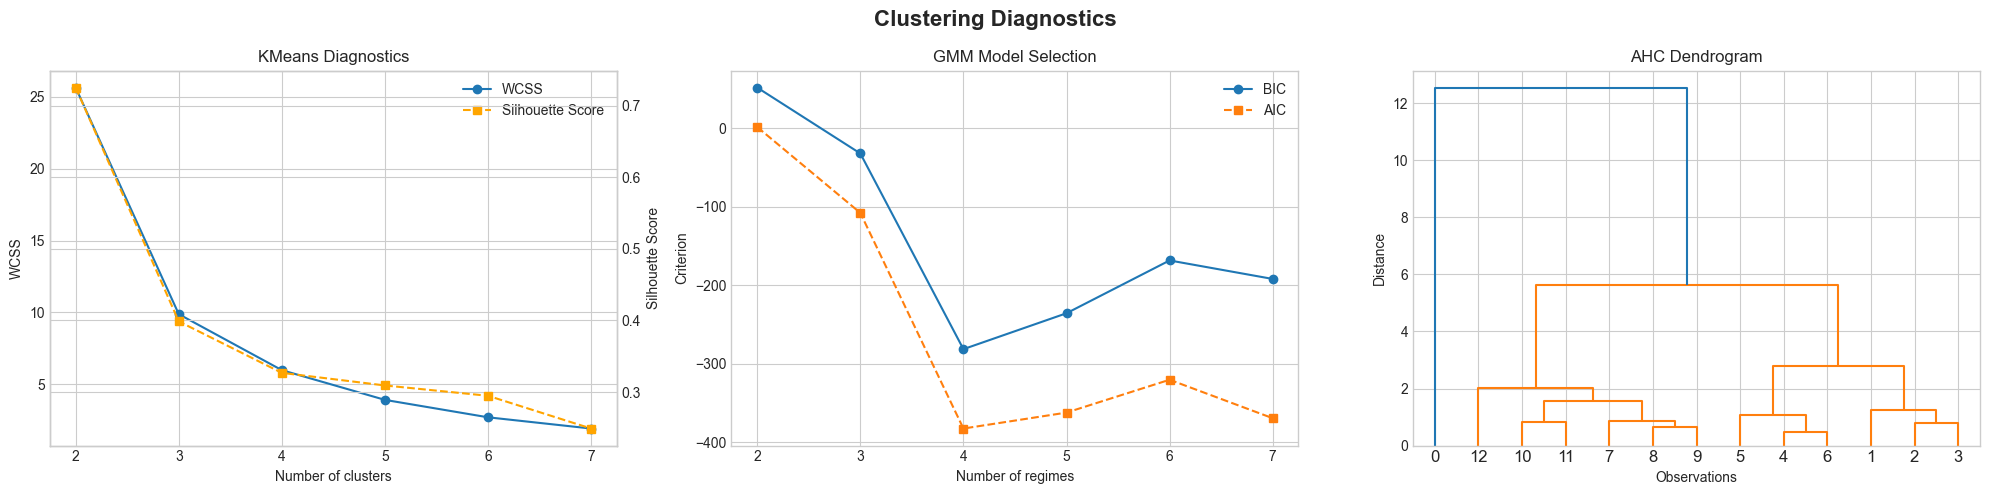

In [97]:
K_range = range(2, 8)
wcss, silhouette_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_macro)
    wcss.append(km.inertia_)

    silhouette_scores.append(silhouette_score(X_macro, labels))

bic_scores, aic_scores = [], []

for k in K_range:
    gmm = GaussianMixture(
        n_components=k, covariance_type='full', random_state=SEED)

    gmm.fit(X_macro)
    bic_scores.append(gmm.bic(X_macro))
    aic_scores.append(gmm.aic(X_macro))

Z = linkage(X_macro, method='ward')


fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(
    "Clustering Diagnostics", fontsize=16, fontweight='bold')
# Elbow method
ax1 = axes[0]
line1 = ax1.plot(K_range, wcss, marker='o', label='WCSS')
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("WCSS")
ax1.grid(True)
ax1_twin = ax1.twinx()
line2 = ax1_twin.plot(
    K_range, silhouette_scores, marker='s', c='orange',
    linestyle='--', label='Silhouette Score'
)
ax1_twin.set_ylabel("Silhouette Score")
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')
ax1.set_title("KMeans Diagnostics")
# GMM BIC + AIC
axes[1].plot(K_range, bic_scores, marker='o', label='BIC')
axes[1].plot(K_range, aic_scores, marker='s', linestyle='--', label='AIC')
axes[1].set_title("GMM Model Selection")
axes[1].set_xlabel("Number of regimes")
axes[1].set_ylabel("Criterion")
axes[1].legend()
axes[1].grid(True)
# Dendrogram
dendrogram(Z, truncate_mode='level', p=5, ax=axes[2])
axes[2].set_title("AHC Dendrogram")
axes[2].set_xlabel("Observations")
axes[2].set_ylabel("Distance")
plt.tight_layout()
plt.show()

Looking jointly at the diagnostics, the macroeconomic structure appears relatively stable around 3 to 4 clusters.

* KMeans shows a clear elbow around K=3, while the silhouette score declines afterward, suggesting diminishing clustering quality
* Gaussian Mixture Models (GMM) indicate slightly richer structure, with both AIC and BIC reaching their minimum around K=4
* Agglomerative Hierarchical Clustering (AHC) dendrogram reveals 2 dominant macro regimes


We can conclude that a small number of latent macroeconomic regimes seems sufficient to capture the main cyclical dynamics of the economy while preserving interpretability.

In [98]:
K = 3

# KMeans
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20)
cluster_df["cluster_kmeans"] = kmeans.fit_predict(X_macro)

# GMM
gmm = GaussianMixture(n_components=K, random_state=SEED, covariance_type="full")
cluster_df["cluster_gmm"] = gmm.fit_predict(X_macro)

# AHC
ahc = AgglomerativeClustering(n_clusters=K, linkage="ward")
cluster_df["cluster_ahc"] = ahc.fit_predict(X_macro)

cluster_df.head()

,date,fed_funds,unemp_rate,cpi,ind_prod,real_gdp,credit_spread,treasury_10y,treasury_2y,cluster_kmeans,cluster_gmm,cluster_ahc
0,2016-09-01,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027,1,1,1
1,2018-01-01,-0.766178,0.072889,-0.505788,-0.917716,-0.371776,-0.633471,-0.630677,-0.686072,2,2,0
2,2018-02-01,-0.573811,0.388744,-0.276375,-0.751804,-0.371776,-1.453080,0.132002,-0.402029,2,2,0
3,2018-03-01,-0.573811,0.072889,-0.259939,-0.415798,-0.371776,-0.828616,0.077525,-0.212668,2,2,0
4,2018-04-01,-0.039460,0.072889,-0.037375,0.343757,0.116164,-0.321239,0.159241,-0.023306,2,0,0


### Regime Interpretation

All 3 clustering methods produce very similar macro regime paths, with only small differences in exact switch timing.
- The regime sequence is stable over time and follows a clear pattern: an initial regime in 2016–2017
- A second regime during 2017–mid 2018 and a final regime in late 2018
- This aligns with the macroeconomic environment, especially the shift from low interest rates to a tightening cycle and later stabilization

Because KMeans, GMM, and hierarchical clustering agree on these broad transitions, combining them via a majority vote to define the final regime is reasonable and adds stability.

The fact that only a few regime changes are detected is expected given the short time span. With a longer dataset, more distinct macro phases would likely emerge.

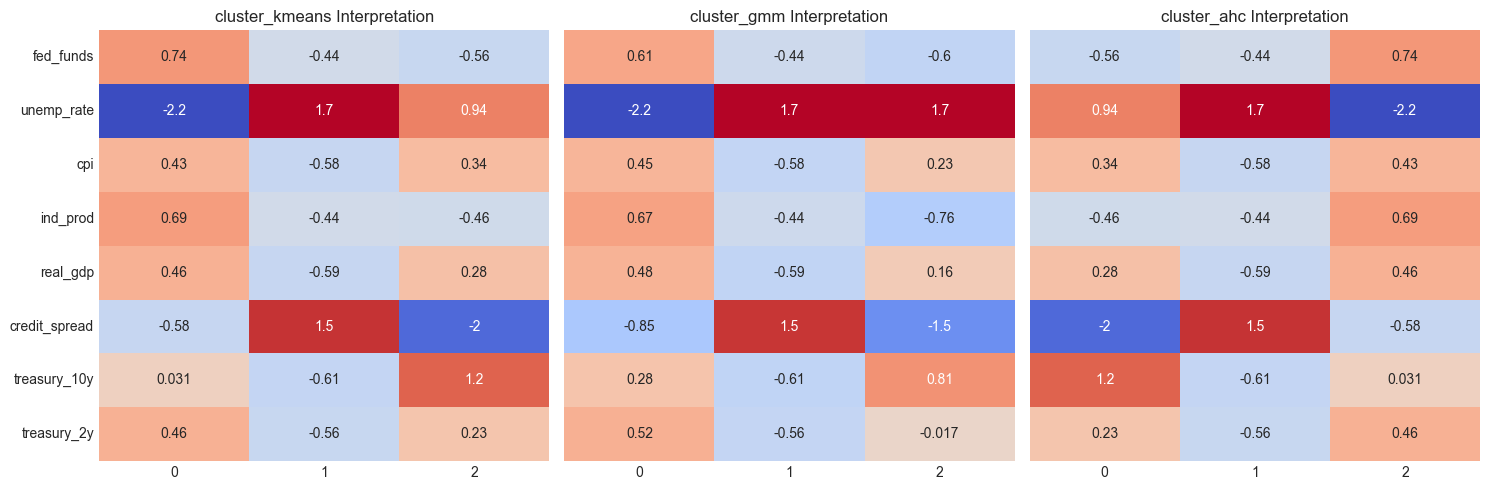

In [99]:
clusters = ["cluster_kmeans", "cluster_gmm", "cluster_ahc"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, cluster in enumerate(clusters):
    regime_profile = cluster_df.groupby(cluster)[macro_features].mean().T
    # Standardization, regimes become comparable across macro variables
    regime_z = (regime_profile - regime_profile.mean()) / regime_profile.std()

    sns.heatmap(regime_z, cmap="coolwarm", annot=True, cbar=False, ax=axes[i])
    axes[i].set_xlabel("")
    axes[i].set_title(f"{cluster} Interpretation")
plt.tight_layout()
plt.show()

In [100]:
cluster_df["date"].min(), cluster_df["date"].max()

(Timestamp('2016-09-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

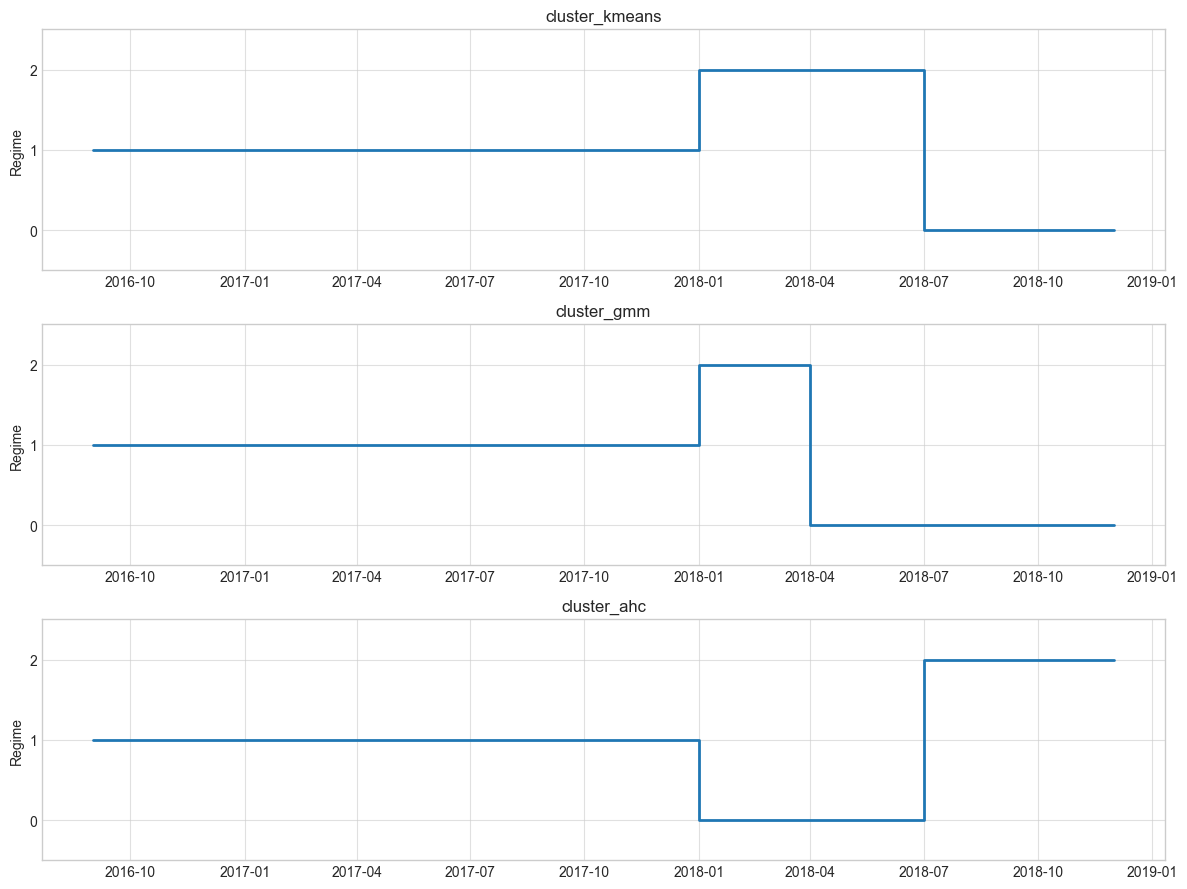

In [133]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for i, cluster in enumerate(clusters):
    axes[i].plot(
        cluster_df["date"], cluster_df[cluster],
        drawstyle="steps-post", label=cluster, linewidth=2
    )
    axes[i].set_ylabel("Regime")
    axes[i].set_yticks(cluster_df[cluster].unique())
    axes[i].set_title(cluster)
    axes[i].set_ylim([-0.5, 2.5])
    axes[i].grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

### Principal Component Analysis (PCA)

In [102]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_macro)

cluster_df['pc1'] = X_pca[:, 0]
cluster_df['pc2'] = X_pca[:, 1]

In [103]:
scree_df = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_) + 1),
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)

})


loadings_df = pd.DataFrame(
    pca.components_, columns=macro_features,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

- PC1 explains about 80% of the total variance, showing that the macro dataset is effectively dominated by a single underlying factor. This first component acts like a general macro conditions index, where all variables move in the same direction. In practical terms, it summarizes the overall economic environment rather than separating distinct signals

- PC2 captures around 15% of the variance and adds a secondary dimension related to financial stress, mainly contrasting credit spreads with short-term interest rates

Because most of the information is concentrated in PC1, the macro features are close to one-dimensional in this dataset. This helps explain why they add limited new predictive value: much of their variation can already be approximated by a single factor, which is also strongly correlated with time

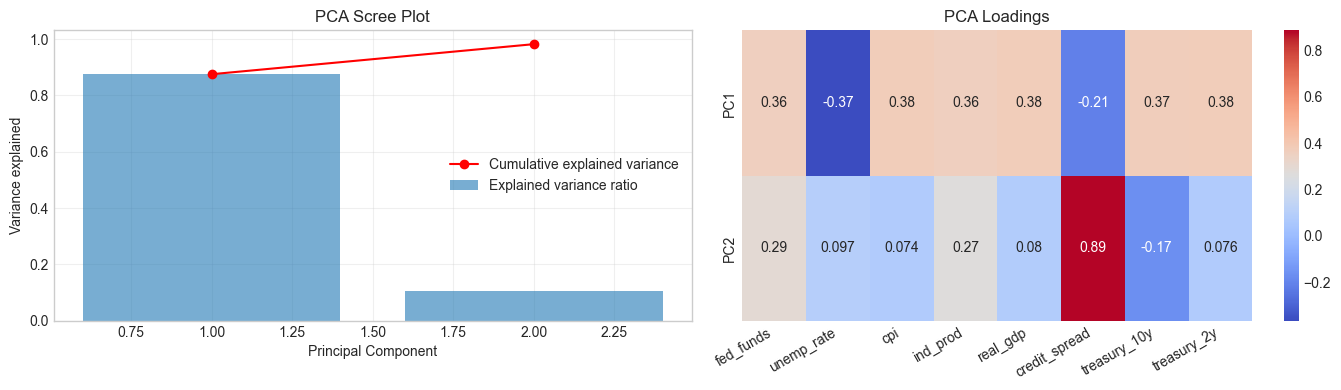

In [104]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(
    scree_df["component"], scree_df["explained_variance_ratio"],
    alpha=0.6, label="Explained variance ratio"
)
axes[0].plot(
    scree_df["component"], scree_df["cumulative_explained_variance"],
    marker="o", color="red", label="Cumulative explained variance"
)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance explained")
axes[0].set_title("PCA Scree Plot")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
# Loadings heatmap
sns.heatmap(loadings_df, annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("PCA Loadings")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

PCA projection shows that the regime clusters are meaningfully separated in the reduced macro space.
- One regime stands clearly apart in the lower end of PC1, corresponding to the early 2016 period, while the later observations form a denser main cluster
- A secondary sub-structure is visible, which some methods split into an additional regime while others merge it

The clustering is not purely driven by noise. The separation observed in PCA space indicates that the identified regimes correspond to real differences in macro conditions, even if those differences are relatively compressed within the dataset’s limited time span

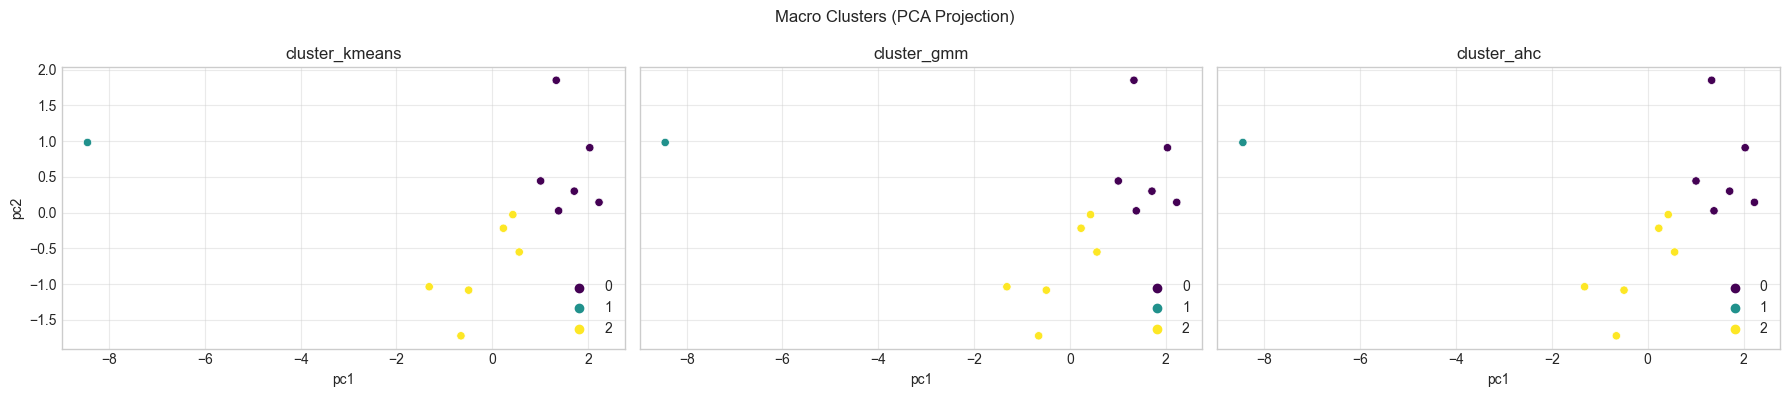

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for i, cluster in enumerate(clusters):
    sns.scatterplot(
        data=cluster_df, x='pc1', y='pc2', ax=axes[i],
        hue='cluster_kmeans', palette='viridis'
    )
    axes[i].set_title(cluster)
    axes[i].grid(True, alpha=0.4)
    axes[i].legend(loc="lower right")
plt.suptitle("Macro Clusters (PCA Projection)")
plt.tight_layout()
plt.show()

In [106]:
# majority vote across clustering methods
cluster_df["final_regime"] = (
    cluster_df[clusters]
    .mode(axis=1)[0]
    .astype(int)
)

cluster_df[[
    "date", "cluster_kmeans", "cluster_gmm",
    "cluster_ahc", "final_regime"
]].head()

,date,cluster_kmeans,cluster_gmm,cluster_ahc,final_regime
0,2016-09-01,1,1,1,1
1,2018-01-01,2,2,0,2
2,2018-02-01,2,2,0,2
3,2018-03-01,2,2,0,2
4,2018-04-01,2,0,0,0


## **2. Merging Borrower / Macro / Regime features**

In [107]:
framework2_df["date"].min(), framework2_df["date"].max()

(Timestamp('2016-09-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

In [108]:
framework3_df = framework2_df.merge(cluster_df[["date", "final_regime"]], on='date', how='left')

print(framework3_df.shape)
framework3_df.head()

(49861, 36)


,date,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,initial_list_status,emp_length,...,default,fed_funds,unemp_rate,cpi,ind_prod,real_gdp,credit_spread,treasury_10y,treasury_2y,final_regime
0,2016-09-01,1,36,0.186702,-1.502609,3,14,6,0,1.0,...,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027,1
1,2016-09-01,6,60,0.005666,-1.494785,3,12,2,1,10.0,...,1,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027,1
2,2016-09-01,5,36,0.639293,-1.494053,4,16,2,0,6.0,...,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027,1
3,2016-09-01,6,60,0.385842,-1.495062,3,15,2,1,10.0,...,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027,1
4,2016-09-01,2,36,-0.537443,-1.497489,2,8,1,1,5.0,...,0,-2.753966,3.231431,-3.136499,-2.750037,-3.148138,2.683995,-3.218337,-3.072027,1


## **3. Estimating PD**

### Train / Test split

In [109]:
X_train3, X_test3, y_train3, y_test3, train_dates3, test_dates3, split_date3 = time_train_test_split(framework3_df)

Train : (41786, 34) | Test: (8075, 34)
Split date : 2018-07-01 00:00:00


### Test Thresholds

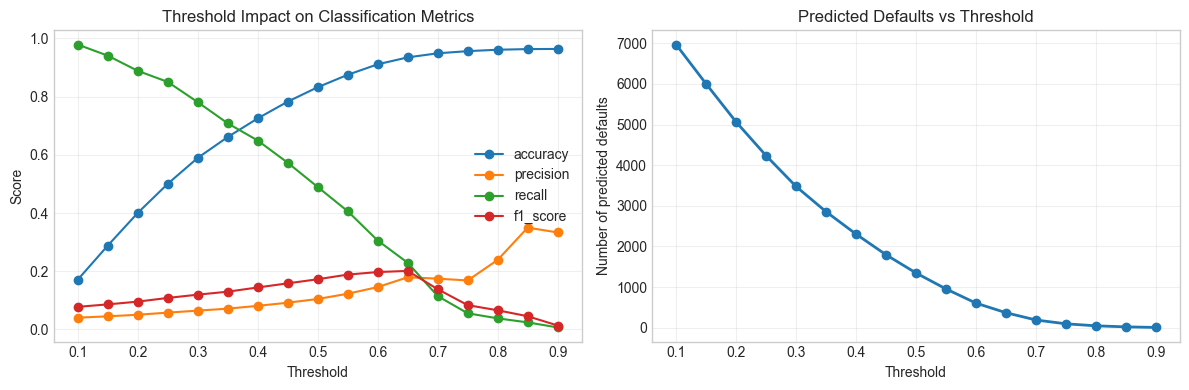

In [110]:
threshold_df = evaluate_thresholds(X_train3, y_train3, X_test3, y_test3, plot_=True)

### Testing candidate models

In [111]:
results_step3 = test_candidate_models(X_train3, y_train3, X_test3, y_test3, threshold)

Evaluated model 'logistic_regression' in 16.031seconds
Evaluated model 'decision_tree' in 2.105seconds
Evaluated model 'xgboost' in 4.682seconds
Evaluated model 'random_forest' in 11.637seconds


In [112]:
frameworks = {"Framework 1": results_step1, "Framework 2": results_step2, "Framework 3": results_step3}
frameworks_df = {"Framework 1": framework1_df, "Framework 2": framework2_df, "Framework 3": framework3_df}

ROC AUC = 0.754, representing the best performance achieved across all frameworks for this model

Adding the regime feature leads to a clear improvement in discriminative power, increasing AUC by +0.050 compared to Framework 2 and +0.065 compared to the borrower-only baseline. This indicates that the latent regime structure captures additional predictive information not present in raw macro variables alone.

At the classification level, the model identifies 33 true defaults at the 0.7 threshold, reflecting a stronger ability to flag high-risk cases. More importantly, this comes without a visible deterioration in overall ranking performance, suggesting a more effective probability separation.

Calibration also improves, particularly in the mid-range predicted probabilities (0.2–0.6), where predictions align more closely with observed default frequencies. This suggests that regime information enhances not only ranking but also probability reliability.

The regime feature itself appears among the most influential drivers, alongside inflation and unemployment variables, confirming that it captures a meaningful summary of macroeconomic conditions rather than redundant information.

Overall, this is the strongest-performing specification, showing that compressing macro dynamics into a structured regime variable provides a more effective signal than using raw macro features directly.


Classification report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7787
           1       0.17      0.11      0.14       288

    accuracy                           0.95      8075
   macro avg       0.57      0.55      0.56      8075
weighted avg       0.94      0.95      0.94      8075




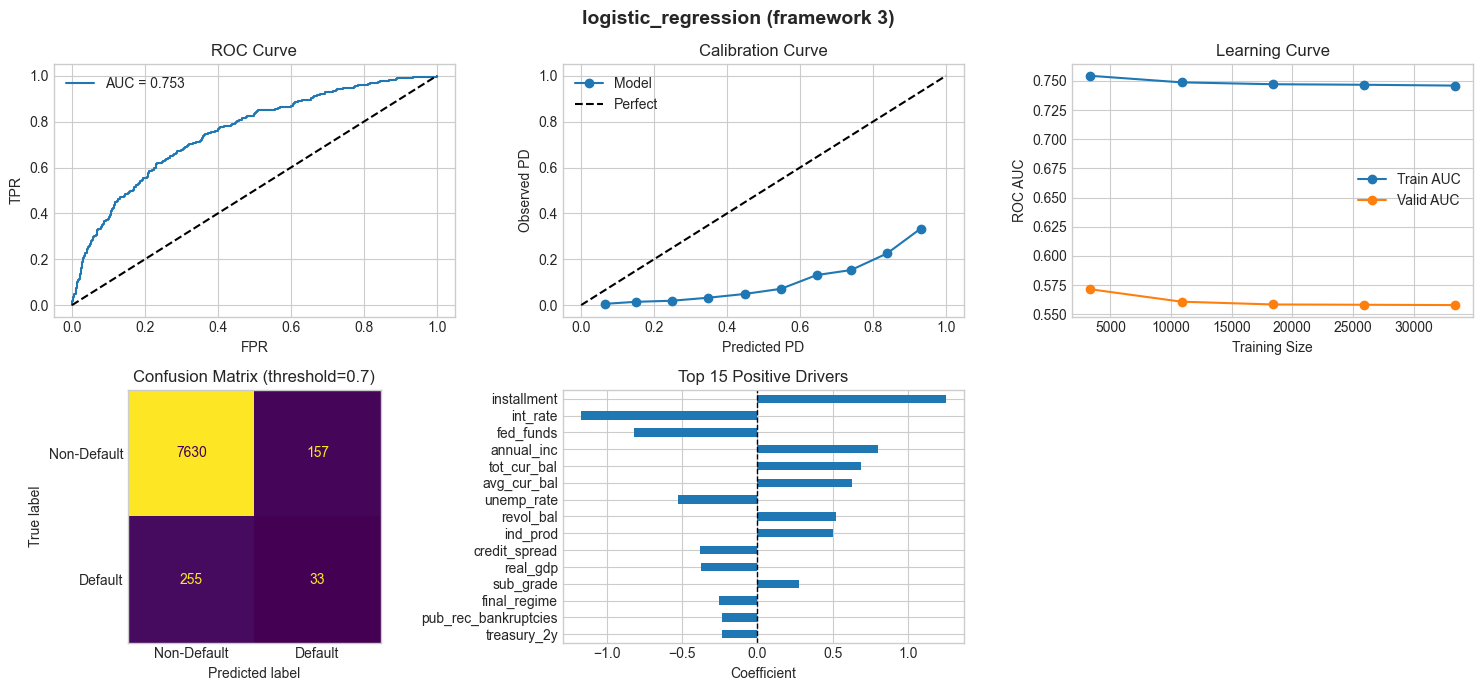

In [113]:
name = "logistic_regression"
plot_evaluate_model(results_step3[name], name+" (framework 3)", threshold)

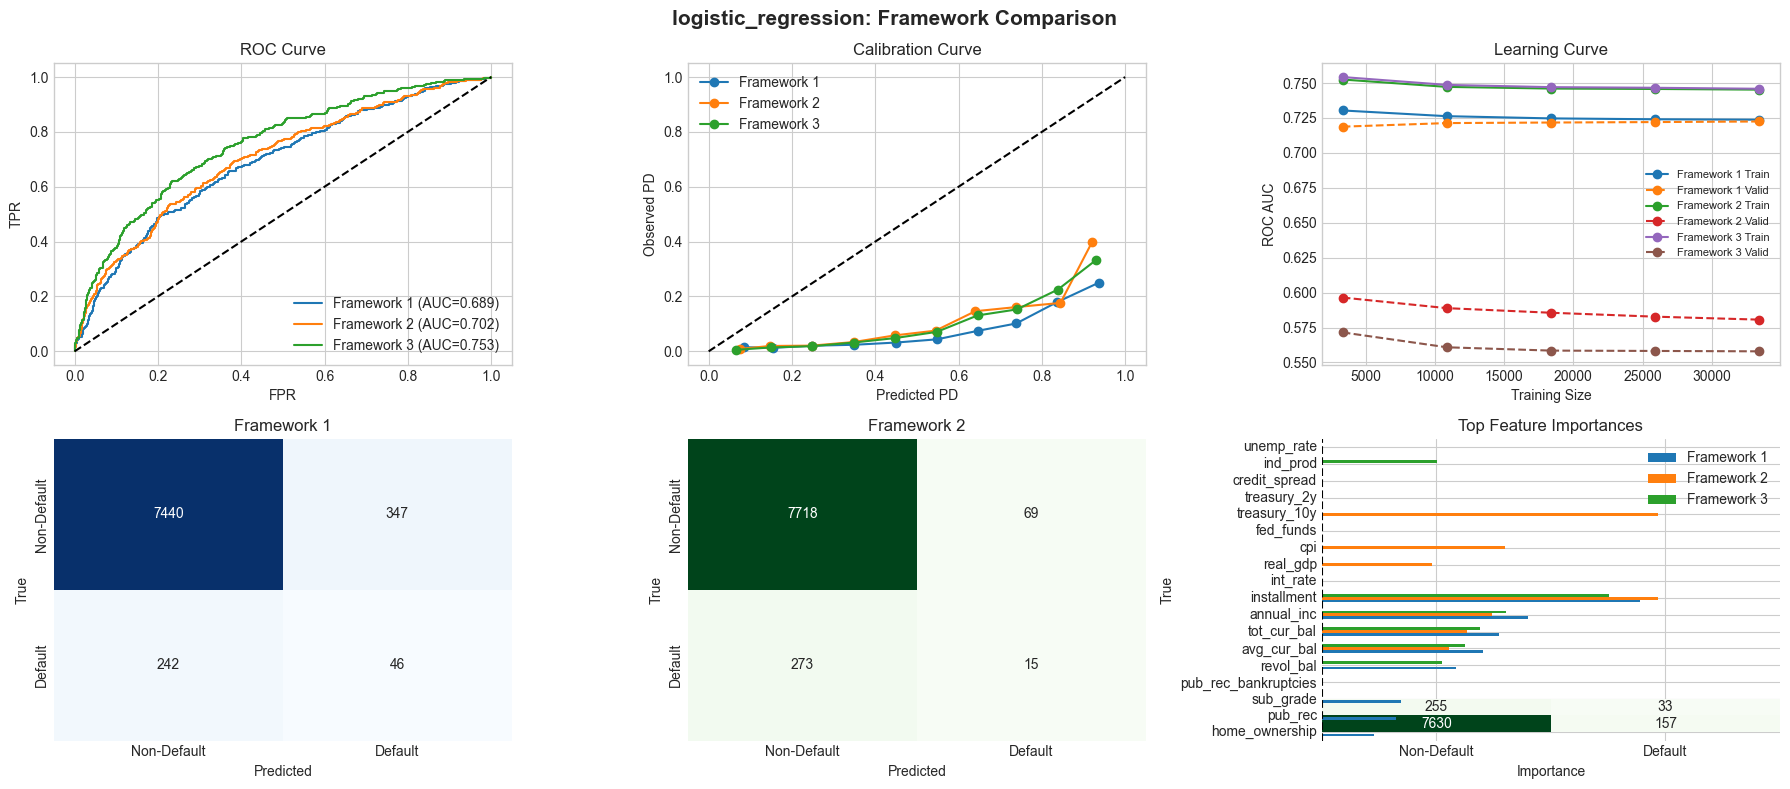

In [114]:
compare_framework_models_eval(frameworks, threshold, name)

ROC AUC = 0.653, unchanged compared to Framework 2.

Adding the regime feature does not improve Decision Tree performance. While the regime variable could be used as a split point, its low cardinality and the tree’s already strong tendency to overfit mean it does not add meaningful new structure.

The result suggests that regime information is more useful in models that aggregate signals smoothly through probabilities, rather than in hard-threshold models like decision trees.


Classification report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7787
           1       0.06      0.03      0.04       288

    accuracy                           0.95      8075
   macro avg       0.51      0.51      0.51      8075
weighted avg       0.93      0.95      0.94      8075




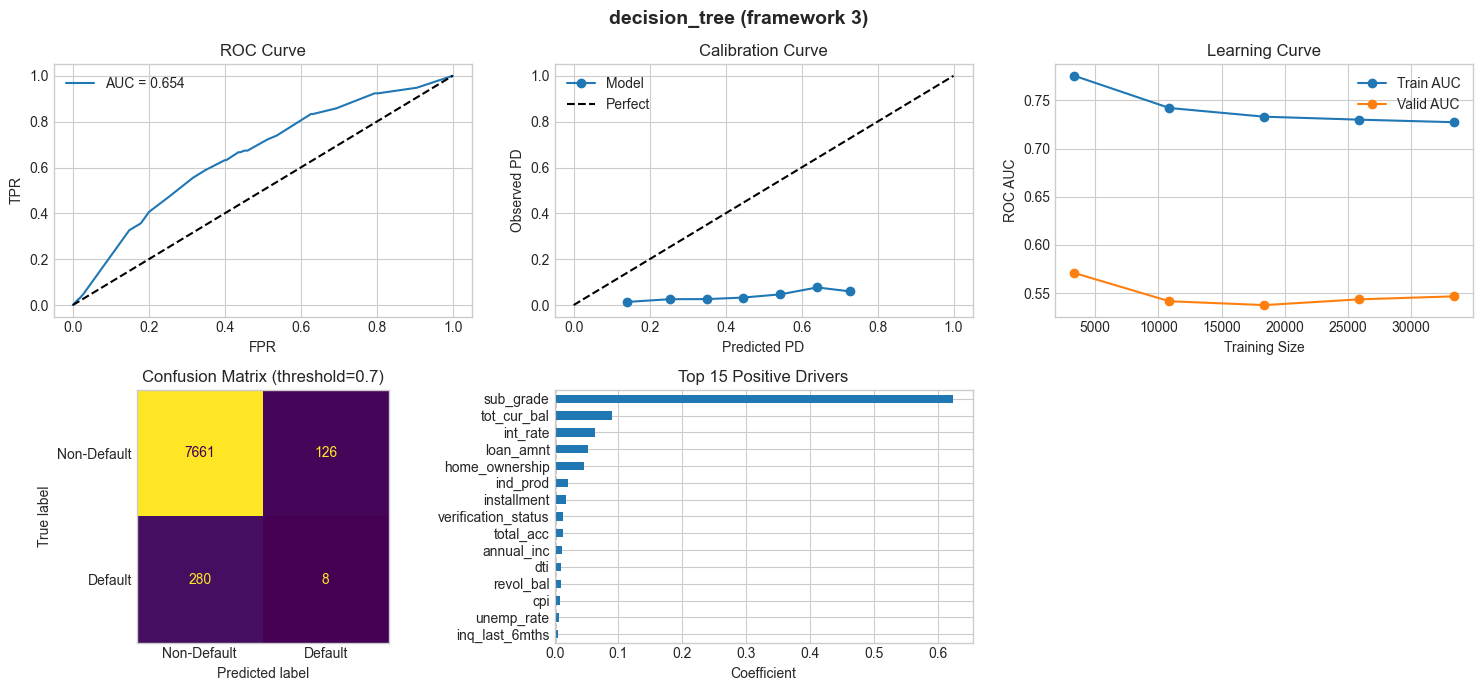

In [115]:
name = "decision_tree"
plot_evaluate_model(results_step3[name], name+" (framework 3)", threshold)

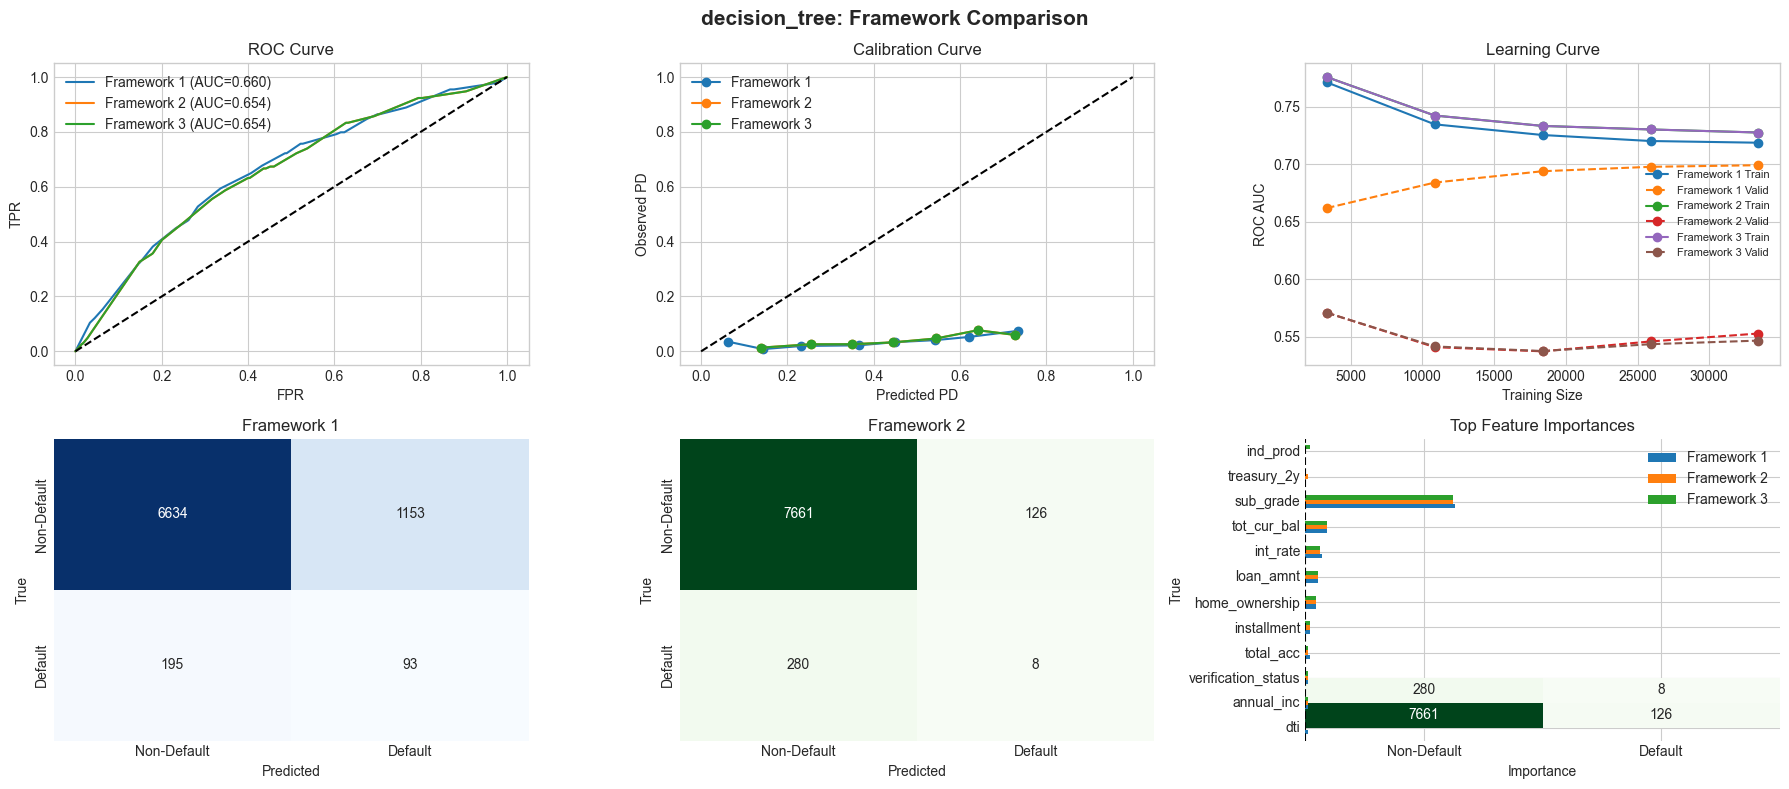

In [116]:
compare_framework_models_eval(frameworks, threshold, name)

ROC AUC = 0.703, essentially unchanged compared to Framework 2 (0.705).

The addition of the regime feature does not materially affect XGBoost performance. The model’s ability to rank defaults remains stable, suggesting that most of the predictive structure is already captured by existing borrower and macro features.

At the 0.7 threshold, the model still identifies no true defaults, indicating that predicted probabilities remain concentrated below the decision cutoff.

The regime variable does not appear among the top important features, implying that its information is likely redundant. XGBoost already captures nonlinear interactions between macroeconomic and borrower variables, which reduces the incremental value of an explicit regime label.

Overall, regime augmentation does not improve performance for this model and is effectively absorbed by the ensemble’s existing feature interactions.


Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7787
           1       0.00      0.00      0.00       288

    accuracy                           0.96      8075
   macro avg       0.48      0.50      0.49      8075
weighted avg       0.93      0.96      0.95      8075




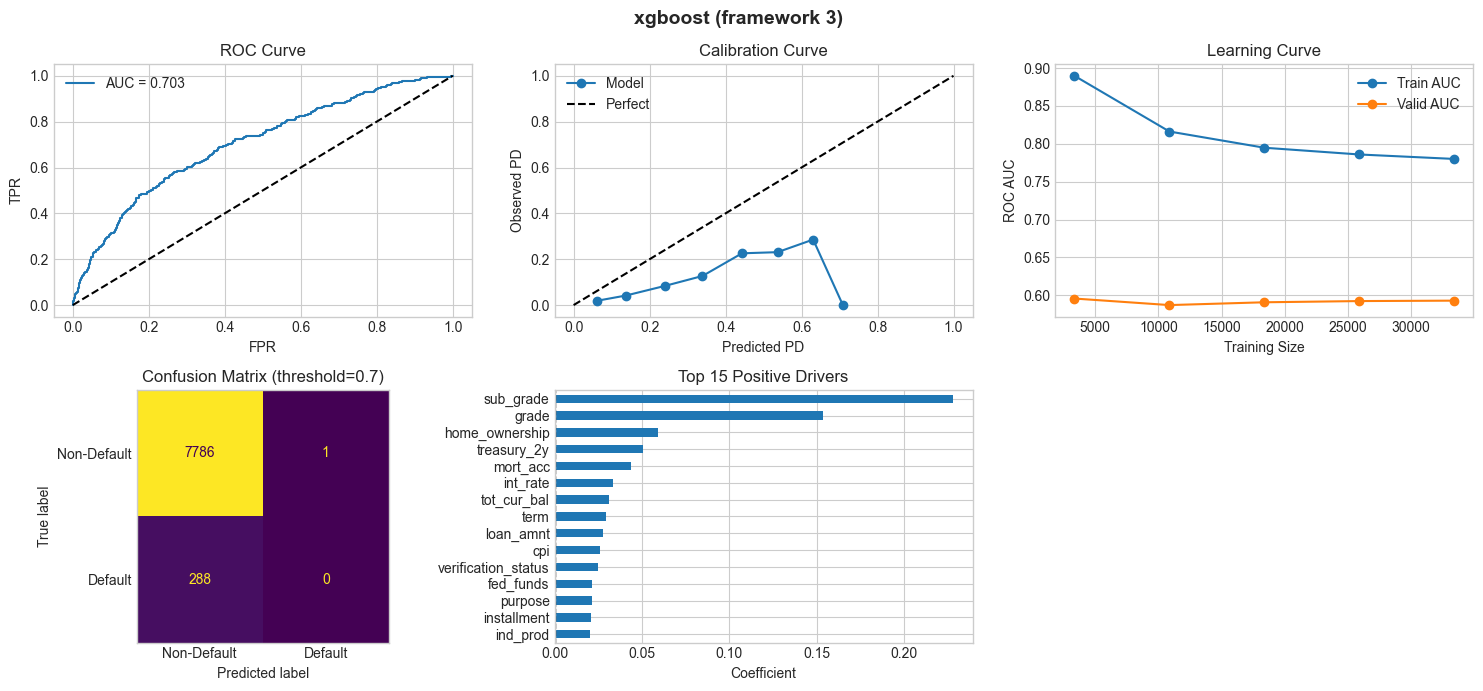

In [117]:
name = "xgboost"
plot_evaluate_model(results_step3[name], name+" (framework 3)", threshold)

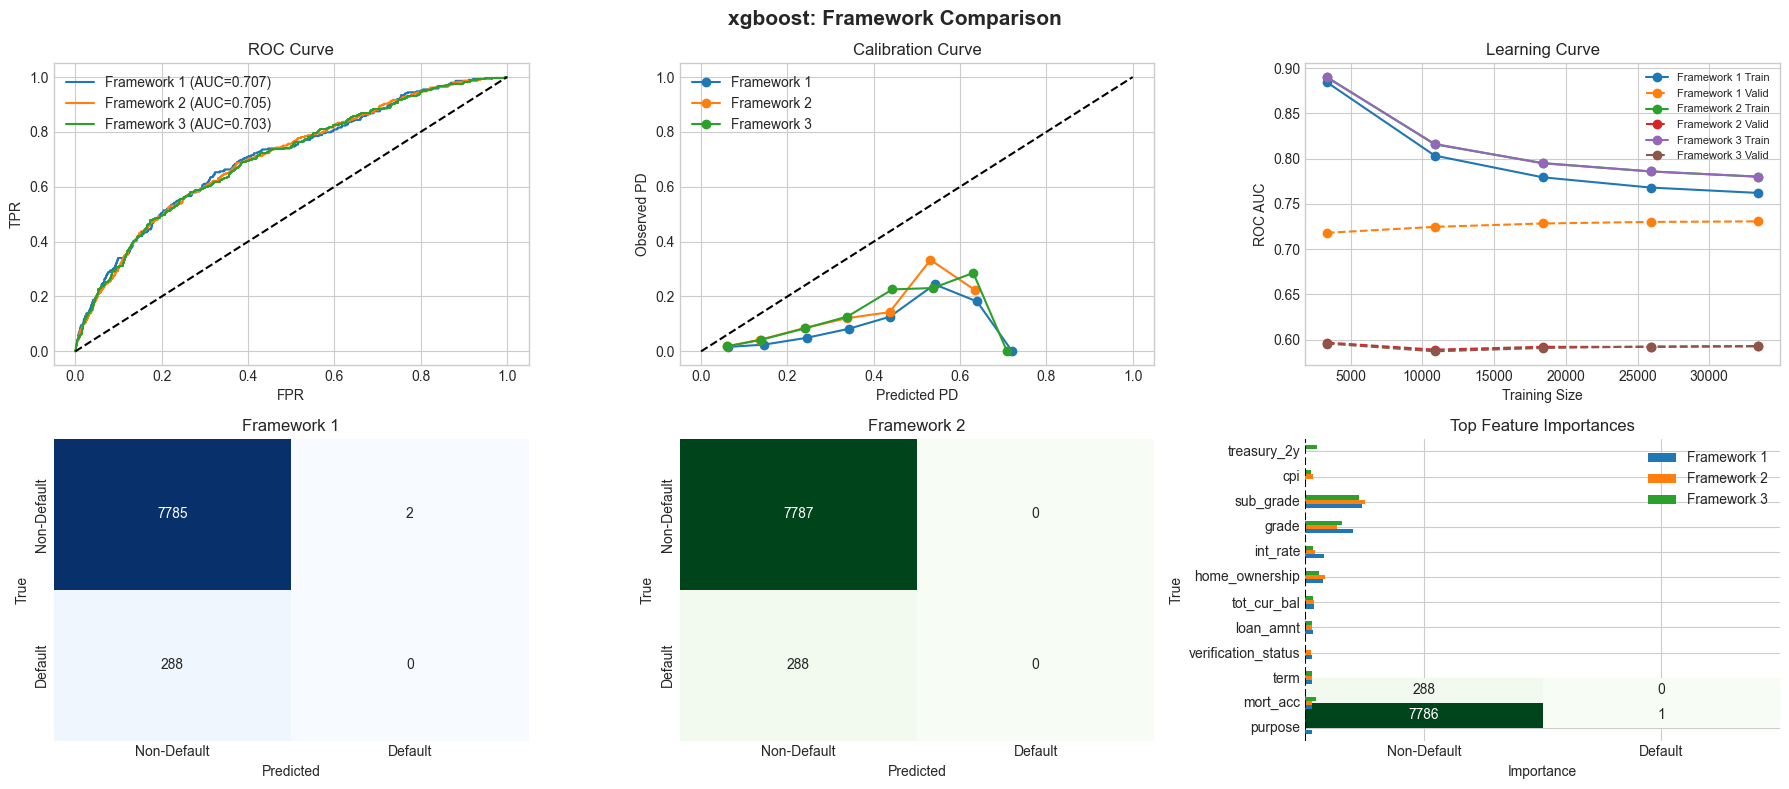

In [118]:
compare_framework_models_eval(frameworks, threshold, name)

ROC AUC = 0.687, unchanged from Framework 2.

Adding the regime feature does not improve Random Forest performance. Both ranking ability and calibration remain effectively identical to the previous framework.

At the decision threshold of 0.7, the confusion matrix shows no meaningful change, and the model continues to fail in identifying high-confidence default cases.

The regime variable appears with very low importance, indicating that it is not used effectively in the ensemble splits. This is consistent with bagged tree models relying more on stronger, higher-variance borrower and credit features, while ignoring low-cardinality summary signals like regime labels.

Overall, regime augmentation provides no measurable benefit for Random Forest, and the model behavior remains essentially unchanged.


Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7787
           1       0.00      0.00      0.00       288

    accuracy                           0.96      8075
   macro avg       0.48      0.50      0.49      8075
weighted avg       0.93      0.96      0.95      8075




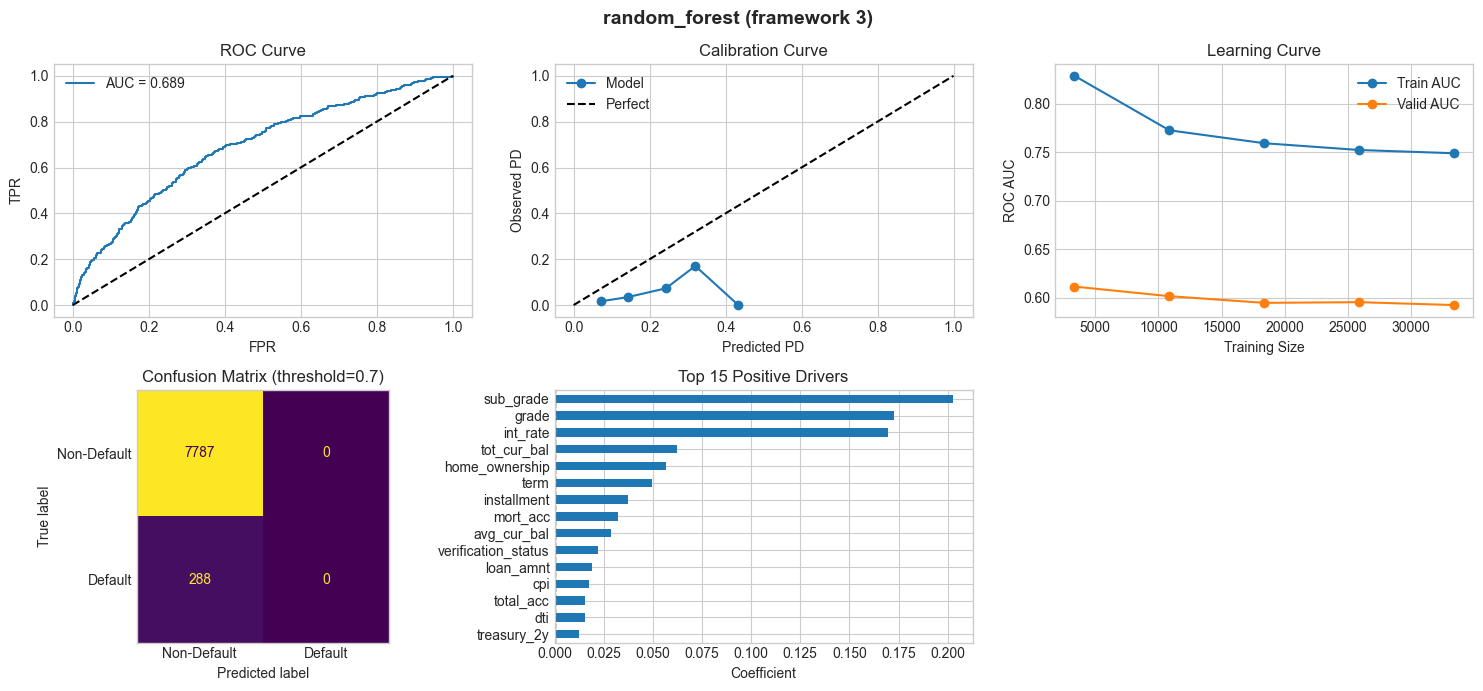

In [119]:
name = "random_forest"
plot_evaluate_model(results_step3[name], name+" (framework 3)", threshold)

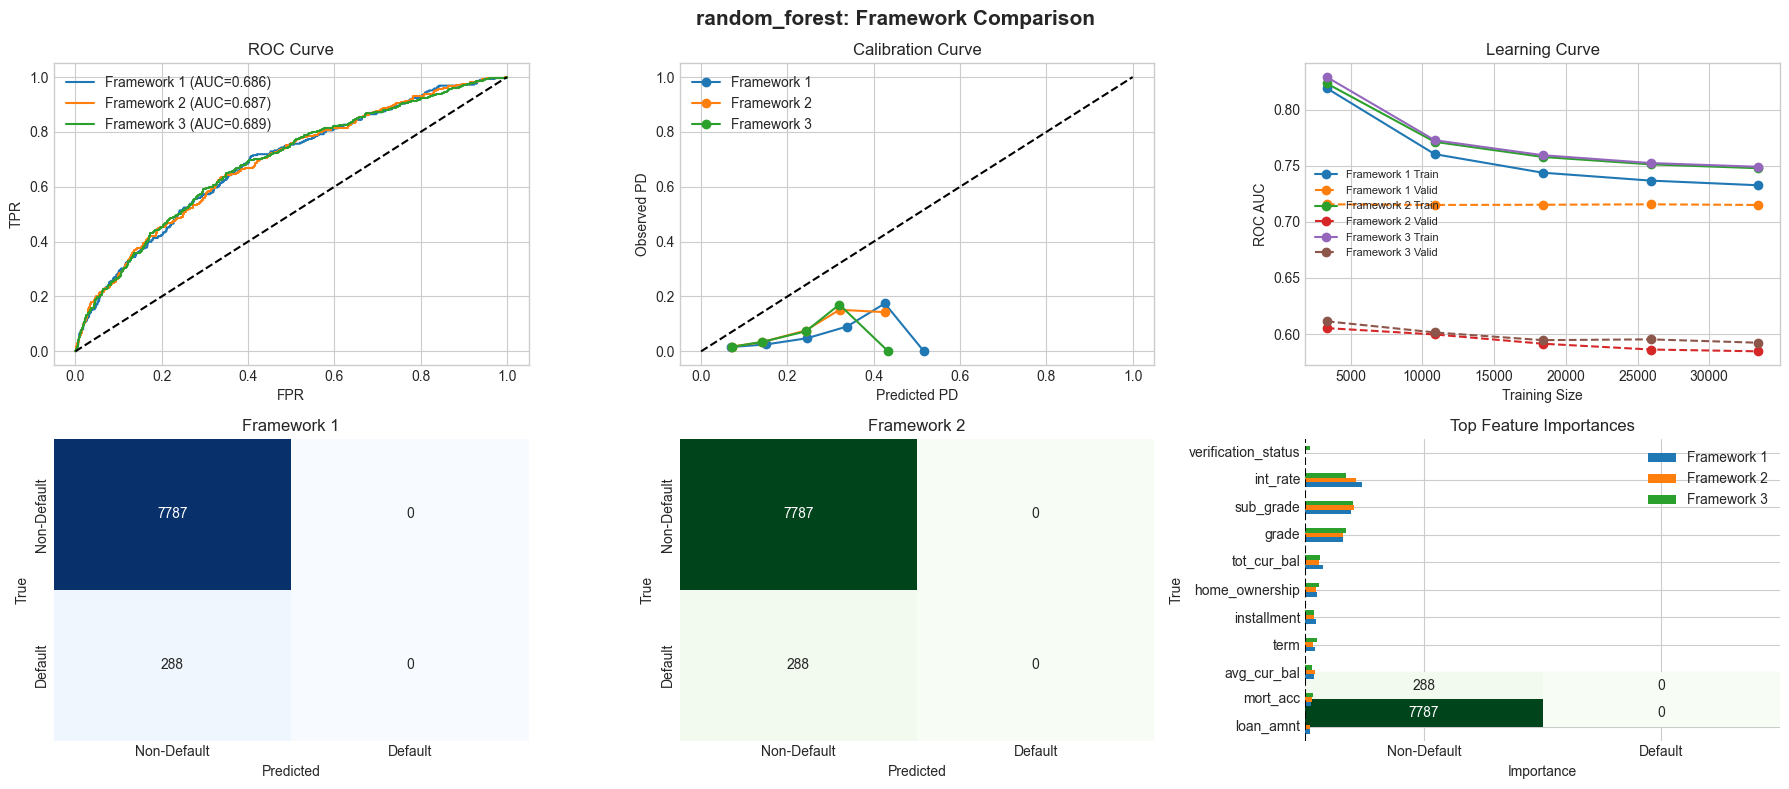

In [120]:
compare_framework_models_eval(frameworks, threshold, name)

### Comparing models

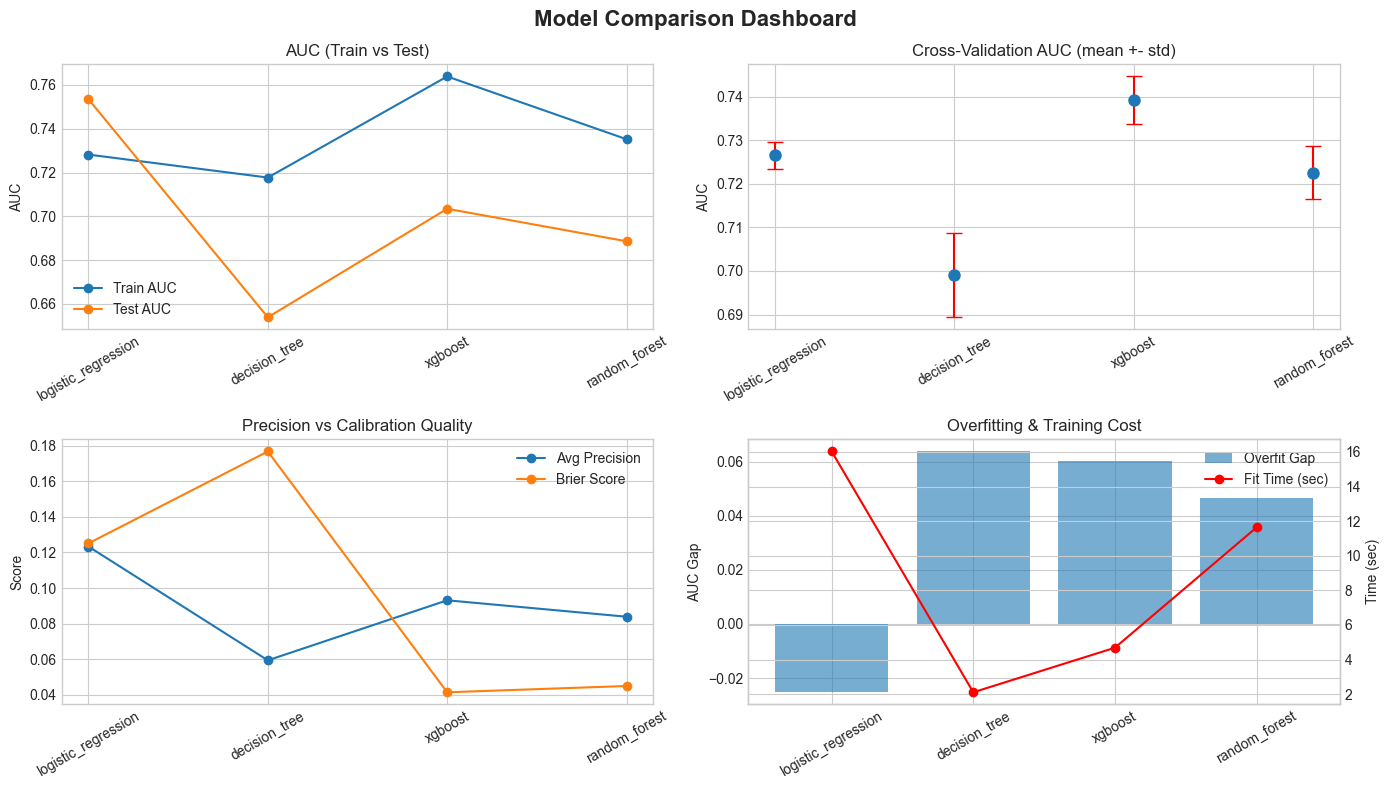

In [121]:
plot_model_comparison(results_step3)

The comparison across frameworks shows a clear pattern in how regime information affects different model families.

For linear models, performance improves steadily as features are added. Logistic Regression shows consistent gains from Framework 1 to Framework 3, with the regime feature providing the largest boost. This suggests that compressing macro conditions into a single structured variable helps linear models capture information they could not easily extract from raw macro inputs.

In contrast, tree-based models do not benefit in a meaningful way. Their performance remains flat or inconsistent across frameworks, and there is no improvement in practical decision outcomes such as confusion matrices. This indicates that these models either already capture similar structure through splits or are limited by the dataset’s low temporal variation.

From a broader perspective, this difference highlights how model structure interacts with feature design: linear models benefit from engineered summaries like regimes, while tree ensembles rely more on learning such patterns internally, which is less effective in a short and relatively homogeneous time series.

Looking at the full comparison, XGBoost in Framework 1 remains the strongest model in raw AUC, but it does not translate into usable threshold-level performance. Logistic Regression in Framework 3 offers the best overall balance between ranking quality, interpretability, and practical default detection.

Importantly, adding regime features does not increase overfitting for linear models, while tree models maintain their higher variance across all frameworks. The regime feature itself is low-cost in terms of complexity, but high-impact for models that can leverage structured, low-dimensional representations of macro conditions.

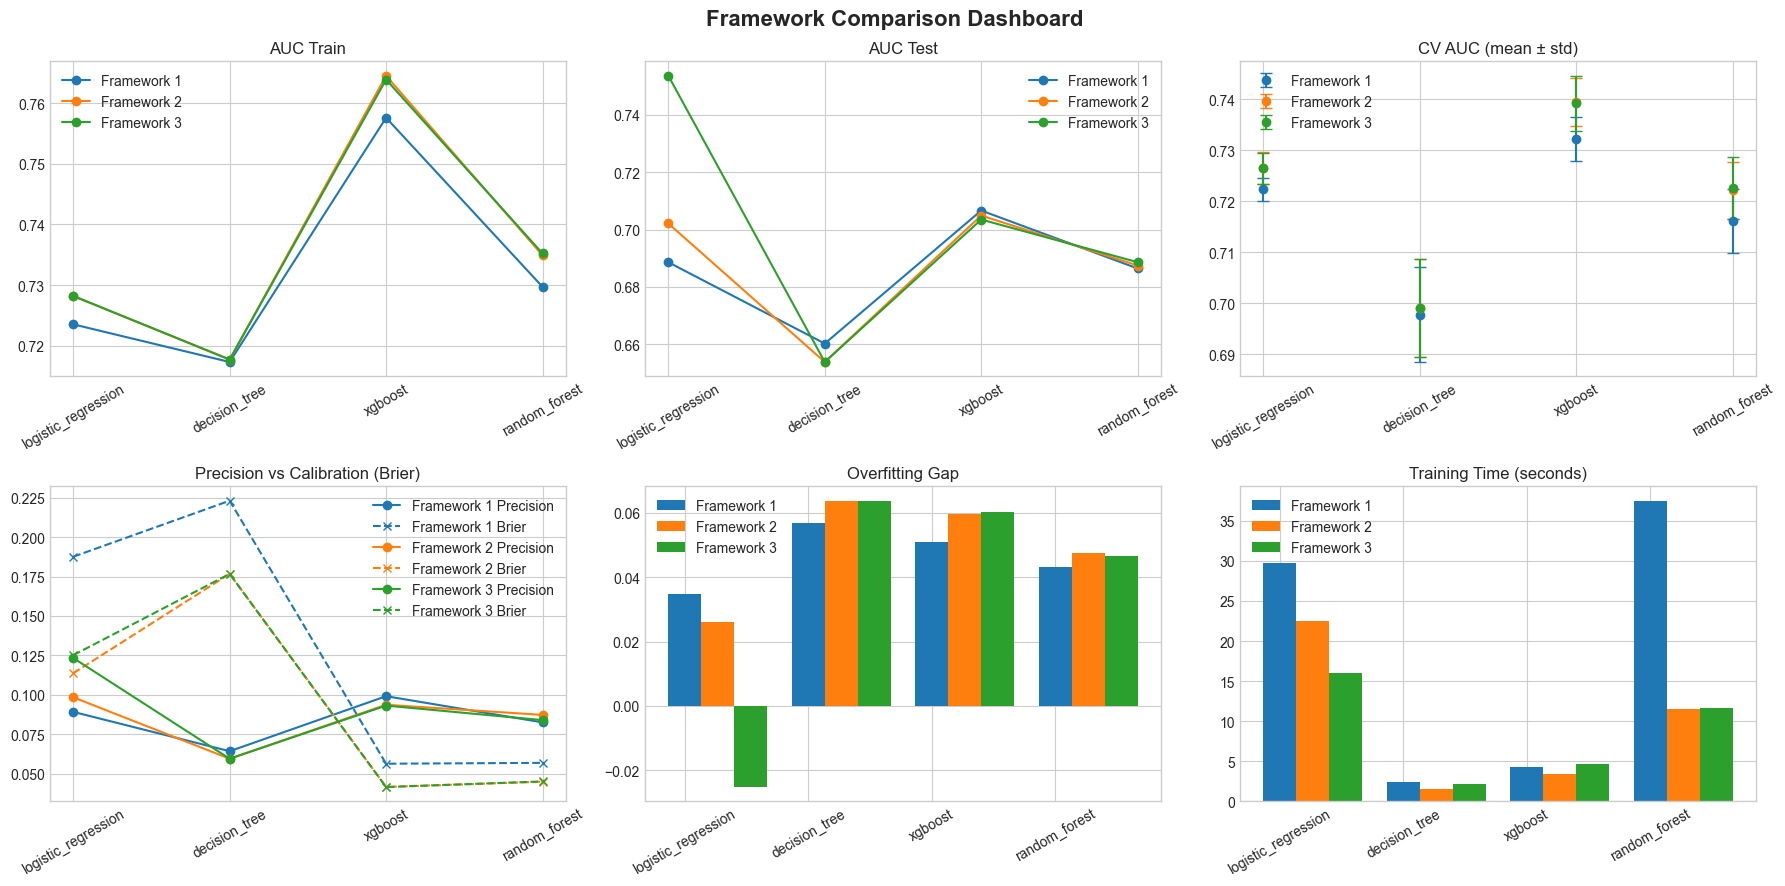

In [122]:
plot_framework_model_comparison(frameworks)

_________________

# **IV. Backtesting**

To evaluate out-of-sample robustness:
- we use a walk-forward backtesting setup with 5 TimeSeriesSplit folds:
- each fold trains only on past data and tests on future data, avoiding look-ahead bias and better reflecting real credit risk conditions where regimes evolve over time

We evaluate 3 metrics: 
- ROC AUC for ranking ability
- Average Precision for rare default detection
- Brier Score for probability calibration

Results are compared across models and frameworks to assess both stability over time and true generalisation performance


In [123]:
backtest_result = {}

for i in range(1, 4):
    framework_name = f'Framework {i}'
    results = {}
    for model_name in frameworks[framework_name].keys():
        model = frameworks[framework_name][model_name]['model']
        framework_df = frameworks_df[framework_name]
        summary_bt = walk_forward_backtest_TS(framework_df=framework_df, model=model)
        results[model_name] = summary_bt
    backtest_result[framework_name] = results

In [124]:
backtest_result[framework_name][model_name]

,fold,auc,avg_precision,brier
0,1,0.716964,0.355915,0.138371
1,2,0.722085,0.359092,0.135468
2,3,0.718187,0.348236,0.133106
3,4,0.712424,0.269950,0.105369
4,5,0.689804,0.086835,0.046370



| Model | AUC | Average Precision | Brier Score |
|------|-----|------------------|-------------|
| Logistic Regression | Regime features improve AUC, especially in later folds (notably Fold 5)   | Slight improvement in later folds with regime features, but not consistent over time | Slight deterioration in calibration when regime features are included, especially in stressed folds |
| Decision Tree | No meaningful differences across frameworks; performance mainly driven by data structure | Stable across frameworks; macro features add no clear gain | Minor improvement in augmented frameworks in the last fold only |
| XGBoost | Frameworks are nearly identical; macro/regime features add no incremental value | Strong drop in final fold across all frameworks, driven by data difficulty rather than model change | Very stable across frameworks with no systematic improvement from features |
| Random Forest | Small early gains from macro features disappear over time; convergence across frameworks | No consistent benefit from added features across folds | Slight calibration improvement in augmented frameworks in the last fold; otherwise identical |


<br>

The most important and consistent pattern across all models is the sharp degradation in Fold 5 performance.

This is not model-specific. It appears across: linear models, tree models, boosting models, ensembles

This strongly indicates a data regime shift rather than a modeling issue.
- A likely explanation is that the final fold represents a more recent cohort with:
    - lower realized default rates due to maturity lag
    - different macro conditions
    - or structural lending changes
- as a result, all models struggle equally in ranking and calibration


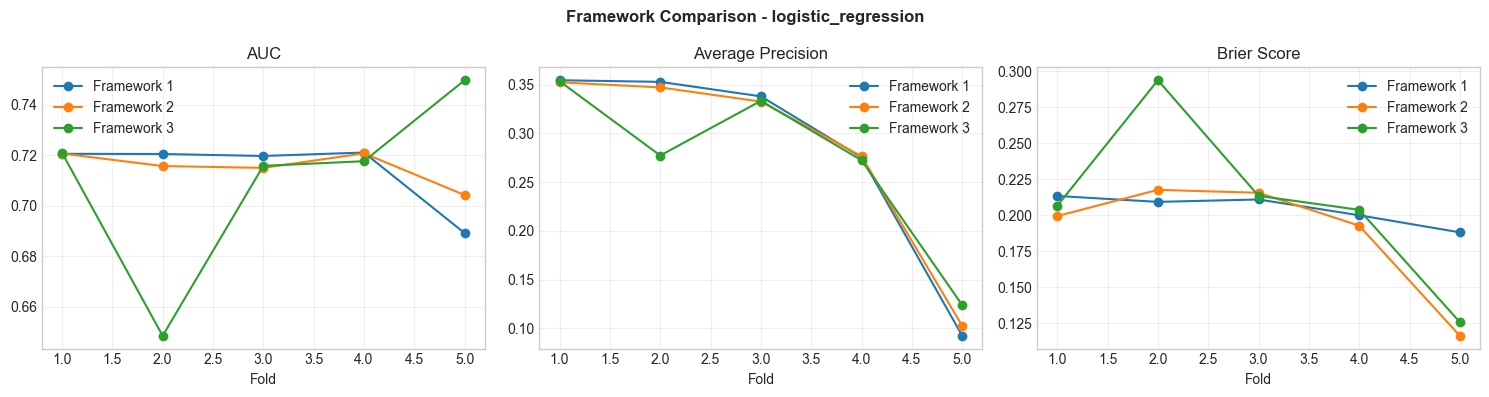

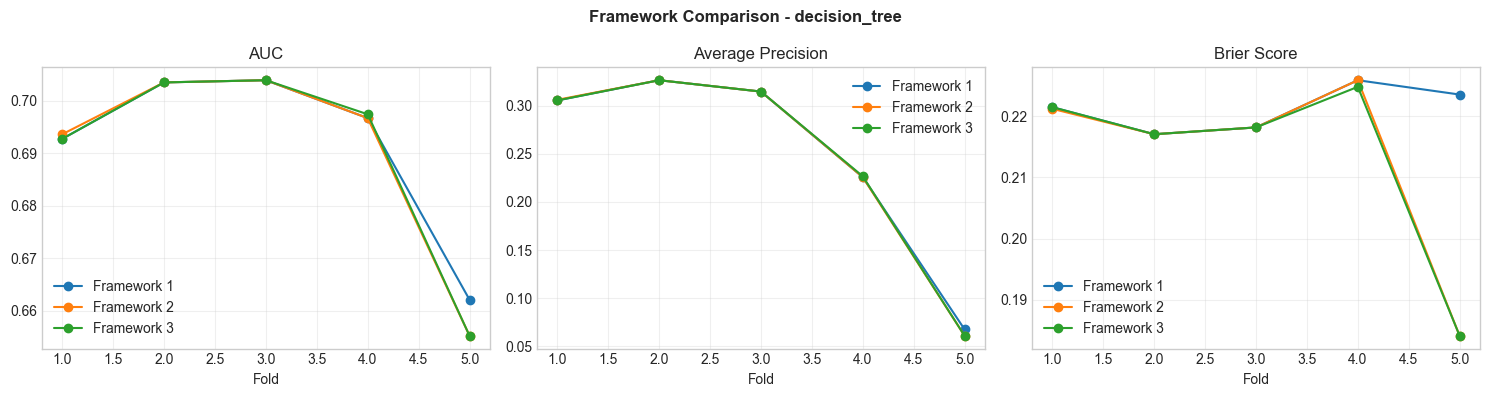

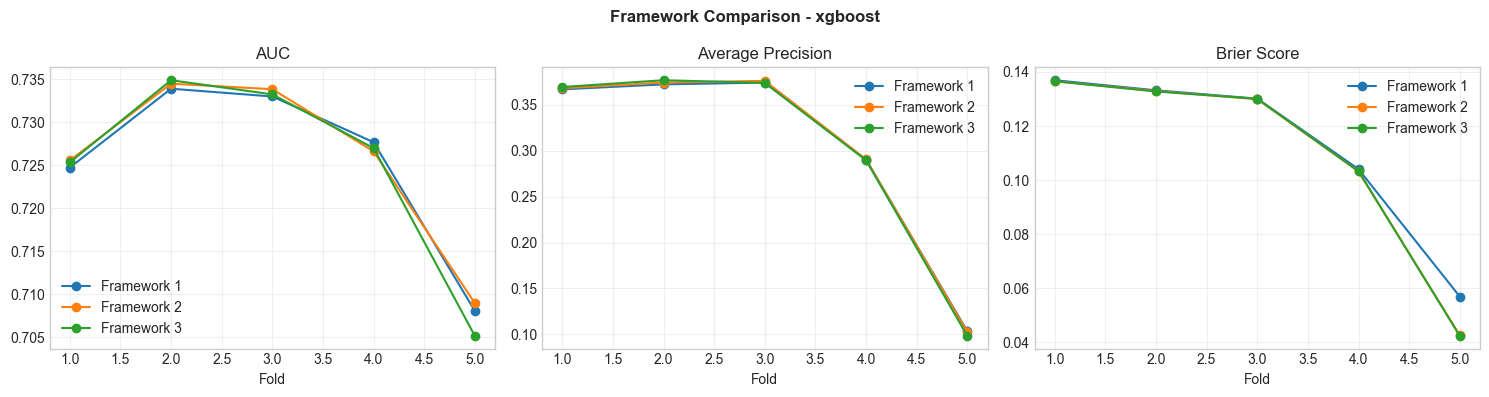

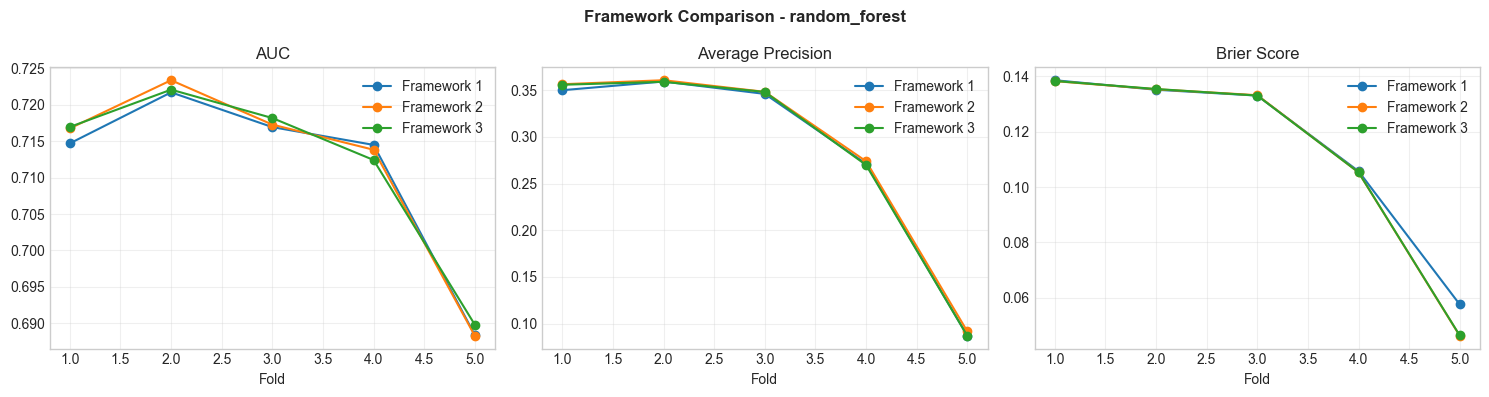

In [125]:
for model_name in frameworks[framework_name].keys():
        plot_model_across_frameworks(backtest_result, model_name)

AUC (ranking power):
- XGBoost and Random Forest are the strongest models across all frameworks and folds
- Logistic Regression is weaker overall but becomes competitive in Framework 3 at Fold 5, where it briefly overtakes other models
- Decision Tree remains consistently the weakest model

<br>

Average Precision (rare event detection):
- XGBoost, Random Forest, Logistic Regression perform similarly in early folds, while Decision Tree is slightly worse
- All models collapse sharply in Fold 5 across all frameworks, dropping toward baseline default rates
- This indicates a strong time-based distribution shift affecting rare-event detection
- Framework choice does not change this pattern

<br>

Brier Score (calibration):
- XGBoost and Random Forest are the best-calibrated models and remain stable across all frameworks and folds
- Logistic Regression is consistently worse calibrated but shows temporary instability (notably in Framework 3, Fold 2) followed by improvement in later folds
- Decision Tree sits in the middle but does not clearly benefit from feature changes

<br>

Cross-framework comparison:
- Frameworks 1 and 2 behave almost identically across all models and metrics, indicating that raw macro features add little value
- Framework 3 only affects Logistic Regression meaningfully, improving late-fold performance but introducing some early instability
- Tree-based models are essentially unaffected by framework changes

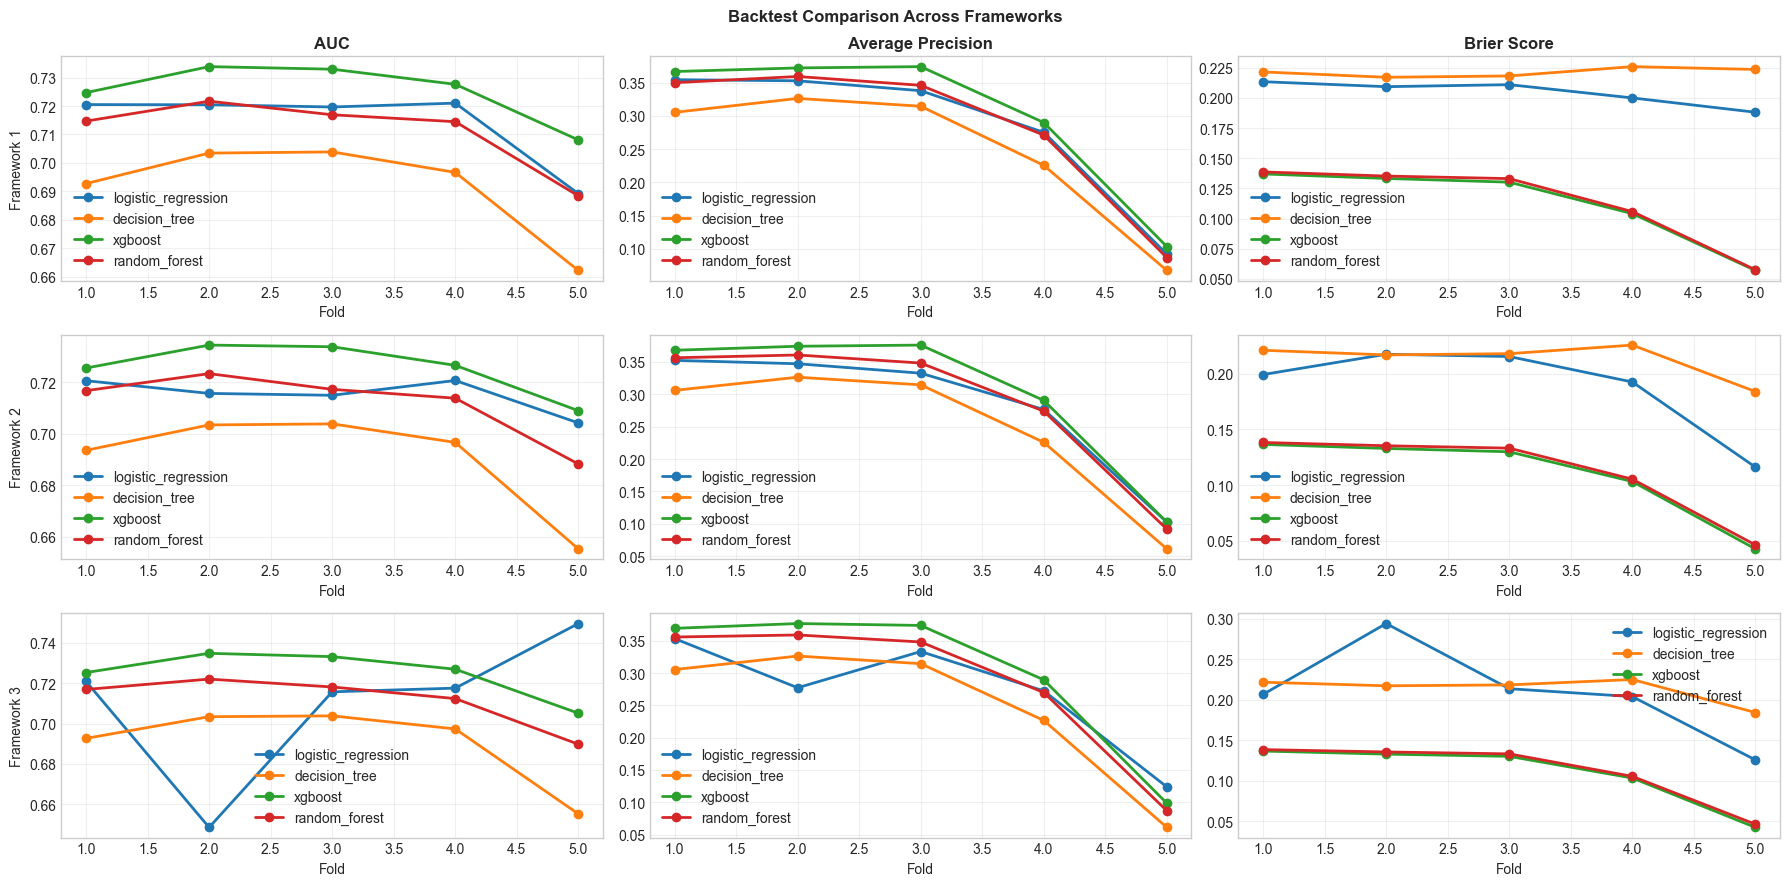

In [126]:
plot_framework_model_comparison_backtest(backtest_result)

___________

# **V. Stress Testing**


To assess portfolio resilience under adverse macroeconomic conditions:
- we define nine stress scenarios covering major historical crises and standard macro regimes 
- each scenario applies a simultaneous shock to the eight macro variables used in Frameworks 2 and 3


In [127]:
scenarios_df = pd.DataFrame(STRESS_SCENARIOS).T
scenarios_df

,fed_funds,treasury_2y,treasury_10y,unemp_rate,cpi,real_gdp,ind_prod,credit_spread
Baseline,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008 Financial Crisis,-4.0,-3.0,-2.5,4.0,-1.5,-4.5,-5.0,6.0
COVID Shock,-2.0,-1.5,-1.0,3.5,-1.0,-6.0,-6.5,5.0
Sovereign Debt Crisis,-1.0,-1.5,-1.8,2.5,0.5,-2.5,-3.0,7.0
Oil Shock Stagflation,3.0,2.0,1.5,3.0,6.0,-2.0,-3.5,3.0
EM Crisis (Risk-Off),-1.0,-2.0,-2.5,2.0,-0.5,-3.0,-3.0,5.5
Mild Recession,-1.0,-0.8,-0.5,1.5,0.3,-1.0,-1.2,1.2
Severe Recession,-2.5,-2.0,-1.5,3.5,-0.5,-3.0,-3.5,3.5
Rate Hike Cycle,2.5,2.8,1.8,0.5,1.2,-0.5,-0.3,0.8
V-Shaped Recovery,0.5,0.3,0.5,-1.5,0.5,2.5,2.0,-1.0


The heatmap summarises the structure of the stress scenarios applied to the macro variables:
- The most severe demand-driven contractions appear in the 2008 Financial Crisis and COVID Shock, where large negative shocks to GDP and industrial production coincide with rising unemployment and sharp credit spread widening
- The Sovereign Debt Crisis is primarily a financial stress event, dominated by a large spike in credit spreads with relatively milder real-economy deterioration
- In contrast, the Oil Shock Stagflation scenario combines high inflation with negative growth, creating a difficult environment for rate-sensitive borrowers
- Rate Hike Cycle and V-Shaped Recovery represent milder regimes and serve as reference points for normal or recovering conditions

Overall, the scenarios span a broad range of macro conditions, from severe crises to benign expansions, providing a consistent framework to evaluate model behaviour under stress

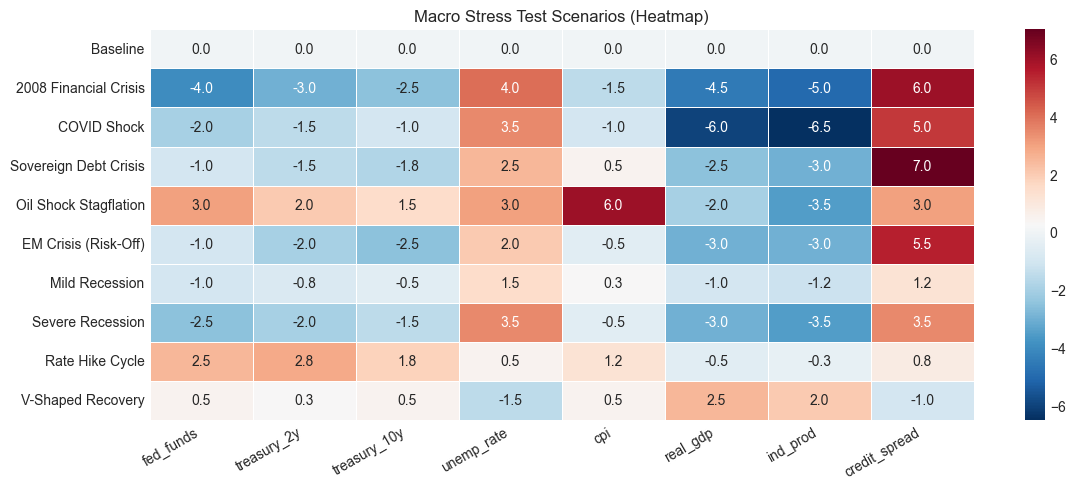

In [128]:
plot_stress_test_scenarios(scenarios_df)

In [129]:
stresstest_results = {}

for i, X_test_i in zip(range(1, 4), (X_test, X_test2, X_test3)):
    framework_name = f'Framework {i}'
    results = {}
    for model_name in frameworks[framework_name].keys():
        model = frameworks[framework_name][model_name]['model']
        stress_result = stress_test_macro_scenarios(model=model, X_test=X_test_i)
        results[model_name] = stress_result
    stresstest_results[framework_name] = results

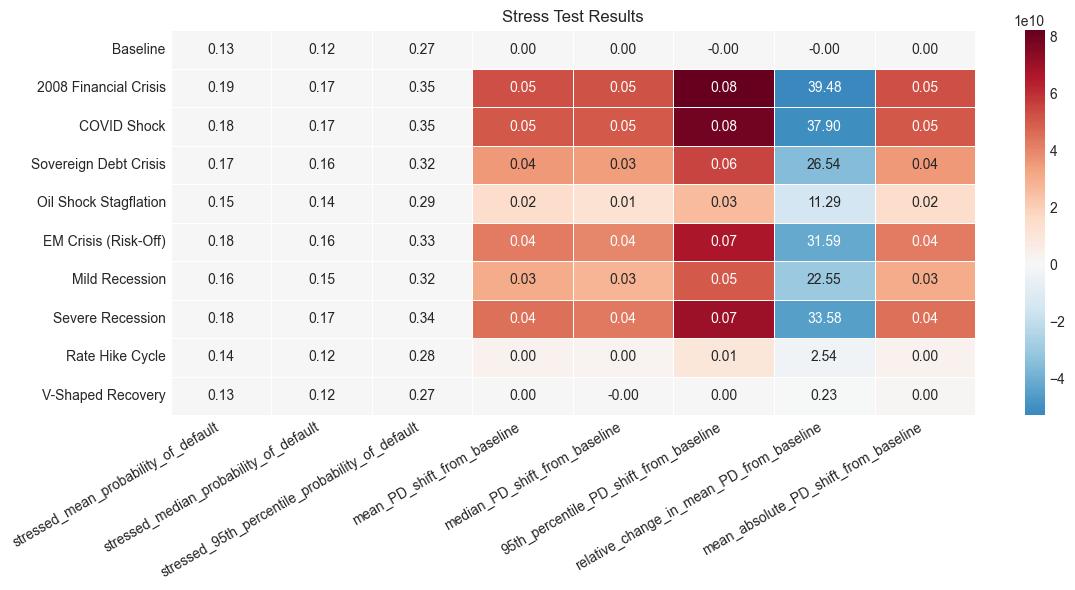

In [130]:
plot_stress_heatmap(stress_result)

In [131]:
macro_cols = scenarios_df.columns

Our models exhibit clearly different sensitivity patterns.

| Model |  |
|------|---------|
| Logistic Regression | Smooth, near-linear response across variables, driven mainly by `fed_funds`, with consistent and economically interpretable effects across macro factors |
| Decision Tree | Highly non-linear, threshold-driven behavior where most variables are inactive until split points are reached, resulting in weak overall macro sensitivity |
| XGBoost | Sparse and asymmetric response dominated by `fed_funds`, with stronger reactions to negative shocks than positive ones and limited contribution from other variables |
| Random Forest | Highly averaged and muted sensitivity across all variables, with only slight influence from short-term rates, leading to stability but low responsiveness under stress |

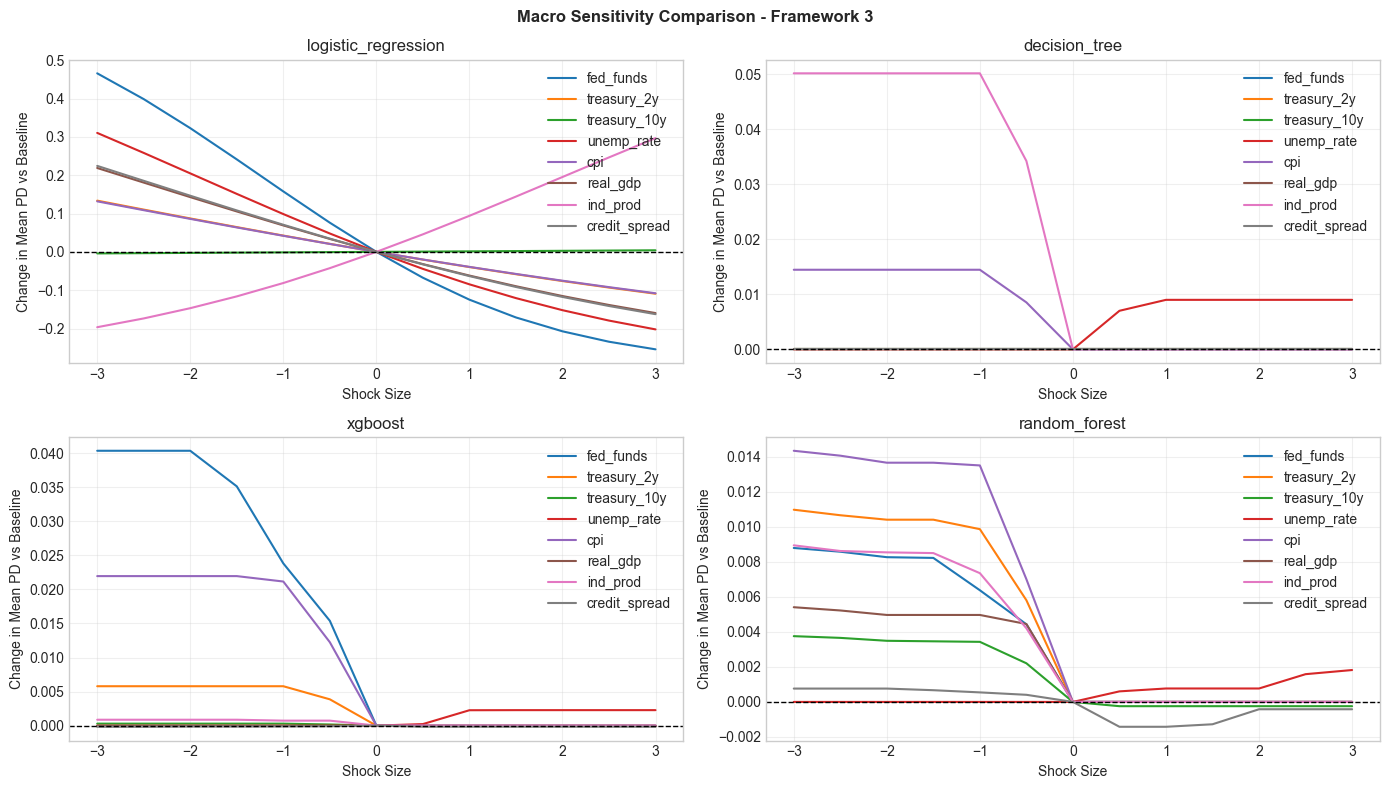

In [132]:
framework_name = "Framework 3"
model_items = list(frameworks[framework_name].keys())
n_models = len(model_items)
n_cols = int(np.ceil(n_models / 2))
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 4*n_rows))
axes = axes.flatten()
for i, model_name in enumerate(model_items):
    model = frameworks[framework_name][model_name]["model"]
    sensitivity_df = stress_sensitivity_analysis(model, X_test3, macro_cols)
    plot_sensitivity_curves(sensitivity_df, ax=axes[i], title=f"{model_name}")
# hide empty axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle(f"Macro Sensitivity Comparison - {framework_name}", fontweight="bold")
plt.tight_layout()
plt.show()

___________

## Conclusion


| Finding | Insight |
|--------|----------|
| Macro variables have minimal standalone value | Going from Framework 1 to Framework 2 shows negligible AUC change across models; macro features behave like weak time proxies with low variation and high collinearity |
| Regime signal drives gains in linear model | Framework 3 improves Logistic Regression significantly; linear models exploit compressed regime structure while tree models show no measurable gain |
| Tree models are feature-engineering insensitive | XGBoost, Random Forest, and Decision Tree remain stable across frameworks since they already capture nonlinear interactions internally, making added macro or regime inputs largely redundant |
| Temporal instability dominates evaluation | All models show a sharp performance drop in the final fold driven by dataset shift or structural break, not model or feature choice |
| Representation quality determines macro/regime usefulness | Raw macro variables add little signal, while regime encoding provides a compact informative summary that benefits linear models most |

<br>

### Practical Conclusion

The most robust and deployable specification is:

> **Logistic Regression with Framework 3 features**

<br>

It provides:
* The best balance of predictive performance and stability
* Meaningful macro sensitivity
* Improved interpretability and regulatory alignment
* Better calibrated probabilities in economically relevant PD ranges

Other models either:
* Do not improve with added structure (tree-based models)
* or, lack macro sensitivity without regime compression (Framework 1/2 logistic regression)